# 1. Import Libraries

In [1]:
import os
import joblib

# Import library untuk manipulasi data
import pandas as pd

# Import library untuk operasi numerik
import numpy as np

# Import library visualisasi
import matplotlib.pyplot as plt

# Import library visualisasi yang lebih menarik
import seaborn as sns

# Import model
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
# TensorFlow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    LSTM,
    GRU,
    Bidirectional
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping
)
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import RandomizedSearchCV

# Import library evaluasi
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Mengatur format angka agar lebih mudah dibaca
pd.options.display.float_format = '{:,.2f}'.format

# 2. Load Dataset

In [2]:
# Membaca dataset BBCA
bbca = pd.read_csv("dataset/BBCA.csv")

# Membaca dataset BBRI
bbri = pd.read_csv("dataset/BBRI.csv")

# Membaca dataset BMRI
bmri = pd.read_csv("dataset/BMRI.csv")

# Membaca dataset BBNI
bbni = pd.read_csv("dataset/BBNI.csv")

# Membaca dataset ICBP
icbp = pd.read_csv("dataset/ICBP.csv")

# Membaca dataset MYOR
myor = pd.read_csv("dataset/MYOR.csv")

# Membaca dataset TLKM
tlkm = pd.read_csv("dataset/TLKM.csv")

## 2.1 Jumlah Baris dan Kolom

In [3]:
# Menampilkan ukuran dataset BBCA
print("Shape BBCA :", bbca.shape)

# Menampilkan ukuran dataset BBRI
print("Shape BBRI :", bbri.shape)

# Menampilkan ukuran dataset BMRI
print("Shape BMRI :", bmri.shape)

# Menampilkan ukuran dataset BBNI
print("Shape BBNI :", bbni.shape)

# Menampilkan ukuran dataset ICBP
print("Shape ICBP :", icbp.shape)

# Menampilkan ukuran dataset MYOR
print("Shape MYOR :", myor.shape)

# Menampilkan ukuran dataset TLKM
print("Shape TLKM :", tlkm.shape)

Shape BBCA : (1205, 6)
Shape BBRI : (1205, 6)
Shape BMRI : (1205, 6)
Shape BBNI : (1205, 6)
Shape ICBP : (1205, 6)
Shape MYOR : (1205, 6)
Shape TLKM : (1205, 6)


## 2.2 5 Data Pertama

In [4]:
# Menampilkan 5 data pertama BBCA
bbca.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,BBCA.JK,BBCA.JK,BBCA.JK,BBCA.JK,BBCA.JK
1,Date,NaN,NaN,NaN,NaN,NaN
2,2021-05-31,5462.3564453125,5475.2090487132355,5419.514433976716,5449.5038419117645,101442000
3,2021-06-02,5539.47216796875,5582.314180095345,5500.914357054815,5569.461576457367,141732500
4,2021-06-03,5655.146484375,5655.146484375,5509.483620383523,5565.178244850852,133810500


In [5]:
# Menampilkan 5 data pertama BBRI
bbri.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,BBRI.JK,BBRI.JK,BBRI.JK,BBRI.JK,BBRI.JK
1,Date,NaN,NaN,NaN,NaN,NaN
2,2021-05-31,2754.87255859375,2767.8061559333632,2657.8699706913694,2670.8037417039204,326538660
3,2021-06-02,2754.87255859375,2832.4746636502423,2735.4720757478617,2813.0740071314162,312257333
4,2021-06-03,2819.540771484375,2819.540771484375,2729.005072978513,2761.339325447577,173444725


In [6]:
# Menampilkan 5 data pertama BMRI
bmri.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,BMRI.JK,BMRI.JK,BMRI.JK,BMRI.JK,BMRI.JK
1,Date,NaN,NaN,NaN,NaN,NaN
2,2021-05-31,2120.38232421875,2155.722029622396,2058.53783976237,2076.207692464193,96660000
3,2021-06-02,2155.721923828125,2191.0616274974386,2146.8869979107967,2173.391775662782,157335600
4,2021-06-03,2208.731689453125,2217.5666162109374,2164.5570556640623,2182.2269091796875,86426400


In [7]:
# Menampilkan 5 data pertama BBNI
bbni.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,BBNI.JK,BBNI.JK,BBNI.JK,BBNI.JK,BBNI.JK
1,Date,NaN,NaN,NaN,NaN,NaN
2,2021-05-31,2048.967041015625,2086.910875108507,1973.079372829861,1982.5653313530815,69536200
3,2021-06-02,2105.882568359375,2115.368525874507,2058.4527807837135,2086.91065332911,76636200
4,2021-06-03,2181.7705078125,2181.7705078125,2077.4249617866844,2115.368796705163,54852600


In [8]:
# Menampilkan 5 data pertama ICBP
icbp.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,ICBP.JK,ICBP.JK,ICBP.JK,ICBP.JK,ICBP.JK
1,Date,NaN,NaN,NaN,NaN,NaN
2,2021-05-31,7346.9072265625,7369.306333960557,7234.911689572218,7302.109011766387,4574100
3,2021-06-02,7369.306640625,7503.701290606003,7346.907532294833,7391.705748955167,5611200
4,2021-06-03,7794.8896484375,7794.889648437499,7391.705701104525,7391.705701104525,10251900


In [9]:
# Menampilkan 5 data pertama MYOR
myor.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,MYOR.JK,MYOR.JK,MYOR.JK,MYOR.JK,MYOR.JK
1,Date,NaN,NaN,NaN,NaN,NaN
2,2021-05-31,2302.8408203125,2357.2386349655512,2302.8408203125,2357.2386349655512,2233100
3,2021-06-02,2330.03955078125,2339.105852535263,2302.840645519212,2339.105852535263,771500
4,2021-06-03,2311.9072265625,2348.172437959559,2302.840923713235,2330.0398322610295,1185300


In [10]:
# Menampilkan 5 data pertama TLKM
tlkm.head()

,Price,Close,High,Low,Open,Volume
0,Ticker,TLKM.JK,TLKM.JK,TLKM.JK,TLKM.JK,TLKM.JK
1,Date,NaN,NaN,NaN,NaN,NaN
2,2021-05-31,2648.543212890625,2663.9417199423146,2540.7536635287975,2540.7536635287975,155768200
3,2021-06-02,2656.2421875,2694.7384510869565,2633.1444293478257,2687.039198369565,108933400
4,2021-06-03,2687.039306640625,2687.039306640625,2633.14453544726,2633.14453544726,77627900


## 2.3 Informasi Dataset

In [11]:
# Menampilkan informasi dataset BBCA
bbca.info()

<class 'pandas.DataFrame'>
RangeIndex: 1205 entries, 0 to 1204
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Price   1205 non-null   str  
 1   Close   1204 non-null   str  
 2   High    1204 non-null   str  
 3   Low     1204 non-null   str  
 4   Open    1204 non-null   str  
 5   Volume  1204 non-null   str  
dtypes: str(6)
memory usage: 152.7 KB


In [12]:
# Menampilkan informasi dataset BBRI
bbri.info()

<class 'pandas.DataFrame'>
RangeIndex: 1205 entries, 0 to 1204
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Price   1205 non-null   str  
 1   Close   1204 non-null   str  
 2   High    1204 non-null   str  
 3   Low     1204 non-null   str  
 4   Open    1204 non-null   str  
 5   Volume  1204 non-null   str  
dtypes: str(6)
memory usage: 157.4 KB


In [13]:
# Menampilkan informasi dataset BMRI
bmri.info()

<class 'pandas.DataFrame'>
RangeIndex: 1205 entries, 0 to 1204
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Price   1205 non-null   str  
 1   Close   1204 non-null   str  
 2   High    1204 non-null   str  
 3   Low     1204 non-null   str  
 4   Open    1204 non-null   str  
 5   Volume  1204 non-null   str  
dtypes: str(6)
memory usage: 156.7 KB


In [14]:
# Menampilkan informasi dataset BBNI
bbni.info()

<class 'pandas.DataFrame'>
RangeIndex: 1205 entries, 0 to 1204
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Price   1205 non-null   str  
 1   Close   1204 non-null   str  
 2   High    1204 non-null   str  
 3   Low     1204 non-null   str  
 4   Open    1204 non-null   str  
 5   Volume  1204 non-null   str  
dtypes: str(6)
memory usage: 155.8 KB


In [15]:
# Menampilkan informasi dataset ICBP
icbp.info()

<class 'pandas.DataFrame'>
RangeIndex: 1205 entries, 0 to 1204
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Price   1205 non-null   str  
 1   Close   1204 non-null   str  
 2   High    1204 non-null   str  
 3   Low     1204 non-null   str  
 4   Open    1204 non-null   str  
 5   Volume  1204 non-null   str  
dtypes: str(6)
memory usage: 145.7 KB


In [16]:
# Menampilkan informasi dataset MYOR
myor.info()

<class 'pandas.DataFrame'>
RangeIndex: 1205 entries, 0 to 1204
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Price   1205 non-null   str  
 1   Close   1204 non-null   str  
 2   High    1204 non-null   str  
 3   Low     1204 non-null   str  
 4   Open    1204 non-null   str  
 5   Volume  1204 non-null   str  
dtypes: str(6)
memory usage: 148.0 KB


In [17]:
# Menampilkan informasi dataset TLKM
tlkm.info()

<class 'pandas.DataFrame'>
RangeIndex: 1205 entries, 0 to 1204
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Price   1205 non-null   str  
 1   Close   1204 non-null   str  
 2   High    1204 non-null   str  
 3   Low     1204 non-null   str  
 4   Open    1204 non-null   str  
 5   Volume  1204 non-null   str  
dtypes: str(6)
memory usage: 148.7 KB


# 3. Data Cleaning

In [18]:
# Membuat fungsi untuk membersihkan dataset saham
def clean_stock_data(df, ticker_name):

    # Menghapus 2 baris metadata pertama
    df = df.iloc[2:]

    # Reset index agar kembali dimulai dari 0
    df = df.reset_index(drop=True)

    # Mengubah nama kolom Price menjadi Date
    df = df.rename(columns={"Price": "Date"})

    # Mengubah kolom Date menjadi datetime
    df["Date"] = pd.to_datetime(df["Date"])

    # Mengubah kolom numerik menjadi tipe data numerik
    df["Close"] = pd.to_numeric(df["Close"])
    df["High"] = pd.to_numeric(df["High"])
    df["Low"] = pd.to_numeric(df["Low"])
    df["Open"] = pd.to_numeric(df["Open"])
    df["Volume"] = pd.to_numeric(df["Volume"])

    # Mengisi missing value menggunakan nilai sebelumnya jika ada
    df = df.ffill()

    # Menghapus data duplikat jika ada
    df = df.drop_duplicates()

    # Mengurutkan data berdasarkan tanggal
    df = df.sort_values("Date")

    # Reset index kembali
    df = df.reset_index(drop=True)

    # Menambahkan kolom ticker
    df["Ticker"] = ticker_name

    # Mengembalikan dataframe yang sudah bersih
    return df

## 3.1 Membersihkan Seluruh Dataset

In [19]:
# Membersihkan dataset 
bbca_clean = clean_stock_data(bbca, "BBCA")
bbri_clean = clean_stock_data(bbri, "BBRI")
bmri_clean = clean_stock_data(bmri, "BMRI")
bbni_clean = clean_stock_data(bbni, "BBNI")
icbp_clean = clean_stock_data(icbp, "ICBP")
myor_clean = clean_stock_data(myor, "MYOR")
tlkm_clean = clean_stock_data(tlkm, "TLKM")

## 3.2 Validasi Hasil Cleaning

In [20]:
# Menampilkan ukuran masing-masing dataset

print("BBCA :", bbca_clean.shape)
print("BBRI :", bbri_clean.shape)
print("BMRI :", bmri_clean.shape)
print("BBNI :", bbni_clean.shape)
print("ICBP :", icbp_clean.shape)
print("MYOR :", myor_clean.shape)
print("TLKM :", tlkm_clean.shape)

BBCA : (1203, 7)
BBRI : (1203, 7)
BMRI : (1203, 7)
BBNI : (1203, 7)
ICBP : (1203, 7)
MYOR : (1203, 7)
TLKM : (1203, 7)


## 3.3 Cek Tipe Data

In [21]:
# cek tipe data setelah dibersihkan

print("BBCA")
print(bbca_clean.info())
print("="*50)

print("BBRI")
print(bbri_clean.info())
print("="*50)

print("BMRI")
print(bmri_clean.info())
print("="*50)

print("BBNI")
print(bbni_clean.info())
print("="*50)

print("ICBP")
print(icbp_clean.info())
print("="*50)

print("MYOR")
print(myor_clean.info())
print("="*50)

print("TLKM")
print(tlkm_clean.info())

BBCA
<class 'pandas.DataFrame'>
RangeIndex: 1203 entries, 0 to 1202
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1203 non-null   datetime64[us]
 1   Close   1203 non-null   float64       
 2   High    1203 non-null   float64       
 3   Low     1203 non-null   float64       
 4   Open    1203 non-null   float64       
 5   Volume  1203 non-null   int64         
 6   Ticker  1203 non-null   str           
dtypes: datetime64[us](1), float64(4), int64(1), str(1)
memory usage: 70.8 KB
None
BBRI
<class 'pandas.DataFrame'>
RangeIndex: 1203 entries, 0 to 1202
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1203 non-null   datetime64[us]
 1   Close   1203 non-null   float64       
 2   High    1203 non-null   float64       
 3   Low     1203 non-null   float64       
 4   Open    1203 non-null   float64       
 5   Volume  

## 3.4 Cek Missing Value

In [22]:
# Missing value BBCA
print("BBCA")
print(bbca_clean.isnull().sum())

print("="*50)

# Missing value BBRI
print("BBRI")
print(bbri_clean.isnull().sum())

print("="*50)

# Missing value BMRI
print("BMRI")
print(bmri_clean.isnull().sum())

print("="*50)

# Missing value BBNI
print("BBNI")
print(bbni_clean.isnull().sum())

print("="*50)

# Missing value ICBP
print("ICBP")
print(icbp_clean.isnull().sum())

print("="*50)

# Missing value MYOR
print("MYOR")
print(myor_clean.isnull().sum())

print("="*50)

# Missing value TLKM
print("TLKM")
print(tlkm_clean.isnull().sum())

BBCA
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
Ticker    0
dtype: int64
BBRI
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
Ticker    0
dtype: int64
BMRI
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
Ticker    0
dtype: int64
BBNI
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
Ticker    0
dtype: int64
ICBP
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
Ticker    0
dtype: int64
MYOR
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
Ticker    0
dtype: int64
TLKM
Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
Ticker    0
dtype: int64


## 3.5 Cek Duplicate Data

In [23]:
# Mengecek duplicate data pada setiap dataset

print("BBCA :", bbca_clean.duplicated().sum())
print("BBRI :", bbri_clean.duplicated().sum())
print("BMRI :", bmri_clean.duplicated().sum())
print("BBNI :", bbni_clean.duplicated().sum())
print("ICBP :", icbp_clean.duplicated().sum())
print("MYOR :", myor_clean.duplicated().sum())
print("TLKM :", tlkm_clean.duplicated().sum())

BBCA : 0
BBRI : 0
BMRI : 0
BBNI : 0
ICBP : 0
MYOR : 0
TLKM : 0


## 3.6 Menampilkan Data Setelah Cleaning

In [24]:
# Menampilkan 5 data pertama BBCA
bbca_clean.head()

,Date,Close,High,Low,Open,Volume,Ticker
0,2021-05-31,"5,462.36","5,475.21","5,419.51","5,449.50",101442000,BBCA
1,2021-06-02,"5,539.47","5,582.31","5,500.91","5,569.46",141732500,BBCA
2,2021-06-03,"5,655.15","5,655.15","5,509.48","5,565.18",133810500,BBCA
3,2021-06-04,"5,638.01","5,672.28","5,569.46","5,672.28",62108500,BBCA
4,2021-06-07,"5,595.17","5,629.44","5,509.48","5,620.87",62576000,BBCA


## 3.7 Menyimpan Dataset Bersih

In [25]:
bbca_clean.to_csv("dataset_clean/bbca_clean.csv", index=False)
bbri_clean.to_csv("dataset_clean/bbri_clean.csv", index=False)
bmri_clean.to_csv("dataset_clean/bmri_clean.csv", index=False)
bbni_clean.to_csv("dataset_clean/bbni_clean.csv", index=False)
icbp_clean.to_csv("dataset_clean/icbp_clean.csv", index=False)
myor_clean.to_csv("dataset_clean/myor_clean.csv", index=False)
tlkm_clean.to_csv("dataset_clean/tlkm_clean.csv", index=False)

# 4. Exploratory Data Analysis (EDA)

## 4.1 Statistik Deskriptif

In [26]:
# Menampilkan statistik deskriptif BBCA
bbca_clean.describe()

,Date,Close,High,Low,Open,Volume
count,1203,"1,203.00","1,203.00","1,203.00","1,203.00","1,203.00"
mean,2023-11-20 07:31:16.309227,"7,646.34","7,716.56","7,580.82","7,646.31","100,403,092.85"
min,2021-05-31 00:00:00,"5,106.77","5,149.61","5,059.64","5,141.04",0.00
25%,2022-08-22 12:00:00,"6,757.45","6,832.56","6,668.90","6,748.77","59,351,100.00"
50%,2023-11-13 00:00:00,"7,799.06","7,865.57","7,725.09","7,799.06","80,566,400.00"
75%,2025-02-18 12:00:00,"8,377.03","8,456.56","8,291.04","8,377.51","112,763,650.00"
max,2026-05-29 00:00:00,"10,060.58","10,060.58","9,899.80","10,014.64","1,432,993,400.00"
std,NaN,"1,124.37","1,130.19","1,119.30","1,126.85","88,407,409.28"


In [27]:
# Statistik deskriptif BBRI
bbri_clean.describe()

,Date,Close,High,Low,Open,Volume
count,1203,"1,203.00","1,203.00","1,203.00","1,203.00","1,203.00"
mean,2023-11-20 07:31:16.309227,"3,582.00","3,622.53","3,546.30","3,584.65","193,737,930.79"
min,2021-05-31 00:00:00,"2,399.20","2,438.00","2,392.73","2,418.60",0.00
25%,2022-08-22 12:00:00,"3,227.75","3,273.13","3,194.91","3,231.73","111,182,700.00"
50%,2023-11-13 00:00:00,"3,512.19","3,557.45","3,474.72","3,512.93","163,555,000.00"
75%,2025-02-18 12:00:00,"3,956.93","4,008.35","3,920.71","3,953.98","239,600,400.00"
max,2026-05-29 00:00:00,"5,216.77","5,237.48","5,154.67","5,216.77","1,073,661,600.00"
std,NaN,552.22,555.61,548.09,550.83,"119,563,838.92"


In [28]:
# Statistik deskriptif BMRI
bmri_clean.describe()

,Date,Close,High,Low,Open,Volume
count,1203,"1,203.00","1,203.00","1,203.00","1,203.00","1,203.00"
mean,2023-11-20 07:31:16.309227,"4,012.58","4,061.81","3,965.47","4,015.33","121,235,395.68"
min,2021-05-31 00:00:00,"2,005.53","2,040.87","1,987.86","2,014.36",0.00
25%,2022-08-22 12:00:00,"3,179.48","3,211.88","3,133.20","3,184.11","68,738,100.00"
50%,2023-11-13 00:00:00,"4,142.81","4,202.75","4,086.01","4,150.82","100,578,900.00"
75%,2025-02-18 12:00:00,"4,661.81","4,708.19","4,592.46","4,659.54","146,768,100.00"
max,2026-05-29 00:00:00,"6,094.77","6,176.58","6,053.87","6,094.77","907,054,600.00"
std,NaN,"1,023.73","1,036.87","1,011.76","1,024.88","85,489,072.14"


In [29]:
# Statistik deskriptif BBNI
bbni_clean.describe()

,Date,Close,High,Low,Open,Volume
count,1203,"1,203.00","1,203.00","1,203.00","1,203.00","1,203.00"
mean,2023-11-20 07:31:16.309227,"3,621.05","3,665.80","3,577.76","3,624.81","60,777,705.82"
min,2021-05-31 00:00:00,"1,737.83","1,760.59","1,730.24","1,737.83",0.00
25%,2022-08-22 12:00:00,"3,381.35","3,415.16","3,318.55","3,362.02","36,636,100.00"
50%,2023-11-13 00:00:00,"3,718.44","3,767.79","3,681.63","3,727.65","51,193,400.00"
75%,2025-02-18 12:00:00,"4,058.99","4,105.02","4,011.71","4,060.14","73,263,950.00"
max,2026-05-29 00:00:00,"5,026.20","5,047.32","4,983.97","5,026.20","309,557,000.00"
std,NaN,697.93,705.66,692.32,700.82,"36,637,059.80"


In [30]:
# Statistik deskriptif ICBP
icbp_clean.describe()

,Date,Close,High,Low,Open,Volume
count,1203,"1,203.00","1,203.00","1,203.00","1,203.00","1,203.00"
mean,2023-11-20 07:31:16.309227,"9,340.10","9,445.20","9,227.43","9,347.73","6,519,806.07"
min,2021-05-31 00:00:00,"6,525.93","6,640.82","6,479.97","6,548.91",0.00
25%,2022-08-22 12:00:00,"8,088.48","8,157.41","8,012.84","8,100.00","3,390,800.00"
50%,2023-11-13 00:00:00,"9,550.00","9,630.91","9,425.00","9,550.00","4,943,400.00"
75%,2025-02-18 12:00:00,"10,545.88","10,673.11","10,399.41","10,549.27","7,777,500.00"
max,2026-05-29 00:00:00,"12,498.82","12,572.06","12,254.71","12,498.82","176,275,900.00"
std,NaN,"1,425.86","1,441.09","1,403.01","1,427.04","6,891,558.17"


In [31]:
# Statistik deskriptif MYOR
myor_clean.describe()

,Date,Close,High,Low,Open,Volume
count,1203,"1,203.00","1,203.00","1,203.00","1,203.00","1,203.00"
mean,2023-11-20 07:31:16.309227,"2,185.45","2,220.31","2,152.17","2,189.04","7,406,478.64"
min,2021-05-31 00:00:00,"1,397.06","1,429.55","1,378.49","1,401.70",0.00
25%,2022-08-22 12:00:00,"2,030.00","2,060.00","2,004.77","2,033.29","3,340,250.00"
50%,2023-11-13 00:00:00,"2,218.53","2,251.87","2,186.19","2,220.00","5,855,300.00"
75%,2025-02-18 12:00:00,"2,405.14","2,443.16","2,367.11","2,408.26","9,693,200.00"
max,2026-05-29 00:00:00,"2,889.93","2,928.85","2,802.35","2,899.66","75,967,100.00"
std,NaN,293.57,296.86,290.02,293.22,"6,049,161.74"


In [32]:
# Statistik deskriptif TLKM
tlkm_clean.describe()

,Date,Close,High,Low,Open,Volume
count,1203,"1,203.00","1,203.00","1,203.00","1,203.00","1,203.00"
mean,2023-11-20 07:31:16.309227,"3,129.50","3,166.81","3,092.07","3,132.35","110,173,574.23"
min,2021-05-31 00:00:00,"2,122.80","2,132.07","1,900.32","1,900.32",0.00
25%,2022-08-22 12:00:00,"2,775.85","2,800.00","2,743.88","2,776.04","66,822,050.00"
50%,2023-11-13 00:00:00,"3,220.00","3,258.56","3,177.27","3,219.18","92,321,600.00"
75%,2025-02-18 12:00:00,"3,459.49","3,485.70","3,420.69","3,456.70","128,119,950.00"
max,2026-05-29 00:00:00,"3,982.06","3,998.83","3,898.23","3,940.15","1,155,861,400.00"
std,NaN,410.83,412.05,408.75,411.49,"76,579,047.23"


## 4.2 Trend Harga Saham

### 4.2.1 BBCA

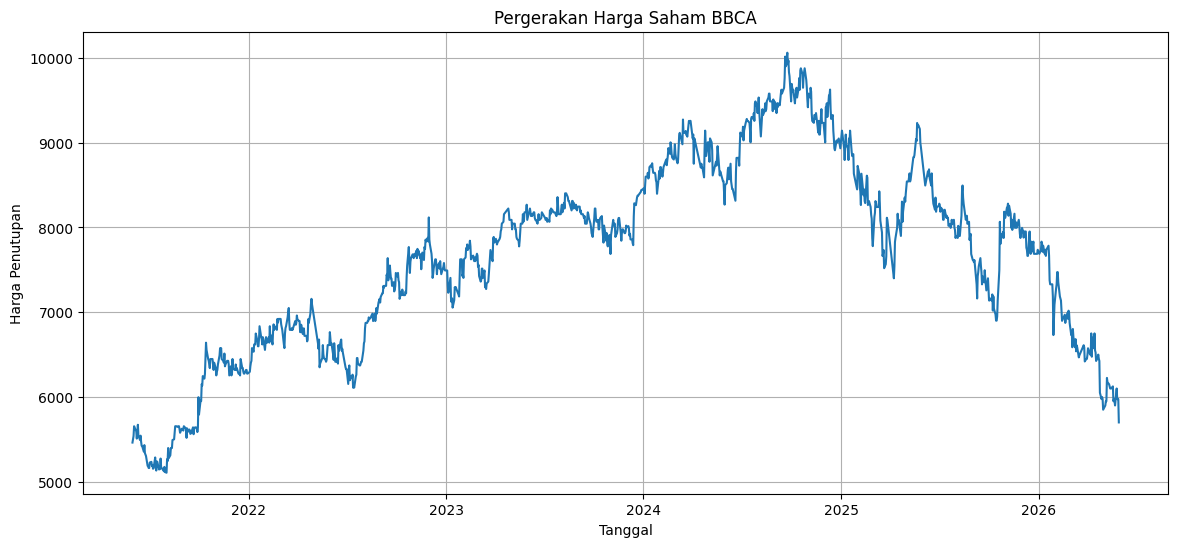

In [33]:
# Mengatur ukuran grafik
plt.figure(figsize=(14,6))

# Membuat grafik harga penutupan BBCA
plt.plot(
    bbca_clean["Date"],
    bbca_clean["Close"]
)

# Memberikan judul grafik
plt.title("Pergerakan Harga Saham BBCA")

# Memberikan label sumbu x
plt.xlabel("Tanggal")

# Memberikan label sumbu y
plt.ylabel("Harga Penutupan")

# Menampilkan grid
plt.grid(True)

# Menampilkan grafik
plt.show()

Insight

- Berdasarkan grafik pergerakan harga saham BBCA selama periode pengamatan, terlihat bahwa saham ini mengalami tren kenaikan yang cukup konsisten dari tahun 2021 hingga mencapai puncaknya pada akhir tahun 2024. Harga saham sempat menyentuh level di atas 10.000 sebelum mengalami koreksi yang cukup signifikan pada tahun 2025 hingga pertengahan 2026.

- Meskipun mengalami penurunan pada periode akhir pengamatan, secara keseluruhan BBCA masih menunjukkan performa yang relatif stabil dibandingkan saham lainnya. Fluktuasi harga yang terjadi juga terlihat lebih terkontrol dan tidak menunjukkan lonjakan atau penurunan yang terlalu ekstrem.

- Dari sudut pandang investasi, BBCA dapat dianggap sebagai salah satu saham dengan fundamental yang kuat karena mampu mempertahankan tren kenaikan dalam jangka panjang meskipun kondisi pasar mengalami perubahan. Karakteristik seperti ini biasanya lebih menarik bagi investor yang mengutamakan kestabilan dibandingkan pertumbuhan yang sangat agresif.

### 4.2.2 BBRI

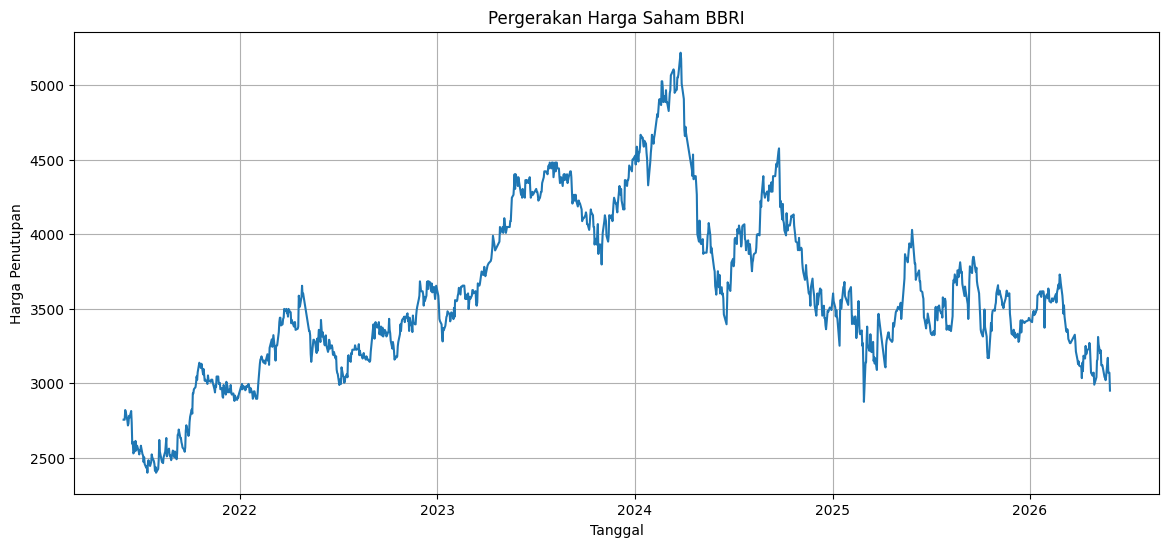

In [34]:
# Mengatur ukuran grafik
plt.figure(figsize=(14,6))

# Membuat grafik harga penutupan BBRI
plt.plot(
    bbri_clean["Date"],
    bbri_clean["Close"]
)

# Memberikan judul grafik
plt.title("Pergerakan Harga Saham BBRI")

# Memberikan label sumbu x
plt.xlabel("Tanggal")

# Memberikan label sumbu y
plt.ylabel("Harga Penutupan")

# Menampilkan grid
plt.grid(True)

# Menampilkan grafik
plt.show()

Insight

- Grafik BBRI menunjukkan pola yang cukup menarik. Harga saham mengalami kenaikan yang cukup kuat sejak tahun 2021 hingga mencapai puncaknya pada awal tahun 2024. Setelah itu terjadi penurunan yang cukup tajam dan harga cenderung bergerak dalam pola sideways hingga akhir periode pengamatan.

- Pergerakan harga BBRI terlihat lebih fluktuatif dibandingkan BBCA, terutama setelah tahun 2024. Hal ini menunjukkan bahwa saham BBRI memiliki sensitivitas yang lebih tinggi terhadap kondisi pasar maupun sentimen investor.

- Walaupun demikian, BBRI masih menunjukkan potensi return yang menarik karena pernah mengalami pertumbuhan harga yang cukup tinggi dalam waktu relatif singkat. Oleh karena itu, saham ini dapat menjadi pilihan bagi investor yang masih bersedia menerima risiko moderat untuk memperoleh peluang keuntungan yang lebih besar.

### 4.2.3 BBNI

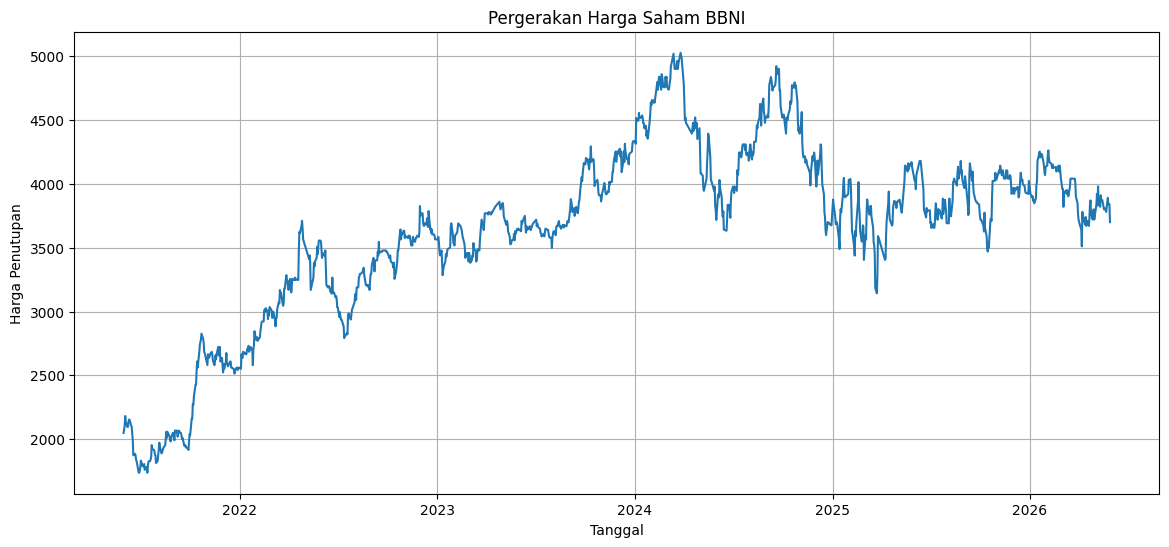

In [35]:
# Mengatur ukuran grafik
plt.figure(figsize=(14,6))

# Membuat grafik harga penutupan BBNI
plt.plot(
    bbni_clean["Date"],
    bbni_clean["Close"]
)

# Memberikan judul grafik
plt.title("Pergerakan Harga Saham BBNI")

# Memberikan label sumbu x
plt.xlabel("Tanggal")

# Memberikan label sumbu y
plt.ylabel("Harga Penutupan")

# Menampilkan grid
plt.grid(True)

# Menampilkan grafik
plt.show()

Insight

- Pergerakan harga saham BBNI menunjukkan tren pertumbuhan yang cukup baik dari tahun 2021 hingga tahun 2024. Harga saham meningkat lebih dari dua kali lipat dibandingkan awal periode pengamatan sebelum akhirnya mengalami koreksi pada tahun berikutnya.

- Dibandingkan saham perbankan lainnya, BBNI terlihat memiliki fluktuasi yang lebih tinggi. Beberapa kali terjadi kenaikan dan penurunan harga dalam waktu yang relatif singkat, yang menunjukkan bahwa saham ini memiliki tingkat risiko yang lebih besar.

- Meskipun demikian, harga saham BBNI masih mampu bertahan pada level yang lebih tinggi dibandingkan periode awal pengamatan. Kondisi ini menunjukkan bahwa saham BBNI masih memiliki potensi pertumbuhan, namun investor perlu mempertimbangkan risiko pergerakan harga yang lebih agresif.

### 4.2.4 BMRI

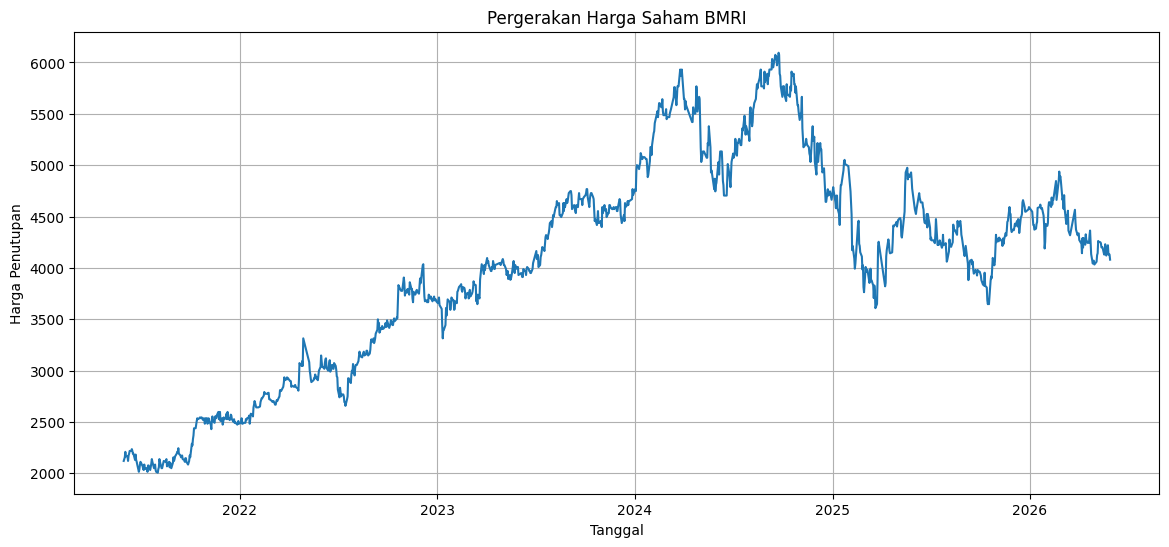

In [36]:
# Mengatur ukuran grafik
plt.figure(figsize=(14,6))

# Membuat grafik harga penutupan BMRI
plt.plot(
    bmri_clean["Date"],
    bmri_clean["Close"]
)

# Memberikan judul grafik
plt.title("Pergerakan Harga Saham BMRI")

# Memberikan label sumbu x
plt.xlabel("Tanggal")

# Memberikan label sumbu y
plt.ylabel("Harga Penutupan")

# Menampilkan grid
plt.grid(True)

# Menampilkan grafik
plt.show()

Insight

- Saham BMRI menunjukkan tren kenaikan yang sangat kuat sejak tahun 2021 hingga mencapai puncaknya pada akhir tahun 2024. Selama periode tersebut, harga saham meningkat secara bertahap dengan beberapa fase konsolidasi yang wajar.

- Setelah mencapai harga tertinggi, BMRI mengalami koreksi yang cukup besar pada tahun 2025. Namun berbeda dengan beberapa saham lainnya, harga BMRI masih mampu bertahan pada level yang relatif tinggi dan tidak kembali ke harga awal periode pengamatan.

- Pergerakan ini menunjukkan bahwa BMRI memiliki kombinasi antara potensi pertumbuhan dan stabilitas yang cukup baik. Dari sisi investasi, BMRI dapat menjadi salah satu alternatif yang menarik bagi investor yang menginginkan keseimbangan antara risiko dan peluang return.

### 4.2.5 ICBP

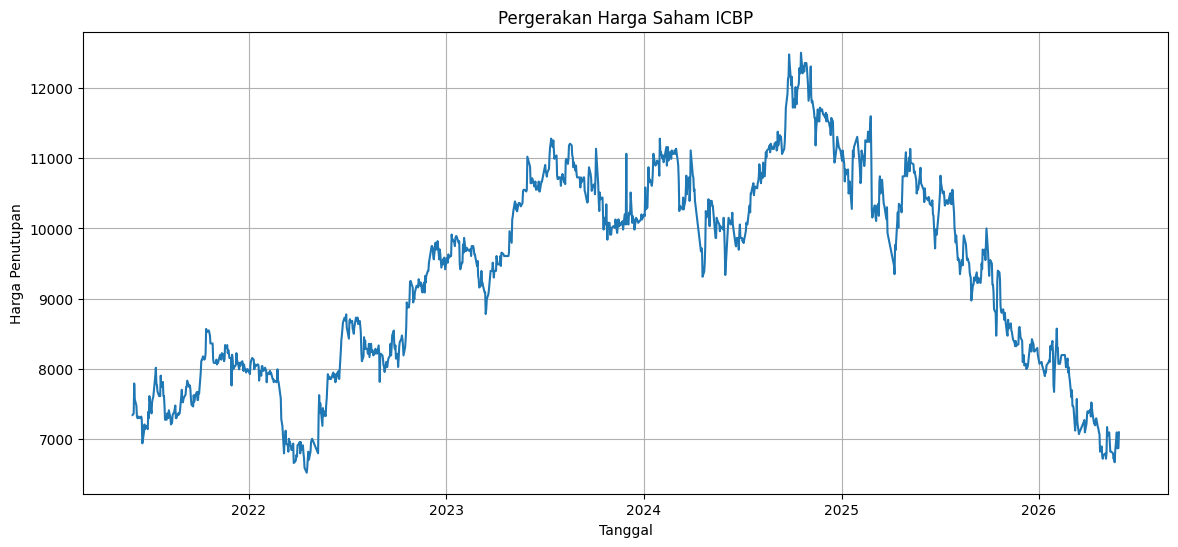

In [37]:
# Mengatur ukuran grafik
plt.figure(figsize=(14,6))

# Membuat grafik harga penutupan ICBP
plt.plot(
    icbp_clean["Date"],
    icbp_clean["Close"]
)

# Memberikan judul grafik
plt.title("Pergerakan Harga Saham ICBP")

# Memberikan label sumbu x
plt.xlabel("Tanggal")

# Memberikan label sumbu y
plt.ylabel("Harga Penutupan")

# Menampilkan grid
plt.grid(True)

# Menampilkan grafik
plt.show()

Insight

- Berdasarkan grafik, saham ICBP menunjukkan pola kenaikan yang cukup stabil hingga tahun 2024. Harga saham sempat mencapai level tertinggi di atas 12.000 sebelum mengalami tren penurunan secara bertahap hingga akhir periode pengamatan.

- Dibandingkan sektor perbankan, pergerakan harga ICBP terlihat lebih stabil dan tidak terlalu agresif. Hal ini sesuai dengan karakteristik perusahaan sektor consumer goods yang umumnya memiliki permintaan produk yang lebih konsisten.

- Walaupun harga saham mengalami penurunan dalam beberapa tahun terakhir, volatilitasnya masih relatif lebih rendah dibandingkan beberapa saham perbankan. Oleh karena itu, ICBP berpotensi menjadi aset pelengkap dalam portofolio untuk membantu mengurangi risiko melalui diversifikasi sektor.

### 4.2.6 MYOR

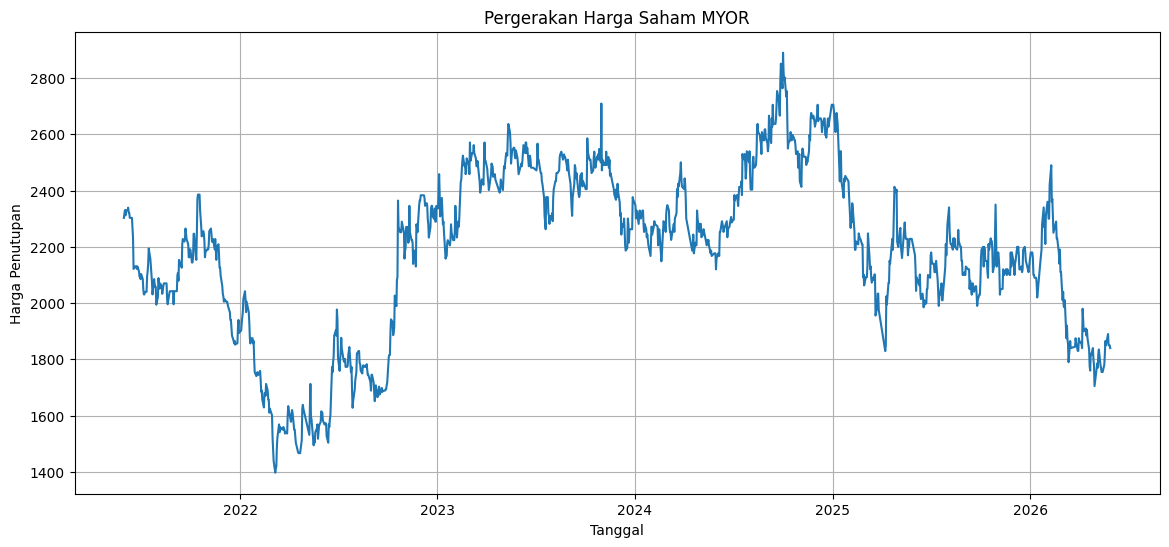

In [38]:
# Mengatur ukuran grafik
plt.figure(figsize=(14,6))

# Membuat grafik harga penutupan MYOR
plt.plot(
    myor_clean["Date"],
    myor_clean["Close"]
)

# Memberikan judul grafik
plt.title("Pergerakan Harga Saham MYOR")

# Memberikan label sumbu x
plt.xlabel("Tanggal")

# Memberikan label sumbu y
plt.ylabel("Harga Penutupan")

# Menampilkan grid
plt.grid(True)

# Menampilkan grafik
plt.show()

Insight

- Pergerakan harga saham MYOR cenderung berbeda dibandingkan saham lainnya. Setelah mengalami penurunan cukup tajam pada tahun 2022, harga saham berhasil pulih dan mencapai puncaknya pada akhir tahun 2024. Namun setelah itu kembali mengalami penurunan hingga akhir periode pengamatan.

- Dari grafik terlihat bahwa MYOR bergerak dalam rentang harga yang relatif sempit dibandingkan saham perbankan maupun ICBP. Meskipun demikian, fluktuasi jangka pendek cukup sering terjadi sehingga menunjukkan adanya volatilitas yang perlu diperhatikan.

- Kondisi ini menunjukkan bahwa MYOR memiliki peluang pertumbuhan, tetapi performanya tidak sekuat beberapa saham sektor perbankan dalam periode yang sama. Investor yang memilih saham ini perlu memperhatikan kondisi industri consumer goods dan daya beli masyarakat yang dapat memengaruhi kinerja perusahaan.

### 4.2.7 TLKM

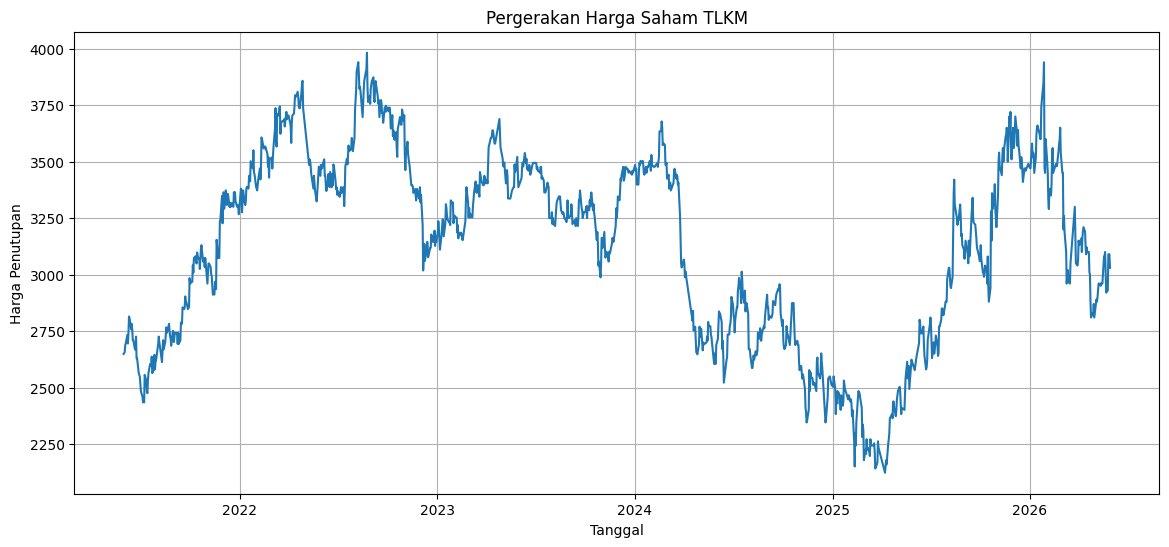

In [39]:
# Mengatur ukuran grafik
plt.figure(figsize=(14,6))

# Membuat grafik harga penutupan TLKM
plt.plot(
    tlkm_clean["Date"],
    tlkm_clean["Close"]
)

# Memberikan judul grafik
plt.title("Pergerakan Harga Saham TLKM")

# Memberikan label sumbu x
plt.xlabel("Tanggal")

# Memberikan label sumbu y
plt.ylabel("Harga Penutupan")

# Menampilkan grid
plt.grid(True)

# Menampilkan grafik
plt.show()

Insight

- Berbeda dengan saham lainnya, TLKM tidak menunjukkan tren kenaikan jangka panjang yang kuat selama periode pengamatan. Harga saham cenderung bergerak naik dan turun dalam rentang tertentu tanpa membentuk tren pertumbuhan yang konsisten.

- Pada tahun 2025 terlihat terjadi penurunan yang cukup signifikan sebelum akhirnya kembali mengalami pemulihan pada akhir periode. Namun secara keseluruhan, harga saham TLKM masih berada pada kisaran yang tidak jauh berbeda dibandingkan beberapa tahun sebelumnya.

- Pergerakan yang relatif stabil ini menunjukkan bahwa TLKM memiliki karakteristik yang lebih defensif dibandingkan saham dengan pertumbuhan tinggi. Meskipun potensi capital gain mungkin tidak sebesar saham perbankan, TLKM masih dapat dipertimbangkan sebagai bagian dari strategi diversifikasi portofolio karena berasal dari sektor yang berbeda.

### 4.2.8 Visualisasi Seluruh Saham

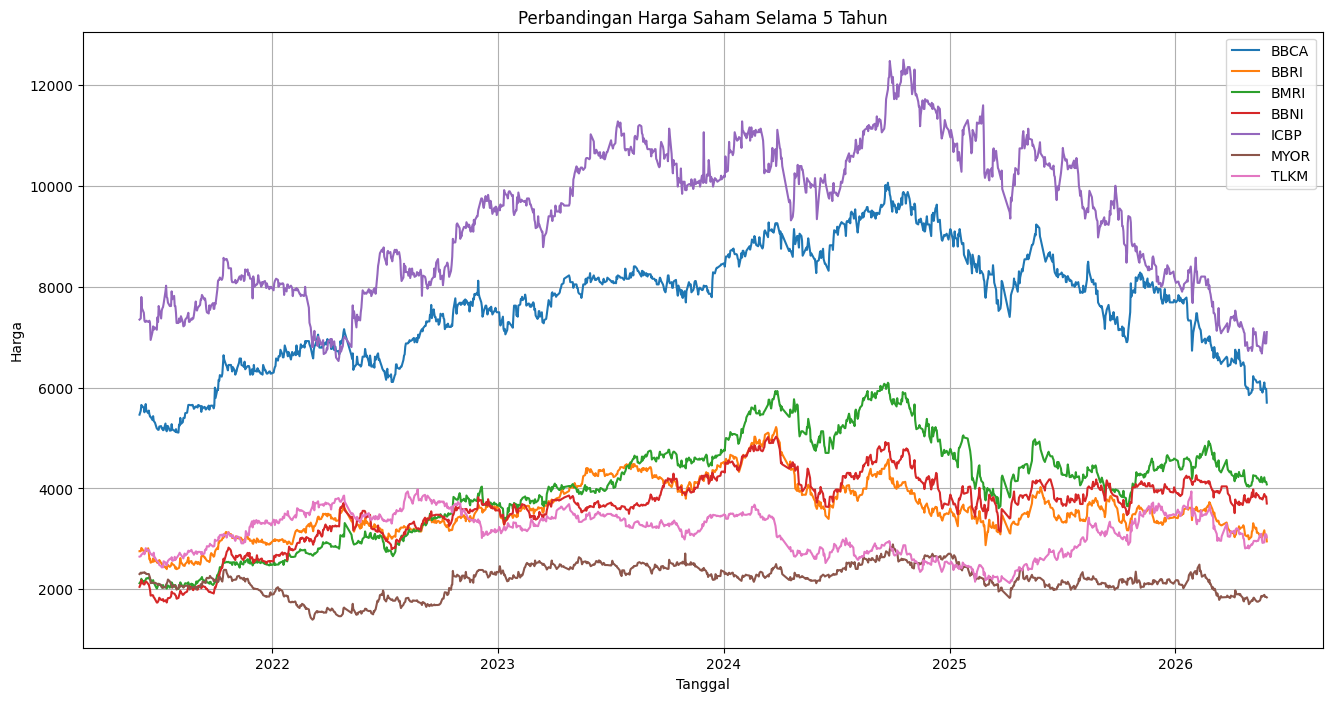

In [40]:
# Membuat figure
plt.figure(figsize=(16,8))

# Menampilkan harga BBCA
plt.plot(
    bbca_clean["Date"],
    bbca_clean["Close"],
    label="BBCA"
)

# Menampilkan harga BBRI
plt.plot(
    bbri_clean["Date"],
    bbri_clean["Close"],
    label="BBRI"
)

# Menampilkan harga BMRI
plt.plot(
    bmri_clean["Date"],
    bmri_clean["Close"],
    label="BMRI"
)

# Menampilkan harga BBNI
plt.plot(
    bbni_clean["Date"],
    bbni_clean["Close"],
    label="BBNI"
)

# Menampilkan harga ICBP
plt.plot(
    icbp_clean["Date"],
    icbp_clean["Close"],
    label="ICBP"
)

# Menampilkan harga MYOR
plt.plot(
    myor_clean["Date"],
    myor_clean["Close"],
    label="MYOR"
)

# Menampilkan harga TLKM
plt.plot(
    tlkm_clean["Date"],
    tlkm_clean["Close"],
    label="TLKM"
)

# Judul grafik
plt.title("Perbandingan Harga Saham Selama 5 Tahun")

# Label sumbu
plt.xlabel("Tanggal")
plt.ylabel("Harga")

# Menampilkan legenda
plt.legend()

# Menampilkan grid
plt.grid(True)

# Menampilkan grafik
plt.show()

Kesimpulan

- Berdasarkan seluruh grafik pergerakan harga saham, terlihat bahwa sektor perbankan seperti BBCA, BMRI, BBRI, dan BBNI mendominasi pertumbuhan harga selama periode pengamatan. BMRI dan BBCA menunjukkan tren kenaikan yang paling konsisten sebelum mengalami koreksi pada periode akhir. Sementara itu, BBRI dan BBNI memiliki pola pertumbuhan yang baik namun disertai fluktuasi yang lebih tinggi.

- Di luar sektor perbankan, ICBP, MYOR, dan TLKM menunjukkan pergerakan yang lebih moderat. Saham-saham tersebut dapat berperan sebagai instrumen diversifikasi karena berasal dari sektor yang berbeda dan memiliki karakteristik risiko yang tidak sepenuhnya sama dengan saham perbankan.

- Secara umum, seluruh saham mengalami fase pertumbuhan hingga sekitar tahun 2024, kemudian diikuti oleh periode koreksi pada tahun 2025 hingga 2026. Temuan ini menunjukkan bahwa kondisi pasar secara keseluruhan memiliki pengaruh yang cukup besar terhadap pergerakan harga saham selama periode observasi

## 4.3 Distribusi Harga

### 4.3.1 BBCA

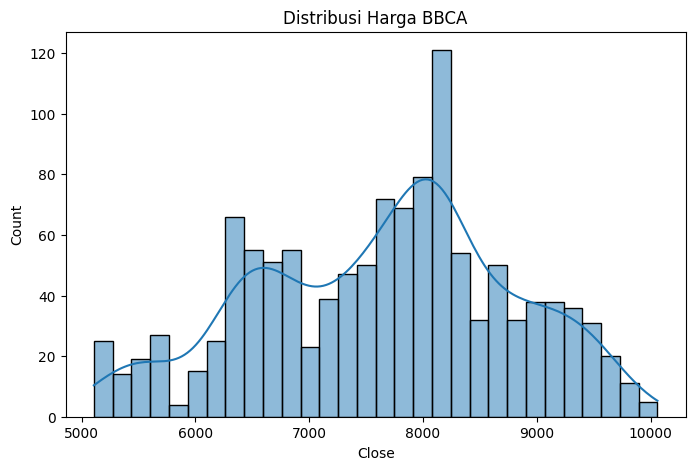

In [41]:
# Mengatur ukuran grafik
plt.figure(figsize=(8,5))

# Membuat histogram harga BBCA
sns.histplot(
    bbca_clean["Close"],
    bins=30,
    kde=True
)

# Judul grafik
plt.title("Distribusi Harga BBCA")

# Menampilkan grafik
plt.show()

Insight

- Berdasarkan histogram distribusi harga BBCA, terlihat bahwa sebagian besar harga saham berada pada rentang sekitar 7.500 hingga 8.500. Hal ini menunjukkan bahwa selama periode pengamatan, BBCA lebih sering diperdagangkan pada level harga tersebut dibandingkan rentang harga lainnya.

- Distribusi harga juga terlihat cukup menyebar dari sekitar 5.000 hingga lebih dari 10.000, yang mencerminkan adanya fase pertumbuhan harga yang cukup signifikan dalam beberapa tahun terakhir. Selain itu, tidak terlihat adanya lonjakan ekstrem yang mendominasi distribusi, sehingga pergerakan harga BBCA dapat dikatakan relatif stabil.

- Temuan ini memperkuat hasil analisis tren sebelumnya yang menunjukkan bahwa BBCA memiliki karakteristik saham dengan pertumbuhan yang baik serta tingkat kestabilan yang cukup tinggi dibandingkan saham lainnya.

### 4.3.2 BBRI

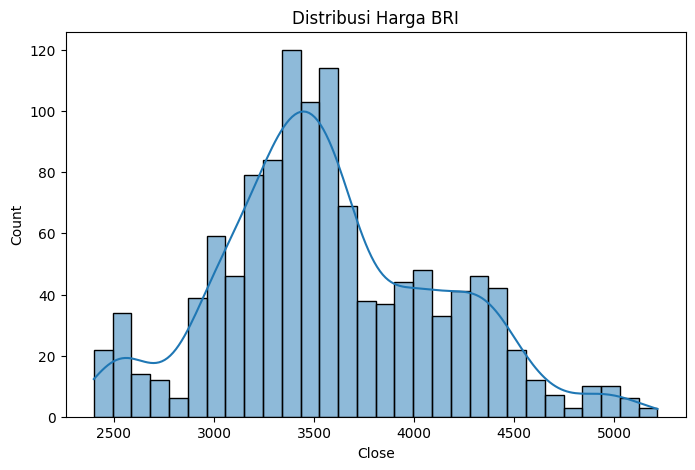

In [42]:
# Mengatur ukuran grafik
plt.figure(figsize=(8,5))

# Membuat histogram harga BRI
sns.histplot(
    bbri_clean["Close"],
    bins=30,
    kde=True
)

# Judul grafik
plt.title("Distribusi Harga BRI")

# Menampilkan grafik
plt.show()

Insight

- Distribusi harga BBRI menunjukkan bahwa sebagian besar data terkonsentrasi pada rentang harga 3.200 hingga 3.800. Hal ini menandakan bahwa harga saham BBRI cukup sering berada pada level tersebut selama periode observasi.

- Selain itu, distribusi terlihat sedikit condong ke arah harga yang lebih tinggi hingga mencapai kisaran 5.000. Kondisi ini menunjukkan bahwa BBRI sempat mengalami fase kenaikan yang cukup kuat meskipun tidak berlangsung secara konsisten sepanjang periode pengamatan.

- Secara umum, distribusi harga BBRI menunjukkan adanya variasi harga yang cukup besar sehingga mencerminkan peluang return yang menarik, namun juga disertai tingkat fluktuasi yang perlu diperhatikan oleh investor.

### 4.3.3 BMRI

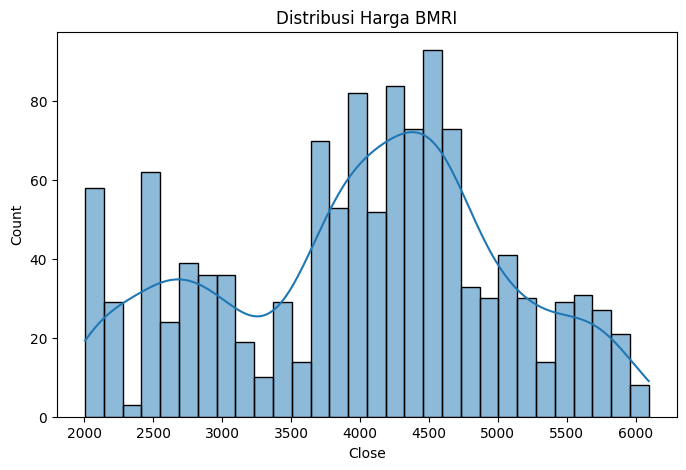

In [43]:
# Mengatur ukuran grafik
plt.figure(figsize=(8,5))

# Membuat histogram harga BMRI
sns.histplot(
    bmri_clean["Close"],
    bins=30,
    kde=True
)

# Judul grafik
plt.title("Distribusi Harga BMRI")

# Menampilkan grafik
plt.show()

Insight

- Histogram BMRI menunjukkan bahwa harga saham paling sering berada pada kisaran 3.800 hingga 4.800. Distribusi harga terlihat cukup lebar dengan rentang harga mulai dari sekitar 2.000 hingga lebih dari 6.000.

- Sebaran yang cukup luas ini menunjukkan bahwa BMRI mengalami perubahan harga yang cukup signifikan selama periode pengamatan. Hal tersebut sejalan dengan tren harga sebelumnya yang menunjukkan adanya pertumbuhan kuat sebelum mengalami koreksi.

- Meskipun memiliki fluktuasi yang cukup tinggi, mayoritas harga tetap terkonsentrasi pada level menengah sehingga menunjukkan bahwa BMRI masih memiliki kestabilan yang cukup baik dalam jangka panjang.

### 4.3.4 BBNI

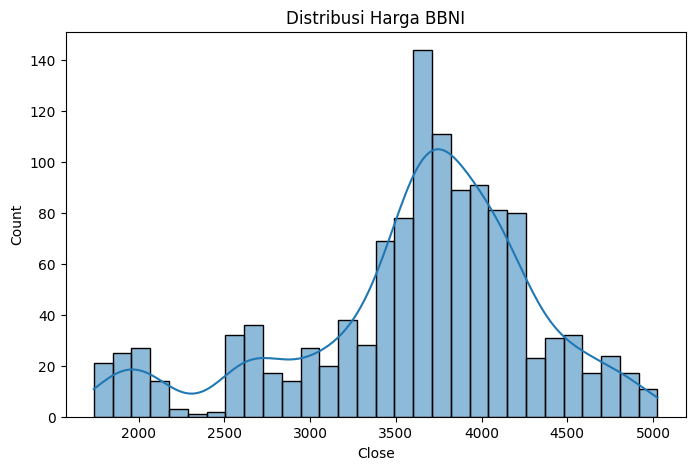

In [44]:
# Mengatur ukuran grafik
plt.figure(figsize=(8,5))

# Membuat histogram harga BBNI
sns.histplot(
    bbni_clean["Close"],
    bins=30,
    kde=True
)

# Judul grafik
plt.title("Distribusi Harga BBNI")

# Menampilkan grafik
plt.show()

Insight

- Distribusi harga BBNI didominasi oleh rentang harga sekitar 3.500 hingga 4.200. Sebagian besar transaksi selama periode observasi terjadi pada kisaran tersebut sehingga dapat dianggap sebagai area harga yang paling sering muncul.

- Jika dibandingkan dengan saham perbankan lainnya, distribusi harga BBNI terlihat cukup terpusat meskipun tetap memiliki rentang harga yang cukup luas. Hal ini menunjukkan bahwa BBNI mengalami beberapa fase kenaikan dan penurunan harga, tetapi masih mampu mempertahankan harga pada level tertentu dalam jangka waktu yang cukup panjang.

- Karakteristik seperti ini menunjukkan bahwa BBNI memiliki potensi pertumbuhan yang baik namun tetap diiringi dengan risiko fluktuasi yang perlu diperhatikan.

### 4.3.5 MYOR

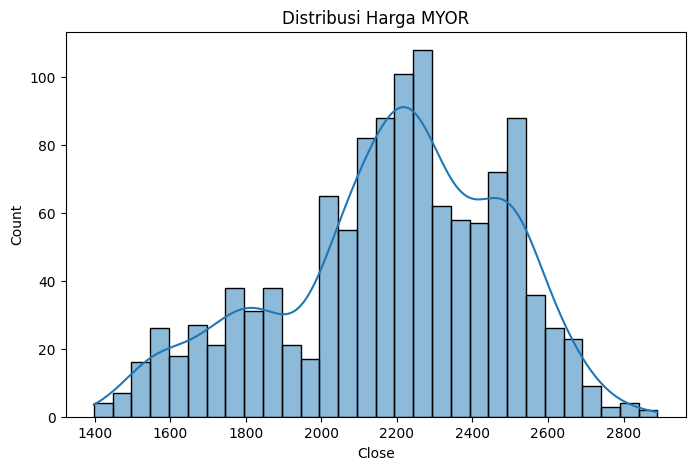

In [45]:
# Mengatur ukuran grafik
plt.figure(figsize=(8,5))

# Membuat histogram harga MYOR
sns.histplot(
    myor_clean["Close"],
    bins=30,
    kde=True
)

# Judul grafik
plt.title("Distribusi Harga MYOR")

# Menampilkan grafik
plt.show()

Insight

- Berdasarkan histogram, harga saham MYOR paling banyak berada pada rentang sekitar 2.100 hingga 2.500. Sebaran harga terlihat relatif lebih sempit dibandingkan saham perbankan yang dianalisis sebelumnya.

- Distribusi yang lebih terkonsentrasi menunjukkan bahwa perubahan harga MYOR tidak terlalu ekstrem. Namun demikian, terdapat beberapa periode ketika harga bergerak di bawah maupun di atas rentang utama tersebut yang menunjukkan adanya pengaruh kondisi pasar terhadap pergerakan saham.

- Secara keseluruhan, MYOR menunjukkan karakteristik pergerakan harga yang relatif stabil dengan tingkat variasi harga yang tidak terlalu besar dibandingkan beberapa saham lainnya.

### 4.3.6 ICBP

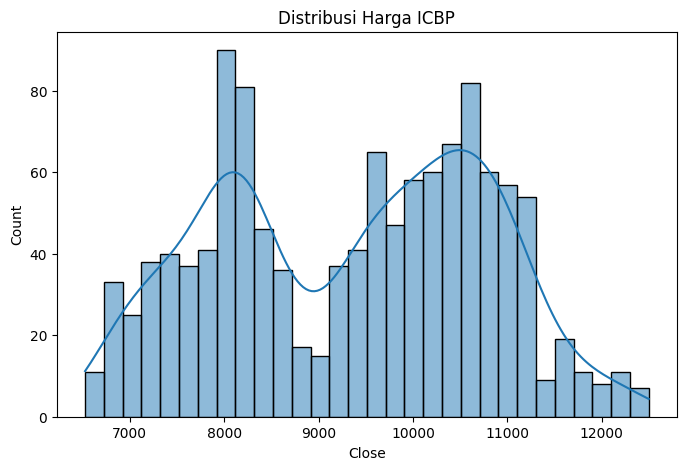

In [46]:
# Mengatur ukuran grafik
plt.figure(figsize=(8,5))

# Membuat histogram harga ICBP
sns.histplot(
    icbp_clean["Close"],
    bins=30,
    kde=True
)

# Judul grafik
plt.title("Distribusi Harga ICBP")

# Menampilkan grafik
plt.show()

Insight

- Distribusi harga ICBP menunjukkan dua area konsentrasi utama, yaitu pada kisaran 7.500–8.500 dan 10.000–11.000. Pola ini mengindikasikan bahwa selama periode pengamatan terdapat dua fase harga dominan yang cukup berbeda.

- Fenomena tersebut menunjukkan bahwa ICBP mengalami perubahan level harga yang cukup signifikan dalam jangka panjang. Saham ini sempat diperdagangkan pada level yang lebih rendah sebelum akhirnya bergerak ke rentang harga yang lebih tinggi dalam periode berikutnya.

- Dari sisi investasi, kondisi ini menunjukkan bahwa ICBP memiliki kemampuan untuk menciptakan pertumbuhan nilai, meskipun pergerakannya cenderung lebih lambat dan stabil dibandingkan saham sektor perbankan.

### 4.3.7 TLKM

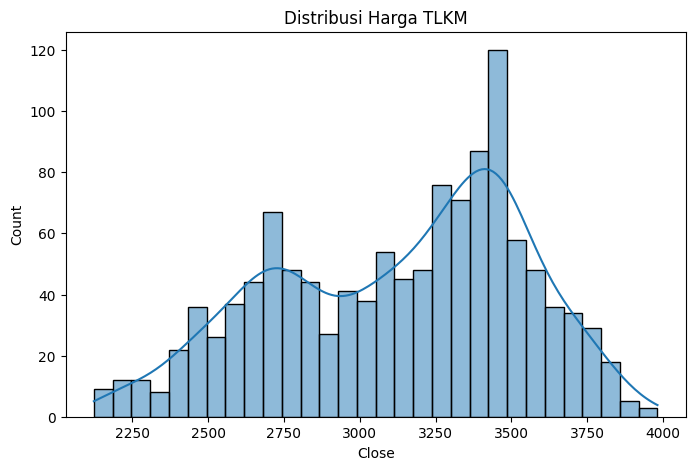

In [47]:
# Mengatur ukuran grafik
plt.figure(figsize=(8,5))

# Membuat histogram harga TLKM
sns.histplot(
    tlkm_clean["Close"],
    bins=30,
    kde=True
)

# Judul grafik
plt.title("Distribusi Harga TLKM")

# Menampilkan grafik
plt.show()

Insight

- Distribusi harga TLKM memperlihatkan bahwa sebagian besar harga saham berada pada rentang 3.200 hingga 3.600. Sebaran harga terlihat cukup terpusat dan tidak terlalu melebar dibandingkan beberapa saham lainnya.

- Hal ini menunjukkan bahwa harga TLKM relatif sering bergerak di sekitar rentang tersebut selama periode observasi. Meskipun terdapat beberapa periode kenaikan dan penurunan, perubahan harga yang terjadi masih berada dalam batas yang relatif terkendali.

- Karakteristik distribusi seperti ini menunjukkan bahwa TLKM memiliki tingkat kestabilan yang cukup baik dan tidak mengalami perubahan harga yang terlalu ekstrem. Oleh karena itu, saham TLKM dapat menjadi salah satu alternatif bagi investor yang menginginkan aset dengan pergerakan harga yang lebih defensif.

Kesimpulan Distribusi Harga

- Secara keseluruhan, distribusi harga menunjukkan bahwa setiap saham memiliki karakteristik pergerakan yang berbeda. Saham perbankan seperti BBCA, BBRI, BMRI, dan BBNI memiliki rentang distribusi yang relatif lebih lebar, yang mengindikasikan adanya peluang pertumbuhan yang lebih besar namun disertai fluktuasi harga yang lebih tinggi.

- Di sisi lain, saham sektor consumer goods dan telekomunikasi seperti ICBP, MYOR, dan TLKM cenderung memiliki distribusi harga yang lebih terkonsentrasi. Kondisi ini menunjukkan pergerakan harga yang relatif lebih stabil dan berpotensi memberikan fungsi diversifikasi dalam penyusunan portofolio investasi.

- Hasil analisis distribusi harga ini memberikan gambaran awal mengenai karakteristik masing-masing aset sebelum dilakukan analisis return, volatilitas, dan risiko investasi pada tahap berikutnya.

## 4.4 Daily Return Analysis

Karena investor tidak melihat harga, tetapi return.

### 4.4.1 BBCA

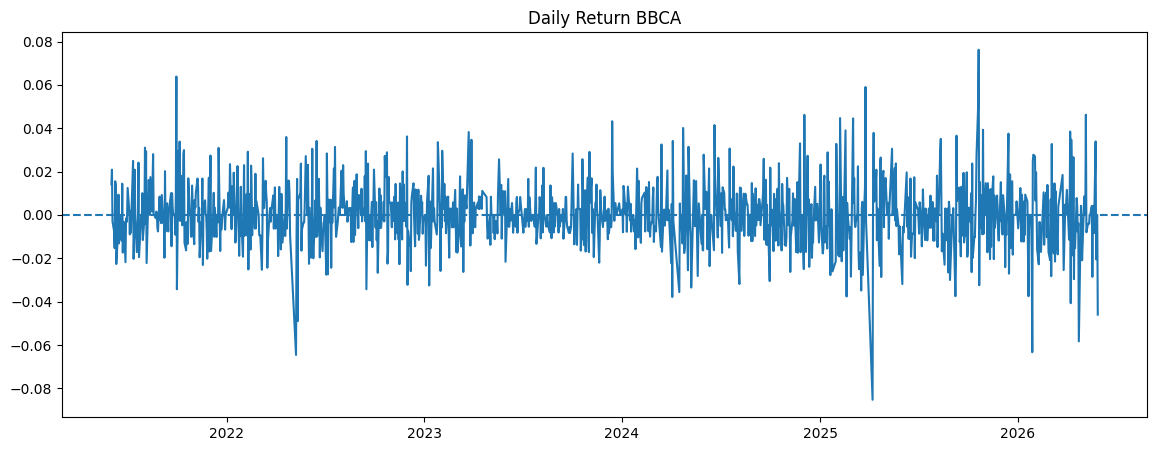

In [48]:
# Menghitung return harian BBCA
bbca_clean["Daily_Return"] = (
    bbca_clean["Close"].pct_change()
)

# Mengatur ukuran grafik
plt.figure(figsize=(14,5))

# Membuat grafik return harian
plt.plot(
    bbca_clean["Date"],
    bbca_clean["Daily_Return"]
)

# Memberikan judul
plt.title("Daily Return BBCA")

# Menampilkan garis horizontal pada 0
plt.axhline(0, linestyle="--")

# Menampilkan grafik
plt.show()

Insight

- Berdasarkan grafik daily return, pergerakan return harian saham BBCA sebagian besar berfluktuasi di sekitar nilai nol. Hal ini menunjukkan bahwa perubahan harga harian BBCA relatif stabil dan tidak sering mengalami lonjakan yang terlalu ekstrem.

- Meskipun terdapat beberapa periode dengan return positif maupun negatif yang cukup besar, frekuensinya tidak terlalu sering dibandingkan mayoritas data. Kondisi ini menunjukkan bahwa risiko jangka pendek BBCA masih tergolong terkendali.

- Dari sudut pandang investor, BBCA dapat dianggap sebagai saham yang memiliki kestabilan cukup baik dengan peluang return yang konsisten dalam jangka panjang. Karakteristik ini umumnya lebih cocok untuk investor yang mengutamakan keseimbangan antara pertumbuhan dan risiko.

### 4.4.2 BBRI

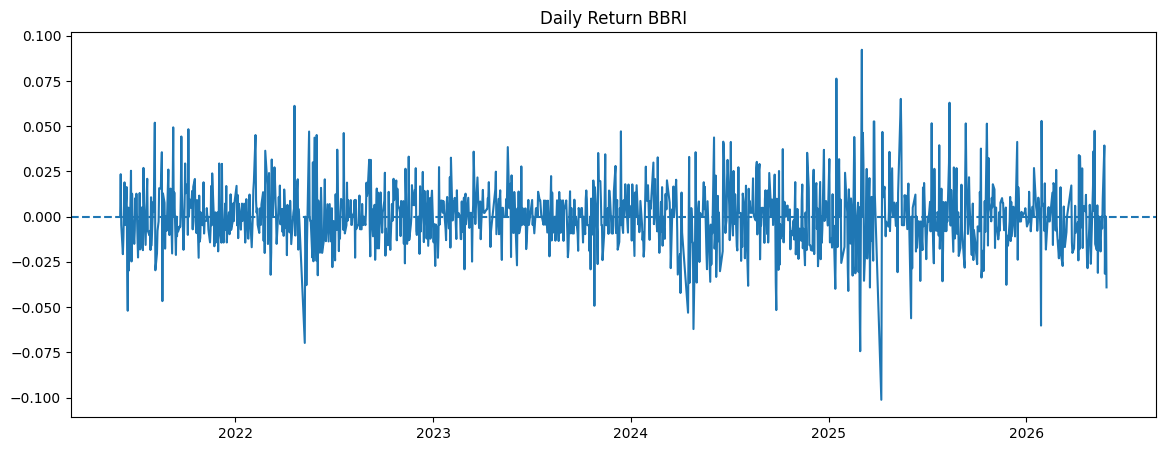

In [49]:
# Menghitung return harian BBRI
bbri_clean["Daily_Return"] = (
    bbri_clean["Close"].pct_change()
)

# Mengatur ukuran grafik
plt.figure(figsize=(14,5))

# Membuat grafik return harian
plt.plot(
    bbri_clean["Date"],
    bbri_clean["Daily_Return"]
)

# Memberikan judul
plt.title("Daily Return BBRI")

# Menampilkan garis horizontal pada 0
plt.axhline(0, linestyle="--")

# Menampilkan grafik
plt.show()

Insight

- Grafik daily return BBRI menunjukkan fluktuasi yang relatif lebih besar dibandingkan BBCA. Terlihat beberapa lonjakan return positif maupun negatif yang cukup tinggi, terutama pada periode tahun 2024 hingga 2025.

- Pergerakan yang lebih agresif ini menunjukkan bahwa harga saham BBRI lebih sensitif terhadap perubahan kondisi pasar maupun sentimen investor. Hal tersebut memberikan peluang keuntungan yang lebih besar, tetapi di sisi lain juga meningkatkan risiko kerugian dalam jangka pendek.

- Dengan karakteristik tersebut, BBRI dapat dikategorikan sebagai saham yang memiliki potensi return menarik namun membutuhkan toleransi risiko yang lebih tinggi dibandingkan saham yang lebih stabil.

### 4.4.3 BMRI

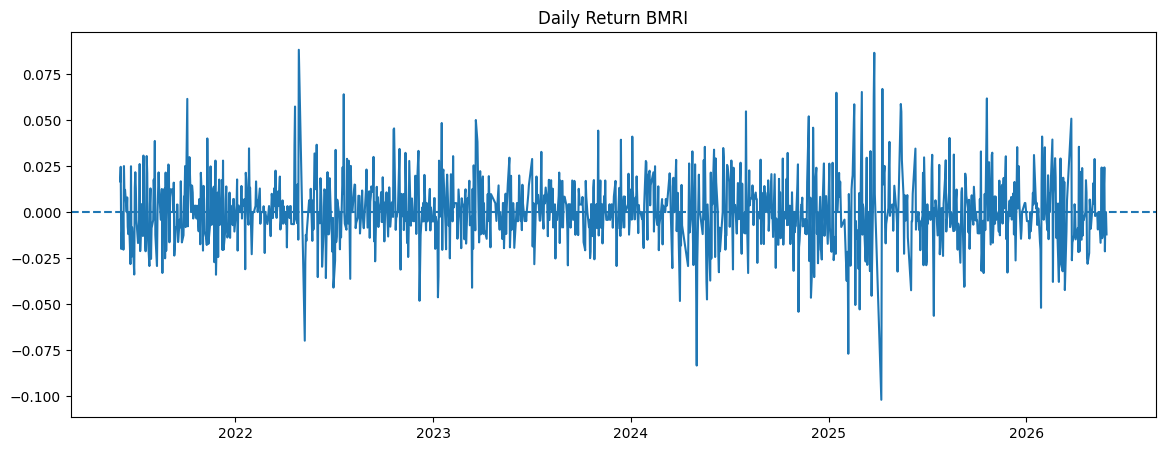

In [50]:
# Menghitung return harian BMRI
bmri_clean["Daily_Return"] = (
    bmri_clean["Close"].pct_change()
)

# Mengatur ukuran grafik
plt.figure(figsize=(14,5))

# Membuat grafik return harian
plt.plot(
    bmri_clean["Date"],
    bmri_clean["Daily_Return"]
)

# Memberikan judul
plt.title("Daily Return BMRI")

# Menampilkan garis horizontal pada 0
plt.axhline(0, linestyle="--")

# Menampilkan grafik
plt.show()

Insight

- Pergerakan daily return BMRI menunjukkan pola yang cukup seimbang antara return positif dan negatif. Sebagian besar return masih berada di sekitar nilai nol, namun terdapat beberapa lonjakan yang cukup signifikan terutama pada periode akhir pengamatan.

- Kondisi ini menunjukkan bahwa saham BMRI memiliki tingkat volatilitas yang cukup tinggi, tetapi masih berada dalam batas yang wajar untuk saham sektor perbankan. Selain itu, tidak terlihat adanya periode ekstrem yang berlangsung terlalu lama.

- Secara umum, BMRI memiliki karakteristik yang cukup menarik karena menawarkan peluang pertumbuhan yang baik dengan tingkat risiko yang masih dapat diterima oleh investor dengan profil risiko moderat.

### 4.4.4 BBNI

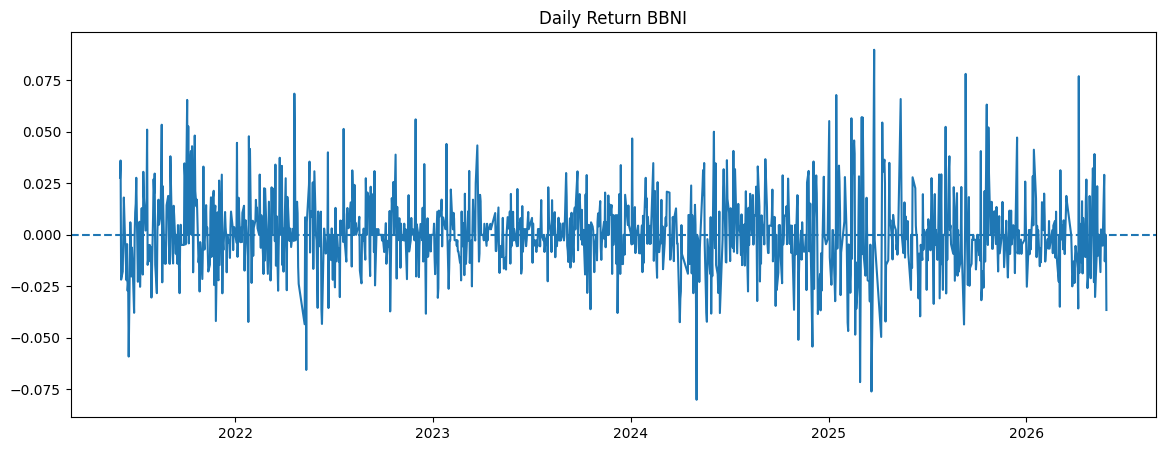

In [51]:
# Menghitung return harian BBNI
bbni_clean["Daily_Return"] = (
    bbni_clean["Close"].pct_change()
)

# Mengatur ukuran grafik
plt.figure(figsize=(14,5))

# Membuat grafik return harian
plt.plot(
    bbni_clean["Date"],
    bbni_clean["Daily_Return"]
)

# Memberikan judul
plt.title("Daily Return BBNI")

# Menampilkan garis horizontal pada 0
plt.axhline(0, linestyle="--")

# Menampilkan grafik
plt.show()

Insight

- Grafik daily return BBNI menunjukkan fluktuasi yang cukup aktif sepanjang periode pengamatan. Beberapa kali terlihat lonjakan return positif maupun negatif yang relatif besar dibandingkan rata-rata pergerakan hariannya.

- Variasi return yang cukup tinggi ini menunjukkan bahwa saham BBNI memiliki tingkat ketidakpastian yang lebih besar dibandingkan beberapa saham lainnya. Investor berpotensi memperoleh keuntungan yang lebih tinggi, namun juga harus siap menghadapi risiko penurunan harga yang lebih besar.

- Oleh karena itu, BBNI lebih sesuai bagi investor yang memiliki toleransi risiko sedang hingga tinggi dan menginginkan potensi return yang lebih agresif.

### 4.4.5 MYOR

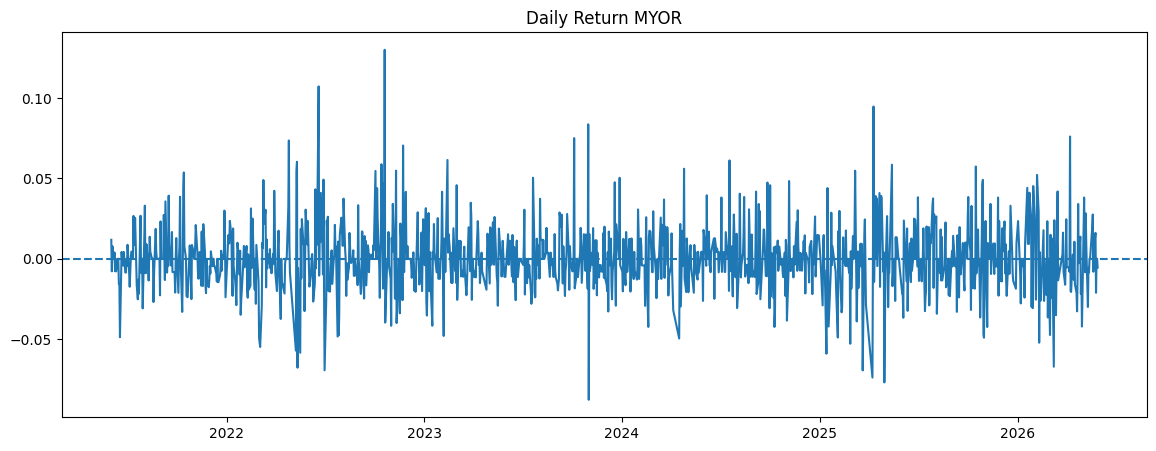

In [52]:
# Menghitung return harian MYOR
myor_clean["Daily_Return"] = (
    myor_clean["Close"].pct_change()
)

# Mengatur ukuran grafik
plt.figure(figsize=(14,5))

# Membuat grafik return harian
plt.plot(
    myor_clean["Date"],
    myor_clean["Daily_Return"]
)

# Memberikan judul
plt.title("Daily Return MYOR")

# Menampilkan garis horizontal pada 0
plt.axhline(0, linestyle="--")

# Menampilkan grafik
plt.show()

Insight

- Daily return MYOR memperlihatkan pola pergerakan yang cukup beragam dengan beberapa lonjakan return yang cukup tinggi selama periode observasi. Walaupun sebagian besar return masih berada di sekitar nol, terdapat beberapa periode yang menunjukkan perubahan harga yang cukup tajam.

- Kondisi ini menunjukkan bahwa saham MYOR masih dipengaruhi oleh berbagai faktor eksternal yang dapat menyebabkan perubahan harga secara cepat dalam jangka pendek. Dibandingkan saham sektor perbankan besar, pergerakan return MYOR terlihat lebih tidak konsisten.

- Bagi investor, kondisi ini menunjukkan bahwa MYOR memiliki peluang keuntungan yang menarik, namun perlu diimbangi dengan pengelolaan risiko yang baik karena potensi fluktuasinya juga cukup tinggi.

### 4.4.6 ICBP

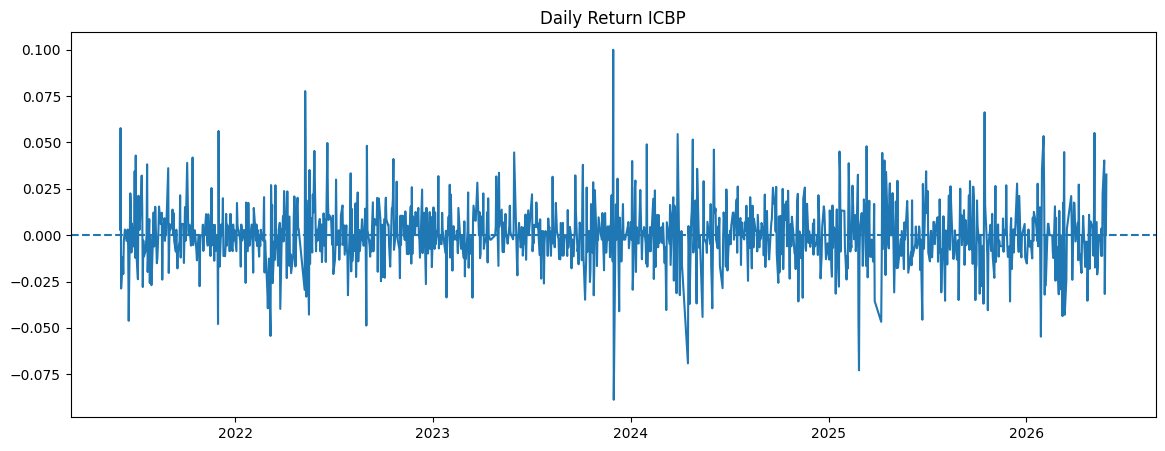

In [53]:
# Menghitung return harian ICBP
icbp_clean["Daily_Return"] = (
    icbp_clean["Close"].pct_change()
)

# Mengatur ukuran grafik
plt.figure(figsize=(14,5))

# Membuat grafik return harian
plt.plot(
    icbp_clean["Date"],
    icbp_clean["Daily_Return"]
)

# Memberikan judul
plt.title("Daily Return ICBP")

# Menampilkan garis horizontal pada 0
plt.axhline(0, linestyle="--")

# Menampilkan grafik
plt.show()

Insight

- Grafik daily return ICBP menunjukkan bahwa sebagian besar pergerakan return berada pada rentang yang relatif sempit di sekitar nilai nol. Meskipun terdapat beberapa lonjakan return yang cukup besar, frekuensinya tidak terlalu sering.

- Hal ini menunjukkan bahwa harga saham ICBP cenderung bergerak lebih stabil dibandingkan beberapa saham lainnya. Karakteristik tersebut cukup sesuai dengan sektor consumer goods yang umumnya memiliki permintaan produk yang lebih konsisten.

- Dari hasil ini dapat disimpulkan bahwa ICBP memiliki profil risiko yang relatif lebih rendah dan berpotensi menjadi salah satu aset defensif dalam portofolio investasi.

### 4.4.7 TLKM

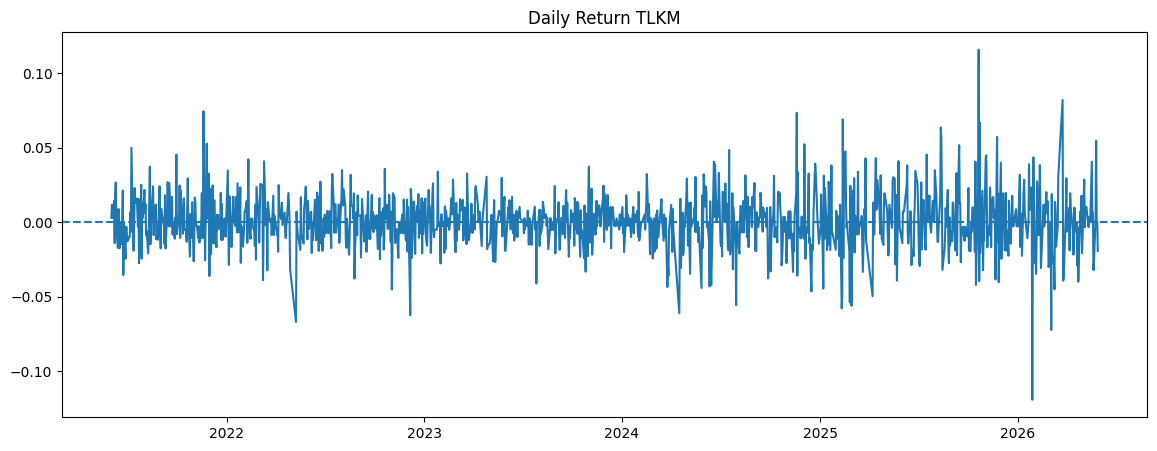

In [54]:
# Menghitung return harian TLKM
tlkm_clean["Daily_Return"] = (
    tlkm_clean["Close"].pct_change()
)

# Mengatur ukuran grafik
plt.figure(figsize=(14,5))

# Membuat grafik return harian
plt.plot(
    tlkm_clean["Date"],
    tlkm_clean["Daily_Return"]
)

# Memberikan judul
plt.title("Daily Return TLKM")

# Menampilkan garis horizontal pada 0
plt.axhline(0, linestyle="--")

# Menampilkan grafik
plt.show()

Insight

- Pergerakan daily return TLKM menunjukkan pola yang cukup stabil selama sebagian besar periode pengamatan. Mayoritas return harian berada di sekitar nilai nol dengan fluktuasi yang tidak terlalu ekstrem.

- Namun demikian, terdapat beberapa kejadian tertentu yang menghasilkan lonjakan return positif maupun negatif yang cukup besar. Kondisi ini menunjukkan bahwa meskipun secara umum stabil, saham TLKM tetap memiliki risiko pasar yang perlu diperhatikan.

- Secara keseluruhan, TLKM memiliki karakteristik yang cenderung defensif dan cocok digunakan sebagai salah satu instrumen diversifikasi dalam portofolio investasi karena berasal dari sektor telekomunikasi yang berbeda dengan sektor perbankan.

Kesimpulan Daily Return Analysis

- Berdasarkan analisis daily return, seluruh saham menunjukkan pola pergerakan yang berpusat di sekitar nilai nol, yang merupakan karakteristik umum pada data return harian saham. Namun demikian, terdapat perbedaan tingkat fluktuasi antar saham.

- Saham BBCA, ICBP, dan TLKM menunjukkan pola return yang relatif lebih stabil dengan jumlah lonjakan ekstrem yang lebih sedikit. Sebaliknya, BBRI, BMRI, BBNI, dan MYOR memperlihatkan variasi return yang lebih besar sehingga berpotensi memberikan return yang lebih tinggi, namun dengan risiko yang juga lebih besar.

- Temuan ini memberikan indikasi awal bahwa saham-saham perbankan cenderung menawarkan peluang pertumbuhan yang lebih tinggi, sedangkan saham sektor consumer goods dan telekomunikasi berpotensi memberikan stabilitas yang lebih baik dalam penyusunan portofolio investasi. Analisis ini akan diperkuat pada tahap berikutnya melalui pengukuran volatilitas, Sharpe Ratio, dan analisis risiko lainnya.

## 4.5 Volatility Analysis

Volatilitas menggambarkan risiko investasi.

### 4.5.1 BBCA

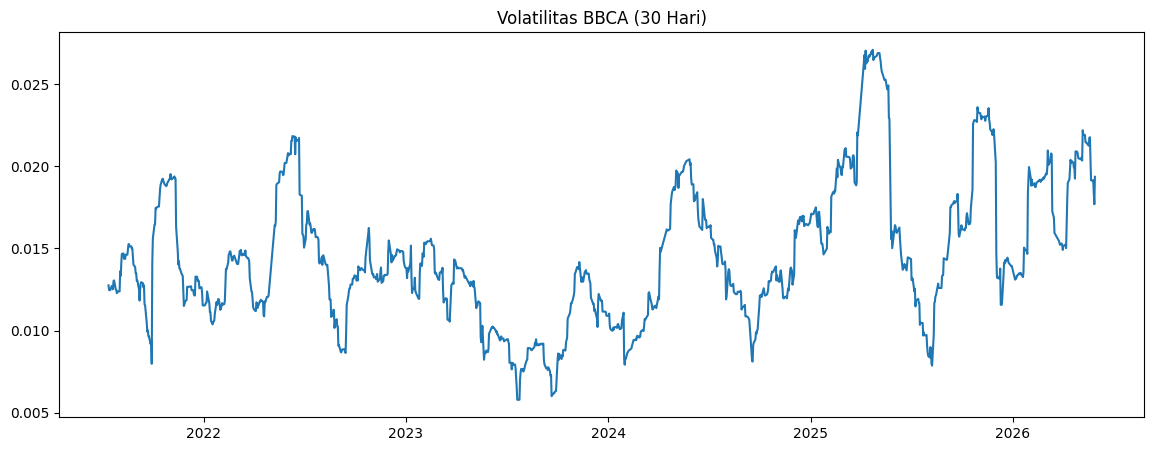

In [55]:
# Menghitung volatilitas rolling 30 hari
bbca_clean["Rolling_Volatility_30"] = (
    bbca_clean["Daily_Return"]
    .rolling(window=30)
    .std()
)

# Mengatur ukuran grafik
plt.figure(figsize=(14,5))

# Menampilkan volatilitas BBCA
plt.plot(
    bbca_clean["Date"],
    bbca_clean["Rolling_Volatility_30"]
)

# Judul grafik
plt.title("Volatilitas BBCA (30 Hari)")

# Menampilkan grafik
plt.show()

Insight

- Berdasarkan grafik volatilitas 30 hari, saham BBCA menunjukkan tingkat volatilitas yang relatif stabil selama periode pengamatan. Sebagian besar nilai volatilitas berada pada rentang 1% hingga 2%, yang menunjukkan bahwa fluktuasi harga harian masih cukup terkendali.

- Namun pada beberapa periode, khususnya sekitar tahun 2025, terjadi peningkatan volatilitas yang cukup signifikan hingga mencapai level tertinggi selama periode observasi. Kondisi ini mengindikasikan adanya ketidakpastian pasar yang lebih tinggi pada saat tersebut sehingga pergerakan harga menjadi lebih agresif.

- Secara keseluruhan, BBCA masih dapat dikategorikan sebagai saham dengan tingkat risiko yang relatif moderat karena mayoritas periode menunjukkan volatilitas yang stabil dibandingkan beberapa saham lainnya.

### 4.5.2 BBRI

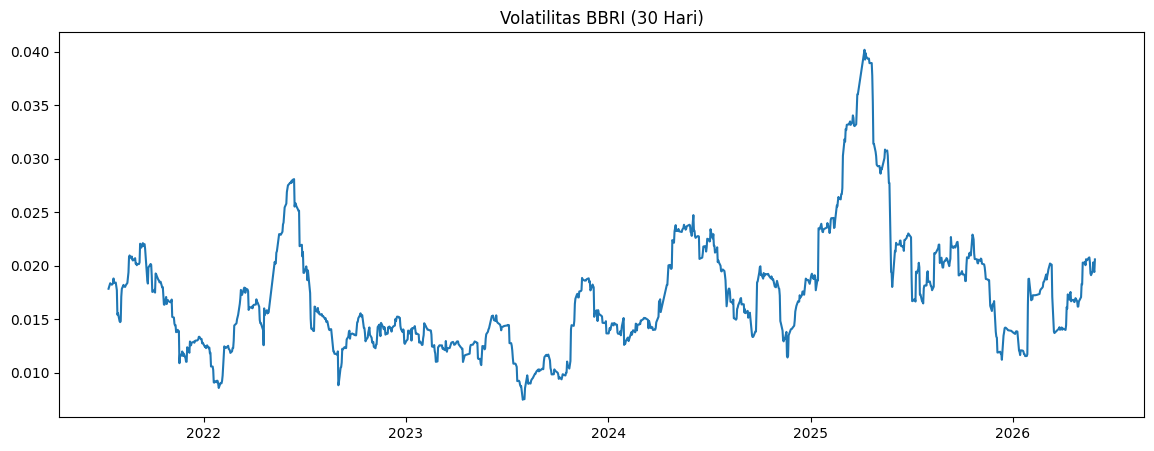

In [56]:
# Menghitung volatilitas rolling 30 hari
bbri_clean["Rolling_Volatility_30"] = (
    bbri_clean["Daily_Return"]
    .rolling(window=30)
    .std()
)

# Mengatur ukuran grafik
plt.figure(figsize=(14,5))

# Menampilkan volatilitas BBRI
plt.plot(
    bbri_clean["Date"],
    bbri_clean["Rolling_Volatility_30"]
)

# Judul grafik
plt.title("Volatilitas BBRI (30 Hari)")

# Menampilkan grafik
plt.show()

Insight

- Grafik volatilitas BBRI menunjukkan pola yang cukup dinamis. Terlihat beberapa kali terjadi peningkatan volatilitas yang cukup tinggi, terutama pada tahun 2025 ketika nilai volatilitas mendekati 4%.

- Peningkatan volatilitas tersebut menunjukkan bahwa harga saham BBRI mengalami fluktuasi yang lebih besar dibandingkan kondisi normal. Dengan kata lain, risiko investasi pada periode tersebut juga meningkat.

- Meskipun demikian, pada sebagian besar waktu volatilitas BBRI masih berada pada rentang yang relatif stabil. Kondisi ini menunjukkan bahwa BBRI memiliki potensi return yang menarik, namun investor perlu memperhatikan risiko yang lebih tinggi dibandingkan saham yang lebih defensif.

### 4.5.3 BMRI

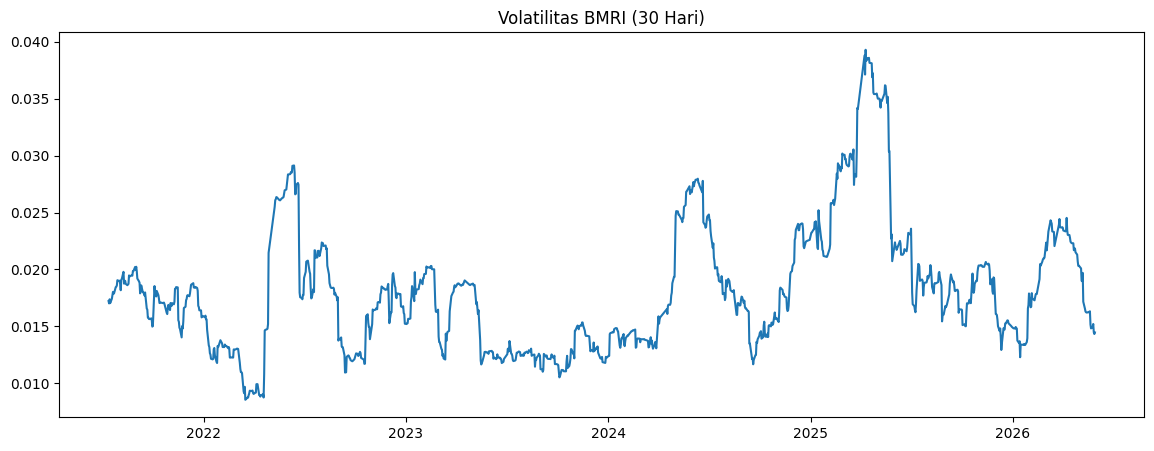

In [57]:
# Menghitung volatilitas rolling 30 hari
bmri_clean["Rolling_Volatility_30"] = (
    bmri_clean["Daily_Return"]
    .rolling(window=30)
    .std()
)

# Mengatur ukuran grafik
plt.figure(figsize=(14,5))

# Menampilkan volatilitas BMRI  
plt.plot(
    bmri_clean["Date"],
    bmri_clean["Rolling_Volatility_30"]
)

# Judul grafik
plt.title("Volatilitas BMRI (30 Hari)")

# Menampilkan grafik
plt.show()

Insight

- Volatilitas BMRI memperlihatkan pola yang mirip dengan BBRI. Selama periode pengamatan, volatilitas cenderung berada pada level menengah, namun terdapat beberapa lonjakan yang cukup tinggi terutama pada tahun 2025.

- Kenaikan volatilitas tersebut menunjukkan adanya periode ketidakpastian pasar yang menyebabkan harga saham bergerak lebih agresif. Akan tetapi, setelah periode tersebut volatilitas kembali menurun dan bergerak pada rentang yang lebih stabil.

- Hal ini menunjukkan bahwa BMRI memiliki tingkat risiko yang masih dapat diterima untuk investor dengan profil risiko moderat, terutama karena lonjakan volatilitas tidak berlangsung secara terus-menerus.

### 4.5.4 BBNI

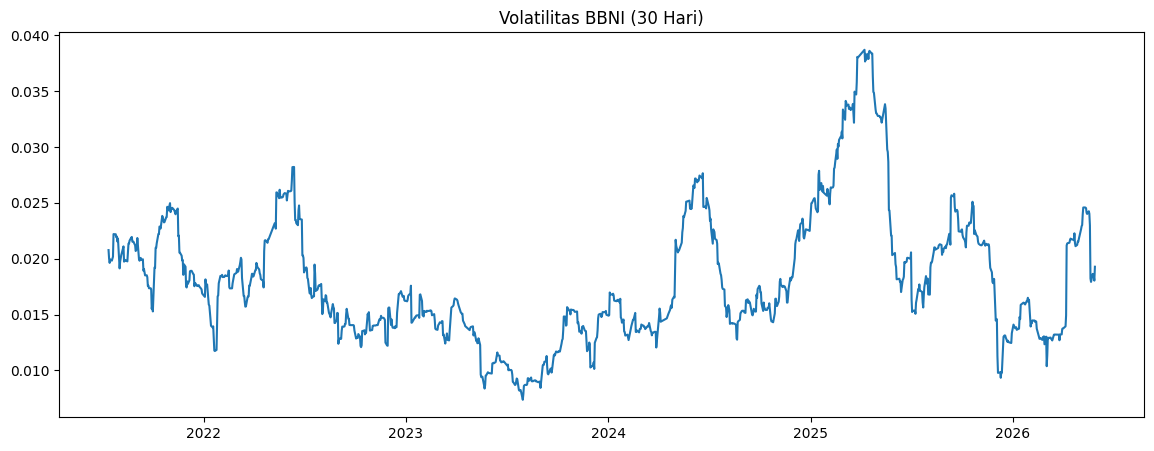

In [58]:
# Menghitung volatilitas rolling 30 hari
bbni_clean["Rolling_Volatility_30"] = (
    bbni_clean["Daily_Return"]
    .rolling(window=30)
    .std()
)

# Mengatur ukuran grafik
plt.figure(figsize=(14,5))

# Menampilkan volatilitas BBNI
plt.plot(
    bbni_clean["Date"],
    bbni_clean["Rolling_Volatility_30"]
)

# Judul grafik
plt.title("Volatilitas BBNI (30 Hari)")

# Menampilkan grafik
plt.show()

Insight

- Grafik volatilitas BBNI menunjukkan bahwa tingkat risiko saham ini cukup fluktuatif sepanjang periode observasi. Beberapa kali terlihat peningkatan volatilitas yang cukup tinggi, terutama pada periode 2024 hingga 2025.

- Kondisi tersebut menunjukkan bahwa pergerakan harga saham BBNI relatif lebih sensitif terhadap perubahan kondisi pasar. Investor berpotensi memperoleh return yang lebih tinggi, tetapi juga harus siap menghadapi risiko pergerakan harga yang lebih besar.

- Jika dibandingkan dengan BBCA, volatilitas BBNI terlihat lebih sering mengalami kenaikan yang tajam sehingga menunjukkan profil risiko yang sedikit lebih agresif.

### 4.5.5 MYOR

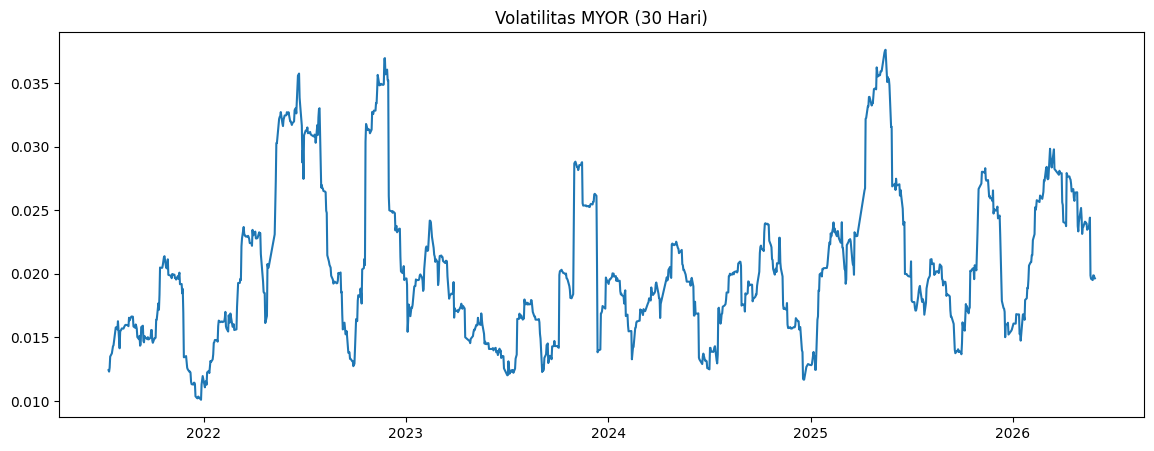

In [59]:
# Menghitung volatilitas rolling 30 hari
myor_clean["Rolling_Volatility_30"] = (
    myor_clean["Daily_Return"]
    .rolling(window=30)
    .std()
)

# Mengatur ukuran grafik
plt.figure(figsize=(14,5))

# Menampilkan volatilitas MYOR
plt.plot(
    myor_clean["Date"],
    myor_clean["Rolling_Volatility_30"]
)

# Judul grafik
plt.title("Volatilitas MYOR (30 Hari)")

# Menampilkan grafik
plt.show()

Insight

- Volatilitas MYOR menunjukkan pola yang cukup berfluktuasi sepanjang periode pengamatan. Beberapa kali terjadi lonjakan volatilitas yang cukup tinggi, bahkan mendekati level yang dicapai oleh saham perbankan.

- Hal ini menunjukkan bahwa meskipun harga MYOR berada pada rentang yang relatif lebih rendah, tingkat ketidakpastian pergerakannya tetap perlu diperhatikan. Kondisi tersebut dapat dipengaruhi oleh berbagai faktor seperti perubahan daya beli masyarakat maupun kondisi industri consumer goods.

- Secara keseluruhan, MYOR memiliki tingkat risiko yang berada pada kategori menengah karena volatilitasnya cukup aktif tetapi tidak selalu berada pada level tinggi.

### 4.5.6 ICBP

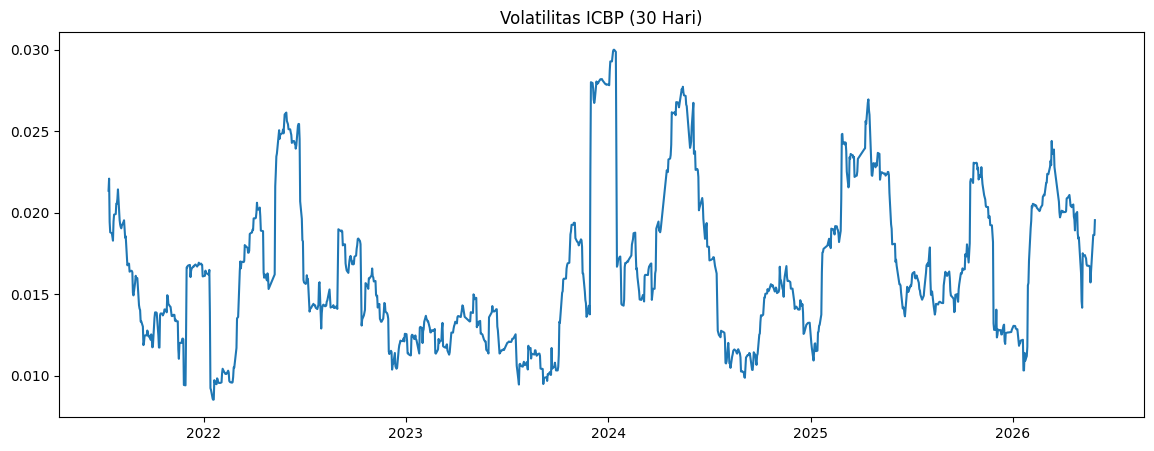

In [60]:
# Menghitung volatilitas rolling 30 hari
icbp_clean["Rolling_Volatility_30"] = (
    icbp_clean["Daily_Return"]
    .rolling(window=30)
    .std()
)

# Mengatur ukuran grafik
plt.figure(figsize=(14,5))

# Menampilkan volatilitas ICBP
plt.plot(
    icbp_clean["Date"],
    icbp_clean["Rolling_Volatility_30"]
)

# Judul grafik
plt.title("Volatilitas ICBP (30 Hari)")

# Menampilkan grafik
plt.show()

Insight

- Dibandingkan saham lainnya, ICBP menunjukkan volatilitas yang relatif lebih stabil. Sebagian besar nilai volatilitas berada pada rentang yang lebih rendah dan jarang mengalami lonjakan yang terlalu ekstrem.

- Karakteristik ini menunjukkan bahwa harga saham ICBP cenderung bergerak lebih konsisten dan tidak terlalu dipengaruhi oleh perubahan pasar jangka pendek. Kondisi tersebut sesuai dengan karakteristik sektor consumer goods yang umumnya memiliki permintaan yang relatif stabil.

- Dari sudut pandang investasi, ICBP dapat dipertimbangkan sebagai salah satu aset dengan risiko yang lebih rendah dibandingkan beberapa saham sektor perbankan.

### 4.5.7 TLKM

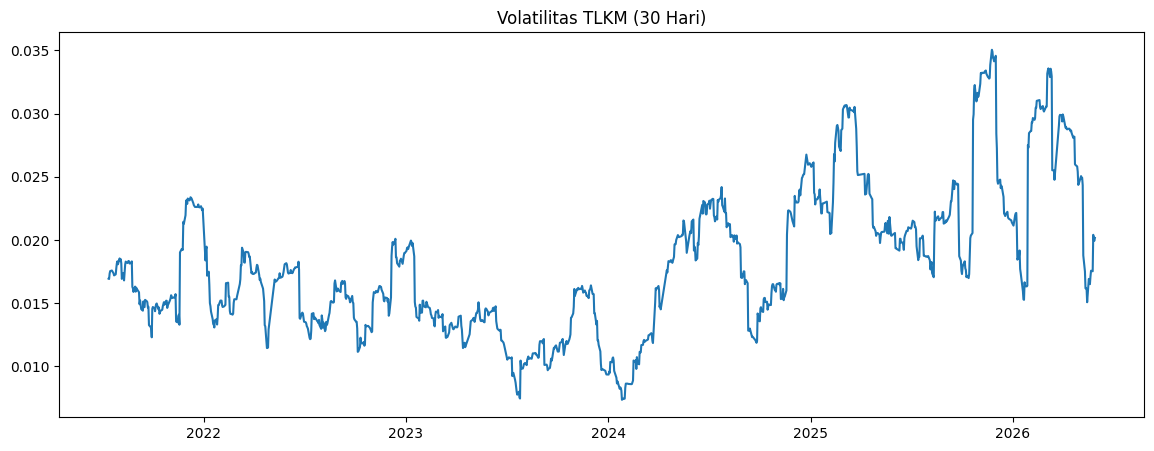

In [61]:
# Menghitung volatilitas rolling 30 hari
tlkm_clean["Rolling_Volatility_30"] = (
    tlkm_clean["Daily_Return"]
    .rolling(window=30)
    .std()
)

# Mengatur ukuran grafik
plt.figure(figsize=(14,5))

# Menampilkan volatilitas TLKM
plt.plot(
    tlkm_clean["Date"],
    tlkm_clean["Rolling_Volatility_30"]
)

# Judul grafik
plt.title("Volatilitas TLKM (30 Hari)")

# Menampilkan grafik
plt.show()

Insight

- Grafik volatilitas TLKM menunjukkan bahwa tingkat risiko saham ini relatif rendah pada awal periode pengamatan, namun mulai meningkat pada tahun 2024 hingga 2026.

- Meskipun terjadi beberapa lonjakan volatilitas, nilainya masih berada dalam rentang yang cukup terkendali. Tidak terlihat adanya periode volatilitas ekstrem yang berlangsung lama.

- Hal ini menunjukkan bahwa TLKM memiliki karakteristik yang cukup defensif dengan tingkat risiko yang relatif stabil. Oleh karena itu, saham TLKM dapat menjadi salah satu pilihan untuk membantu menjaga keseimbangan risiko dalam portofolio investasi.

Kesimpulan Volatility Analysis

- Berdasarkan hasil analisis volatilitas 30 hari, terlihat bahwa setiap saham memiliki tingkat risiko yang berbeda-beda. Saham perbankan seperti BBRI, BMRI, dan BBNI cenderung memiliki volatilitas yang lebih tinggi sehingga menawarkan peluang return yang lebih besar, namun disertai risiko yang juga lebih tinggi.

- Di sisi lain, BBCA menunjukkan volatilitas yang relatif lebih stabil dibandingkan saham perbankan lainnya. Sementara itu, ICBP dan TLKM termasuk saham dengan tingkat volatilitas yang lebih rendah sehingga dapat berperan sebagai aset defensif dalam portofolio.

- Secara umum, periode tahun 2025 menjadi fase dengan volatilitas tertinggi pada sebagian besar saham. Hal ini menunjukkan bahwa kondisi pasar pada periode tersebut memiliki tingkat ketidakpastian yang lebih besar dibandingkan tahun-tahun sebelumnya. Temuan ini akan menjadi dasar penting dalam proses pengukuran risiko, perhitungan Sharpe Ratio, serta penyusunan rekomendasi portofolio investasi pada tahap selanjutnya.

## 4.6 Volume Analysis

Bagian Volume Analysis digunakan untuk melihat tingkat aktivitas perdagangan suatu saham. Semakin tinggi volume transaksi, semakin tinggi pula likuiditas saham tersebut. Saham yang likuid umumnya lebih mudah diperjualbelikan dan memiliki spread harga yang lebih kecil.

### 4.6.1 BBCA

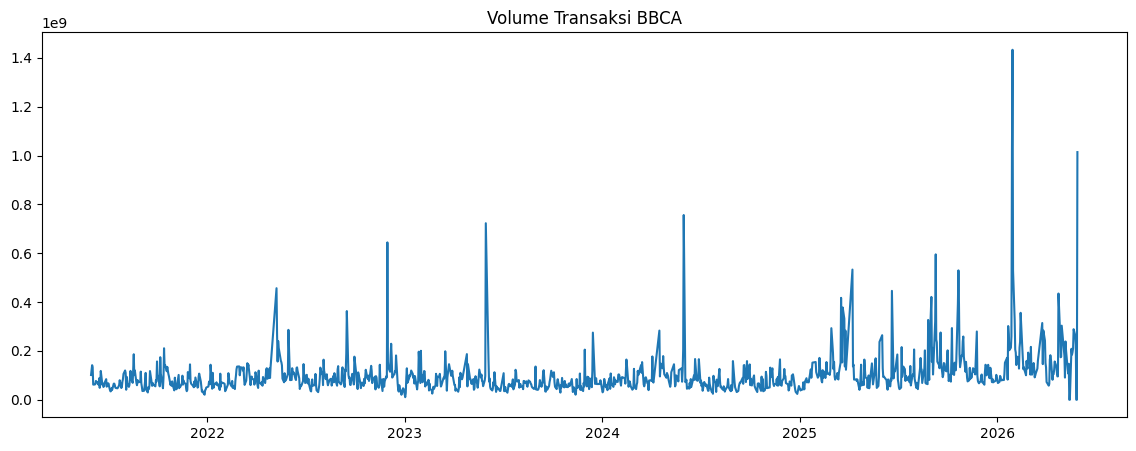

In [62]:
# Membuat grafik volume transaksi BBCA
plt.figure(figsize=(14,5))

# Menampilkan volume
plt.plot(
    bbca_clean["Date"],
    bbca_clean["Volume"]
)

# Judul grafik
plt.title("Volume Transaksi BBCA")

# Menampilkan grafik
plt.show()

Insight

- Berdasarkan grafik volume transaksi BBCA, terlihat bahwa aktivitas perdagangan saham ini cukup tinggi dan cenderung meningkat pada beberapa periode tertentu. Terdapat beberapa lonjakan volume yang sangat besar, terutama pada tahun 2025 hingga 2026, yang menunjukkan meningkatnya minat investor terhadap saham BBCA.

- Secara umum, volume transaksi BBCA relatif stabil dan konsisten sepanjang periode pengamatan. Hal ini menunjukkan bahwa BBCA merupakan salah satu saham dengan tingkat likuiditas yang sangat baik di pasar.

- Likuiditas yang tinggi menjadi salah satu keunggulan BBCA karena investor dapat melakukan transaksi dalam jumlah besar tanpa terlalu memengaruhi harga pasar.

### 4.6.2 BBRI

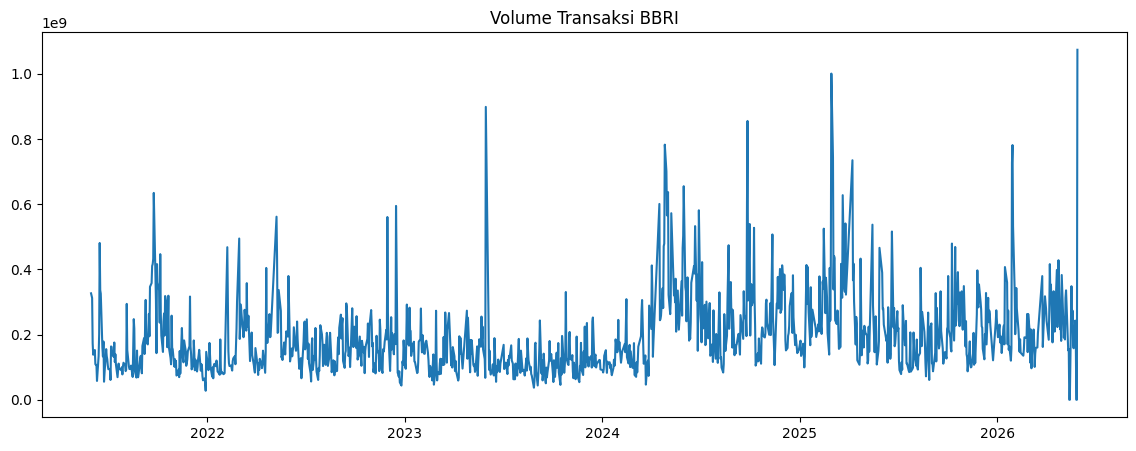

In [63]:
# Membuat grafik volume transaksi BBRI
plt.figure(figsize=(14,5))

# Menampilkan volume
plt.plot(
    bbri_clean["Date"],
    bbri_clean["Volume"]
)

# Judul grafik
plt.title("Volume Transaksi BBRI")

# Menampilkan grafik
plt.show()

Insight

- Grafik volume transaksi BBRI menunjukkan aktivitas perdagangan yang sangat aktif sepanjang periode observasi. Terlihat beberapa lonjakan volume yang cukup signifikan terutama pada periode 2024 hingga 2026.

- Volume transaksi yang tinggi menunjukkan bahwa saham BBRI memiliki tingkat likuiditas yang sangat baik dan menjadi salah satu saham yang banyak diminati oleh investor. Selain itu, peningkatan volume pada periode tertentu dapat mengindikasikan adanya respon pasar terhadap informasi atau sentimen yang memengaruhi perusahaan maupun sektor perbankan secara keseluruhan.

- Dari hasil ini dapat disimpulkan bahwa BBRI merupakan salah satu saham dengan aktivitas perdagangan yang sangat tinggi sehingga cocok digunakan sebagai aset utama dalam portofolio investasi.

### 4.6.3 BMRI

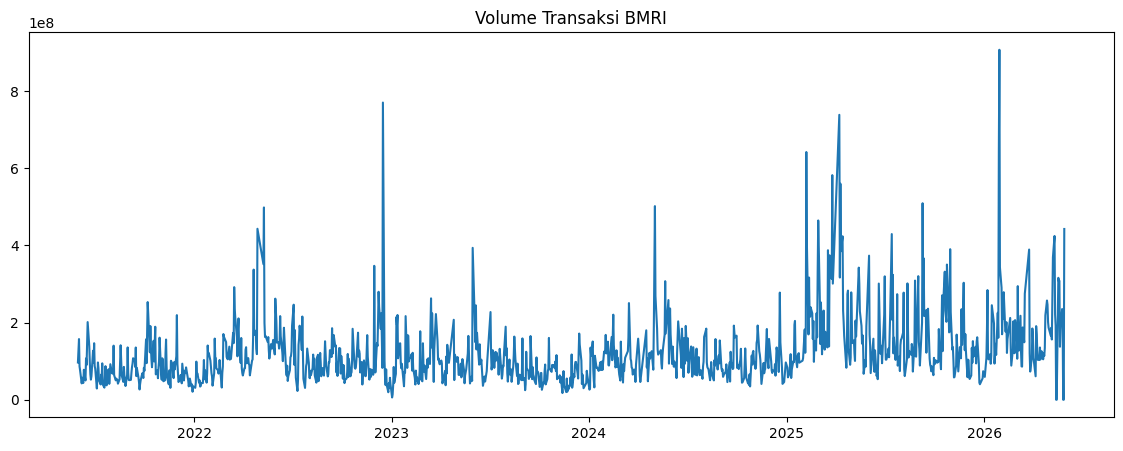

In [64]:
# Membuat grafik volume transaksi BMRI
plt.figure(figsize=(14,5))

# Menampilkan volume
plt.plot(
    bmri_clean["Date"],
    bmri_clean["Volume"]
)

# Judul grafik
plt.title("Volume Transaksi BMRI")

# Menampilkan grafik
plt.show()

Insight

- Volume transaksi BMRI menunjukkan pola yang relatif stabil dengan beberapa lonjakan yang cukup besar pada waktu tertentu. Meskipun volumenya tidak sebesar BBCA maupun BBRI, aktivitas perdagangan saham BMRI tetap tergolong tinggi dan konsisten.

- Terlihat adanya peningkatan volume pada periode 2025 yang menunjukkan meningkatnya perhatian investor terhadap saham ini. Lonjakan volume biasanya diikuti dengan peningkatan volatilitas harga karena semakin banyak transaksi yang terjadi di pasar.

- Secara keseluruhan, BMRI memiliki tingkat likuiditas yang baik sehingga memudahkan investor untuk melakukan transaksi jual maupun beli.

### 4.6.4 BBNI

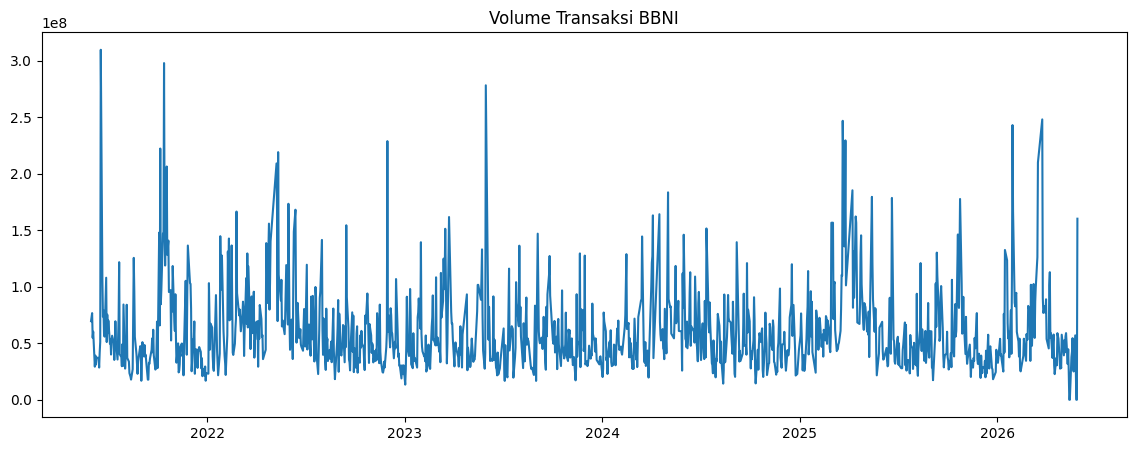

In [65]:
# Membuat grafik volume transaksi BBNI
plt.figure(figsize=(14,5))

# Menampilkan volume
plt.plot(
    bbni_clean["Date"],
    bbni_clean["Volume"]
)

# Judul grafik
plt.title("Volume Transaksi BBNI")

# Menampilkan grafik
plt.show()

Insight

- Grafik volume transaksi BBNI memperlihatkan aktivitas perdagangan yang cukup aktif sepanjang periode pengamatan. Beberapa kali terjadi lonjakan volume yang cukup tinggi yang menunjukkan adanya peningkatan minat pasar terhadap saham ini.

- Dibandingkan dengan BBCA dan BBRI, volume transaksi BBNI memang lebih rendah, namun masih menunjukkan tingkat likuiditas yang cukup baik. Hal ini terlihat dari konsistensi volume transaksi yang terjadi hampir setiap hari perdagangan.

- Aktivitas perdagangan yang cukup tinggi menunjukkan bahwa saham BBNI masih menjadi salah satu pilihan investor di sektor perbankan.

### 4.6.5 MYOR

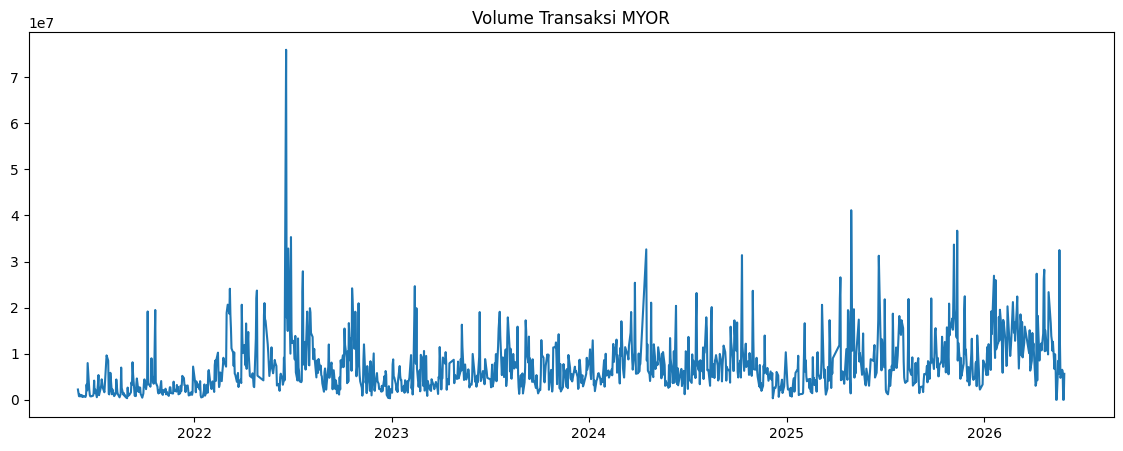

In [66]:
# Membuat grafik volume transaksi MYOR
plt.figure(figsize=(14,5))

# Menampilkan volume
plt.plot(
    myor_clean["Date"],
    myor_clean["Volume"]
)

# Judul grafik
plt.title("Volume Transaksi MYOR")

# Menampilkan grafik
plt.show()

Insight

- Volume transaksi MYOR menunjukkan pola yang cukup fluktuatif dengan beberapa lonjakan besar pada periode tertentu. Meskipun volumenya tidak sebesar saham sektor perbankan, aktivitas perdagangan MYOR masih tergolong aktif.

- Terlihat bahwa volume transaksi meningkat pada beberapa periode ketika terjadi perubahan harga yang cukup signifikan. Kondisi ini menunjukkan bahwa investor cenderung lebih aktif melakukan transaksi ketika terdapat peluang keuntungan atau perubahan sentimen pasar.

- Secara umum, MYOR memiliki tingkat likuiditas yang cukup baik untuk saham sektor consumer goods, meskipun tidak setinggi saham-saham perbankan besar.

### 4.6.6 ICBP

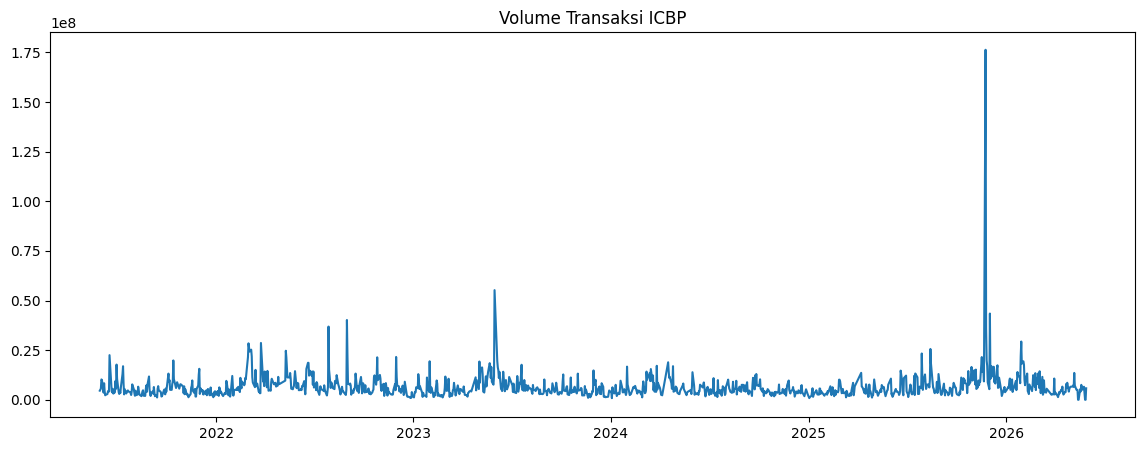

In [67]:
# Membuat grafik volume transaksi ICBP
plt.figure(figsize=(14,5))

# Menampilkan volume
plt.plot(
    icbp_clean["Date"],
    icbp_clean["Volume"]
)

# Judul grafik
plt.title("Volume Transaksi ICBP")

# Menampilkan grafik
plt.show()

Insight

- Grafik volume transaksi ICBP menunjukkan aktivitas perdagangan yang relatif stabil selama periode observasi. Terdapat beberapa lonjakan volume yang cukup besar, namun frekuensinya tidak terlalu sering dibandingkan saham lainnya.

- Hal ini menunjukkan bahwa ICBP cenderung memiliki basis investor yang lebih stabil dan tidak terlalu dipengaruhi oleh aktivitas perdagangan jangka pendek. Kondisi tersebut sejalan dengan karakteristik saham sektor consumer goods yang umumnya lebih defensif.

- Meskipun volume transaksi tidak selalu tinggi, ICBP tetap menunjukkan tingkat likuiditas yang cukup baik untuk mendukung aktivitas investasi jangka panjang.

### 4.6.7 TLKM

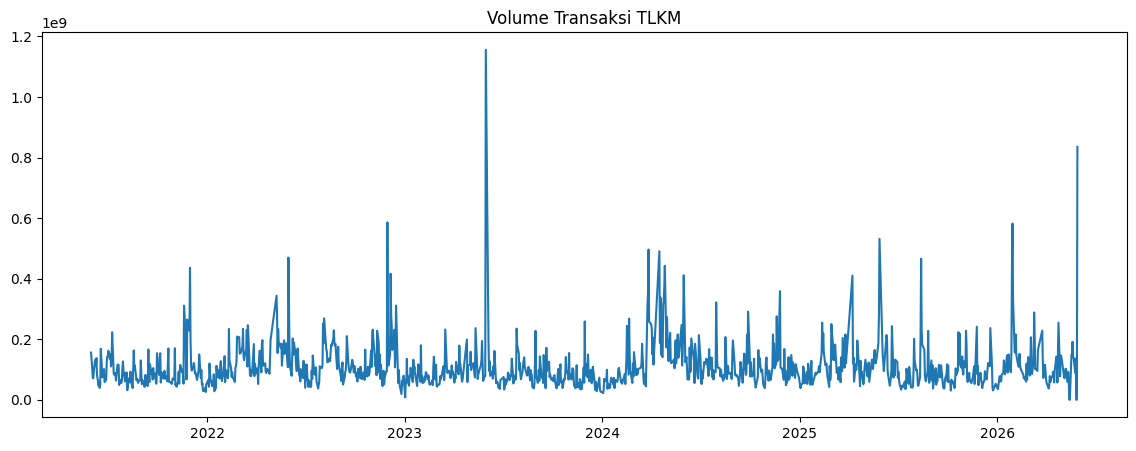

In [68]:
# Membuat grafik volume transaksi TLKM
plt.figure(figsize=(14,5))

# Menampilkan volume
plt.plot(
    tlkm_clean["Date"],
    tlkm_clean["Volume"]
)

# Judul grafik
plt.title("Volume Transaksi TLKM")

# Menampilkan grafik
plt.show()

Insight

- Volume transaksi TLKM menunjukkan aktivitas perdagangan yang cukup tinggi dan konsisten sepanjang periode pengamatan. Beberapa lonjakan volume yang sangat besar terlihat pada tahun 2023 dan 2026 yang mengindikasikan adanya peningkatan perhatian investor terhadap saham ini.

- Sebagai salah satu perusahaan telekomunikasi terbesar di Indonesia, TLKM memiliki basis investor yang luas sehingga aktivitas perdagangannya relatif aktif. Tingginya volume transaksi juga menunjukkan bahwa saham ini memiliki likuiditas yang baik.

- Kondisi tersebut menjadikan TLKM sebagai salah satu saham yang cukup menarik untuk digunakan sebagai instrumen diversifikasi dalam portofolio investasi.

Kesimpulan Volume Analysis

- Berdasarkan analisis volume transaksi, saham sektor perbankan seperti BBCA, BBRI, BMRI, dan BBNI menunjukkan aktivitas perdagangan yang sangat tinggi dibandingkan saham sektor lainnya. Hal ini menunjukkan bahwa saham-saham tersebut memiliki tingkat likuiditas yang baik dan menjadi pilihan utama banyak investor di pasar modal Indonesia.

- Sementara itu, saham ICBP, MYOR, dan TLKM juga menunjukkan aktivitas perdagangan yang cukup stabil meskipun volumenya relatif lebih rendah. Keberadaan saham-saham dari sektor yang berbeda ini dapat memberikan manfaat diversifikasi dalam penyusunan portofolio investasi.

- Secara keseluruhan, seluruh saham yang dianalisis memiliki tingkat likuiditas yang memadai untuk digunakan dalam proses portfolio management dan investment recommendation system. Tingginya likuiditas ini juga menjadi keuntungan karena memudahkan investor untuk masuk maupun keluar dari pasar dengan lebih fleksibel.

## 4.7 Menggabungkan Seluruh Dataset

In [69]:
# Menggabungkan seluruh dataset saham
all_stock = pd.concat(
    [
        bbca_clean,
        bbri_clean,
        bmri_clean,
        bbni_clean,
        icbp_clean,
        myor_clean,
        tlkm_clean
    ],
    ignore_index=True
)

# Menampilkan ukuran dataframe gabungan
print(all_stock.shape)

(8421, 9)


In [70]:
# Membuat tabel pivot berdasarkan harga penutupan
close_price = all_stock.pivot_table(
    index="Date",
    columns="Ticker",
    values="Close"
)

# Menampilkan data
close_price.head()

Ticker,BBCA,BBNI,BBRI,BMRI,ICBP,MYOR,TLKM
Date,,,,,,,
2021-05-31,"5,462.36","2,048.97","2,754.87","2,120.38","7,346.91","2,302.84","2,648.54"
2021-06-02,"5,539.47","2,105.88","2,754.87","2,155.72","7,369.31","2,330.04","2,656.24"
2021-06-03,"5,655.15","2,181.77","2,819.54","2,208.73","7,794.89","2,311.91","2,687.04"
2021-06-04,"5,638.01","2,134.34","2,806.61","2,164.56","7,570.90","2,330.04","2,694.74"
2021-06-07,"5,595.17","2,096.40","2,748.41","2,164.56","7,481.30","2,330.04","2,733.23"


# 5. Feature Engineering

## 5.1 Membuat Fungsi Feature Engineering

In [71]:
# Membuat fungsi feature engineering
def create_features(df):

    # Membuat salinan dataframe agar data asli tidak berubah
    df = df.copy()

    # Lag features
    # Harga penutupan 1 hari sebelumnya
    df["lag_1"] = df["Close"].shift(1)

    # Harga penutupan 3 hari sebelumnya
    df["lag_3"] = df["Close"].shift(3)

    # Harga penutupan 7 hari sebelumnya
    df["lag_7"] = df["Close"].shift(7)

    # Harga penutupan 14 hari sebelumnya
    df["lag_14"] = df["Close"].shift(14)

    # Harga penutupan 30 hari sebelumnya
    df["lag_30"] = df["Close"].shift(30)
    
    df["lag_60"] = df["Close"].shift(60)

    df["lag_90"] = df["Close"].shift(90)

    df["lag_180"] = df["Close"].shift(180)

    # Moving average features
    # Rata-rata harga 7 hari
    df["ma_7"] = (
        df["Close"]
        .rolling(window=7)
        .mean()
    )

    # Rata-rata harga 14 hari
    df["ma_14"] = (
        df["Close"]
        .rolling(window=14)
        .mean()
    )

    # Rata-rata harga 30 hari
    df["ma_30"] = (
        df["Close"]
        .rolling(window=30)
        .mean()
    )

    # Return features
    # Return harian
    df["daily_return"] = (
        df["Close"]
        .pct_change()
    )

    # Return mingguan
    df["weekly_return"] = (
        df["Close"]
        .pct_change(periods=5)
    )

    # Volatility features
    # Standar deviasi rolling 7 hari
    df["rolling_std_7"] = (
        df["daily_return"]
        .rolling(window=7)
        .std()
    )

    # Standar deviasi rolling 30 hari
    df["rolling_std_30"] = (
        df["daily_return"]
        .rolling(window=30)
        .std()
    )

    # Date features
    # Hari dalam bulan
    df["day"] = df["Date"].dt.day

    # Bulan
    df["month"] = df["Date"].dt.month

    # Kuartal
    df["quarter"] = df["Date"].dt.quarter

    # Tahun
    df["year"] = df["Date"].dt.year

    # Hari dalam minggu
    df["day_of_week"] = df["Date"].dt.dayofweek
    
    # Target
    # Harga penutupan hari berikutnya
    df["target"] = df["Close"].shift(-1)

    return df

Insight 

1. Lag Features

    Fitur lag digunakan untuk memberikan informasi harga historis kepada model. Dalam data time series, harga saham pada hari ini sering kali dipengaruhi oleh harga pada beberapa hari sebelumnya.

2. Moving Average

    Moving average digunakan untuk menangkap arah tren harga dalam jangka pendek, menengah, dan panjang sehingga model dapat mengenali kecenderungan pergerakan pasar.

3. Return Features

    Return harian dan mingguan digunakan untuk merepresentasikan momentum pasar. Nilai return yang positif menunjukkan kecenderungan kenaikan harga, sedangkan nilai negatif menunjukkan penurunan harga.

4. Volatility Features

    Rolling standard deviation digunakan sebagai representasi risiko atau tingkat ketidakpastian harga. Semakin tinggi nilainya, semakin besar fluktuasi harga saham.

5. Date Features

    Fitur tanggal membantu model mengenali pola musiman yang mungkin terjadi pada hari, bulan, atau kuartal tertentu.

6. Target Variable

    Target dibuat menggunakan harga penutupan pada hari berikutnya (Close.shift(-1)) sehingga model dapat belajar memprediksi harga saham satu hari ke depan berdasarkan informasi historis yang tersedia.

## 5.2 Menerapkan Feature Engineering

In [72]:
# Feature engineering BBCA
bbca_fe = create_features(bbca_clean)

# Feature engineering BBRI
bbri_fe = create_features(bbri_clean)

# Feature engineering BMRI
bmri_fe = create_features(bmri_clean)

# Feature engineering BBNI
bbni_fe = create_features(bbni_clean)

# Feature engineering ICBP
icbp_fe = create_features(icbp_clean)

# Feature engineering MYOR
myor_fe = create_features(myor_clean)

# Feature engineering TLKM
tlkm_fe = create_features(tlkm_clean)

## 5.3 Mengecek Hasil Feature Engineering

In [73]:
# Menampilkan 10 data pertama
bbca_fe.head(10)

,Date,Close,High,Low,Open,Volume,Ticker,Daily_Return,Rolling_Volatility_30,lag_1,...,daily_return,weekly_return,rolling_std_7,rolling_std_30,day,month,quarter,year,day_of_week,target
0,2021-05-31,"5,462.36","5,475.21","5,419.51","5,449.50",101442000,BBCA,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,31,5,2,2021,0,"5,539.47"
1,2021-06-02,"5,539.47","5,582.31","5,500.91","5,569.46",141732500,BBCA,0.01,NaN,"5,462.36",...,0.01,NaN,NaN,NaN,2,6,2,2021,2,"5,655.15"
2,2021-06-03,"5,655.15","5,655.15","5,509.48","5,565.18",133810500,BBCA,0.02,NaN,"5,539.47",...,0.02,NaN,NaN,NaN,3,6,2,2021,3,"5,638.01"
3,2021-06-04,"5,638.01","5,672.28","5,569.46","5,672.28",62108500,BBCA,-0.00,NaN,"5,655.15",...,-0.00,NaN,NaN,NaN,4,6,2,2021,4,"5,595.17"
4,2021-06-07,"5,595.17","5,629.44","5,509.48","5,620.87",62576000,BBCA,-0.01,NaN,"5,638.01",...,-0.01,NaN,NaN,NaN,7,6,2,2021,0,"5,509.48"
5,2021-06-08,"5,509.48","5,633.72","5,509.48","5,633.72",64348000,BBCA,-0.02,NaN,"5,595.17",...,-0.02,0.01,NaN,NaN,8,6,2,2021,1,"5,595.17"
6,2021-06-09,"5,595.17","5,599.45","5,449.50","5,449.50",77198000,BBCA,0.02,NaN,"5,509.48",...,0.02,0.01,NaN,NaN,9,6,2,2021,2,"5,672.28"
7,2021-06-10,"5,672.28","5,672.28","5,560.89","5,616.59",73262500,BBCA,0.01,NaN,"5,595.17",...,0.01,0.00,0.01,NaN,10,6,2,2021,3,"5,543.76"
8,2021-06-11,"5,543.76","5,638.01","5,535.19","5,629.44",72780500,BBCA,-0.02,NaN,"5,672.28",...,-0.02,-0.02,0.02,NaN,11,6,2,2021,4,"5,492.35"
9,2021-06-14,"5,492.35","5,586.60","5,483.78","5,586.60",61478500,BBCA,-0.01,NaN,"5,543.76",...,-0.01,-0.02,0.01,NaN,14,6,2,2021,0,"5,543.76"


### 5.3.1 Melihat Kolom Baru

In [74]:
# Menampilkan seluruh kolom
bbca_fe.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker',
       'Daily_Return', 'Rolling_Volatility_30', 'lag_1', 'lag_3', 'lag_7',
       'lag_14', 'lag_30', 'lag_60', 'lag_90', 'lag_180', 'ma_7', 'ma_14',
       'ma_30', 'daily_return', 'weekly_return', 'rolling_std_7',
       'rolling_std_30', 'day', 'month', 'quarter', 'year', 'day_of_week',
       'target'],
      dtype='str')

## 5.4 Cek Missing Value Akibat Shift dan Rolling

In [75]:
# Mengecek missing value
bbca_fe.isnull().sum()

Date                       0
Close                      0
High                       0
Low                        0
Open                       0
Volume                     0
Ticker                     0
Daily_Return               1
Rolling_Volatility_30     30
lag_1                      1
lag_3                      3
lag_7                      7
lag_14                    14
lag_30                    30
lag_60                    60
lag_90                    90
lag_180                  180
ma_7                       6
ma_14                     13
ma_30                     29
daily_return               1
weekly_return              5
rolling_std_7              7
rolling_std_30            30
day                        0
month                      0
quarter                    0
year                       0
day_of_week                0
target                     1
dtype: int64

Insight:

Missing value yang muncul setelah feature engineering berasal dari proses pembuatan lag features, moving average, dan rolling volatility. Missing value tersebut merupakan konsekuensi alami dari penggunaan data historis dan bukan disebabkan oleh kualitas data yang buruk. Karena jumlahnya relatif kecil dibandingkan keseluruhan dataset, baris yang mengandung missing value dihapus agar model hanya dilatih menggunakan data yang lengkap.

In [76]:
# Menghapus missing value pada seluruh dataset
bbca_fe = bbca_fe.dropna().reset_index(drop=True)
bbri_fe = bbri_fe.dropna().reset_index(drop=True)
bmri_fe = bmri_fe.dropna().reset_index(drop=True)
bbni_fe = bbni_fe.dropna().reset_index(drop=True)
icbp_fe = icbp_fe.dropna().reset_index(drop=True)
myor_fe = myor_fe.dropna().reset_index(drop=True)
tlkm_fe = tlkm_fe.dropna().reset_index(drop=True)

In [77]:
print("BBCA :", bbca_fe.shape)
print("BBRI :", bbri_fe.shape)
print("BMRI :", bmri_fe.shape)
print("BBNI :", bbni_fe.shape)
print("ICBP :", icbp_fe.shape)
print("MYOR :", myor_fe.shape)
print("TLKM :", tlkm_fe.shape)

BBCA : (1022, 30)
BBRI : (1022, 30)
BMRI : (1022, 30)
BBNI : (1022, 30)
ICBP : (1022, 30)
MYOR : (1022, 30)
TLKM : (1022, 30)


# 6. Train Test Split

In [78]:
# Membuat daftar fitur yang akan digunakan untuk training model

feature_columns = [

    # Lag Features
    "lag_1",
    "lag_3",
    "lag_7",
    "lag_14",
    "lag_30",
    "lag_60",
    "lag_90",
    "lag_180",

    # Moving Average Features
    "ma_7",
    "ma_14",
    "ma_30",

    # Return Features
    "daily_return",
    "weekly_return",

    # Volatility Features
    "rolling_std_7",
    "rolling_std_30",

    # Date Features
    "day",
    "month",
    "quarter",
    "year",
    "day_of_week"
]

In [79]:
# Menghitung jumlah fitur
n_features = len(feature_columns)

# Menampilkan hasil
print(f"Jumlah fitur: {n_features}")

Jumlah fitur: 20


In [80]:
# Membuat fungsi train test split khusus time series

def create_train_test_split(df):

    # Membuat data fitur
    X = df[feature_columns]

    # Membuat data target
    y = df["target"]

    # Menentukan ukuran data training (80%)
    train_size = int(len(df) * 0.8)

    # Membuat data training fitur
    X_train = X.iloc[:train_size]

    # Membuat data testing fitur
    X_test = X.iloc[train_size:]

    # Membuat data training target
    y_train = y.iloc[:train_size]

    # Membuat data testing target
    y_test = y.iloc[train_size:]

    # Mengembalikan hasil split
    return X_train, X_test, y_train, y_test

### 6.1 BBCA

In [81]:
# Train test split BBCA

bbca_X_train, bbca_X_test, bbca_y_train, bbca_y_test = (
    create_train_test_split(bbca_fe)
)

### 6.2 BBRI

In [82]:
# Train test split BBRI

bbri_X_train, bbri_X_test, bbri_y_train, bbri_y_test = (
    create_train_test_split(bbri_fe)
)

### 6.3 BMRI

In [83]:
# Train test split BMRI

bmri_X_train, bmri_X_test, bmri_y_train, bmri_y_test = (
    create_train_test_split(bmri_fe)
)

### 6.4 BBNI

In [84]:
# Train test split BBNI

bbni_X_train, bbni_X_test, bbni_y_train, bbni_y_test = (
    create_train_test_split(bbni_fe)
)

### 6.5 ICBP

In [85]:
# Train test split ICBP

icbp_X_train, icbp_X_test, icbp_y_train, icbp_y_test = (
    create_train_test_split(icbp_fe)
)

### 6.6 MYOR

In [86]:
# Train test split MYOR

myor_X_train, myor_X_test, myor_y_train, myor_y_test = (
    create_train_test_split(myor_fe)
)

### 6.7 TLKM

In [87]:
# Train test split TLKM

tlkm_X_train, tlkm_X_test, tlkm_y_train, tlkm_y_test = (
    create_train_test_split(tlkm_fe)
)

## 6.8 Validasi Hasil Split

In [88]:
# Membuat ringkasan ukuran train test seluruh dataset

split_summary = pd.DataFrame({

    "Train Rows": [
        len(bbca_X_train),
        len(bbri_X_train),
        len(bmri_X_train),
        len(bbni_X_train),
        len(icbp_X_train),
        len(myor_X_train),
        len(tlkm_X_train)
    ],

    "Test Rows": [
        len(bbca_X_test),
        len(bbri_X_test),
        len(bmri_X_test),
        len(bbni_X_test),
        len(icbp_X_test),
        len(myor_X_test),
        len(tlkm_X_test)
    ]
},

index=[
    "BBCA",
    "BBRI",
    "BMRI",
    "BBNI",
    "ICBP",
    "MYOR",
    "TLKM"
])

# Menampilkan hasil
split_summary

,Train Rows,Test Rows
BBCA,817,205
BBRI,817,205
BMRI,817,205
BBNI,817,205
ICBP,817,205
MYOR,817,205
TLKM,817,205


# 7. Data Preparation for Deep Learning

## 7.1 Sequence Creation

In [89]:
# Jumlah hari historis
window_size = 30

print(f"Window Size : {window_size}")

Window Size : 30


In [90]:
def create_sequences(X, y, window_size):
    X_seq = []
    y_seq = []

    for i in range(window_size, len(X)):
        X_seq.append(
            X.iloc[
                i-window_size:i
            ].values
        )

        y_seq.append(
            y.iloc[i]
        )

    return (
        np.array(X_seq),
        np.array(y_seq)
    )

## 7.2 Menyimpan Seluruh Dataset

In [91]:
# Menyimpan seluruh dataset train dan test

all_datasets = {

    "BBCA": (
        bbca_X_train,
        bbca_X_test,
        bbca_y_train,
        bbca_y_test
    ),

    "BBRI": (
        bbri_X_train,
        bbri_X_test,
        bbri_y_train,
        bbri_y_test
    ),

    "BMRI": (
        bmri_X_train,
        bmri_X_test,
        bmri_y_train,
        bmri_y_test
    ),

    "BBNI": (
        bbni_X_train,
        bbni_X_test,
        bbni_y_train,
        bbni_y_test
    ),

    "ICBP": (
        icbp_X_train,
        icbp_X_test,
        icbp_y_train,
        icbp_y_test
    ),

    "MYOR": (
        myor_X_train,
        myor_X_test,
        myor_y_train,
        myor_y_test
    ),

    "TLKM": (
        tlkm_X_train,
        tlkm_X_test,
        tlkm_y_train,
        tlkm_y_test
    )
}

## 7.3 Membuat Sequence Untuk Seluruh Saham

In [92]:
from sklearn.preprocessing import MinMaxScaler

feature_scalers = {}
target_scalers = {}
sequence_data = {}

for ticker, data in all_datasets.items():

    X_train, X_test, y_train, y_test = data

    # Feature Scaling
    feature_scaler = MinMaxScaler()

    X_train_scaled = pd.DataFrame(
        feature_scaler.fit_transform(X_train),
        columns=X_train.columns
    )

    X_test_scaled = pd.DataFrame(
        feature_scaler.transform(X_test),
        columns=X_test.columns
    )

    # Target Scaling
    target_scaler = MinMaxScaler()

    y_train_scaled = pd.Series(

        target_scaler.fit_transform(
            y_train.values.reshape(-1,1)
        ).flatten()

    )

    y_test_scaled = pd.Series(

        target_scaler.transform(
            y_test.values.reshape(-1,1)
        ).flatten()

    )

    feature_scalers[ticker] = feature_scaler
    target_scalers[ticker] = target_scaler

    # Sequence
    X_train_seq, y_train_seq = create_sequences(
        X_train_scaled,
        y_train_scaled,
        window_size
    )

    X_test_seq, y_test_seq = create_sequences(
        X_test_scaled,
        y_test_scaled,
        window_size
    )

    sequence_data[ticker] = {

        "X_train": X_train_seq,
        "X_test": X_test_seq,
        "y_train": y_train_seq,
        "y_test": y_test_seq

    }

## 7.4 Cek Shape

In [93]:
# Menampilkan ukuran sequence
for ticker in sequence_data.keys():
    print(
        ticker,
        sequence_data[ticker]["X_train"].shape
    )

BBCA (787, 30, 20)
BBRI (787, 30, 20)
BMRI (787, 30, 20)
BBNI (787, 30, 20)
ICBP (787, 30, 20)
MYOR (787, 30, 20)
TLKM (787, 30, 20)


In [94]:
# Mengambil jumlah fitur secara otomatis
n_features = sequence_data["BBCA"]["X_train"].shape[2]
print(
    f"Jumlah fitur: {n_features}"
)

Jumlah fitur: 20


In [95]:
print(
    "Window Size :",
    window_size
)

print(
    "Jumlah Feature :",
    n_features
)

Window Size : 30
Jumlah Feature : 20


# 8. Model Definition

Pada tahap ini dilakukan perbandingan beberapa model prediksi harga saham untuk memperoleh model dengan performa terbaik. Model yang digunakan terdiri dari tiga model machine learning berbasis gradient boosting dan dua model deep learning yang dirancang untuk menangani data sekuensial (time series).

Perbandingan dilakukan terhadap:

- XGBoost Regressor
- LightGBM Regressor
- CatBoost Regressor
- Bidirectional Long Short-Term Memory (BiLSTM)
- Gated Recurrent Unit (GRU)

Kelima model akan dievaluasi menggunakan metrik MAE, RMSE, MAPE, dan R²

## 8.1 XGBoost

XGBoost digunakan karena mampu memanfaatkan fitur-fitur hasil feature engineering seperti:

- Lag Features
- Moving Average
- Return Features
- Volatility Features
- Date Features

1. Kelebihan XGBoost
    - Mampu menangani data non-linear dengan baik.
    - Memiliki performa tinggi pada data tabular.
    - Dapat memanfaatkan feature engineering secara optimal.
    - Memiliki kemampuan regularisasi sehingga mengurangi risiko overfitting.
    - Banyak digunakan pada industri keuangan dan investasi.

2. Kekurangan XGBoost
    - Membutuhkan proses tuning parameter yang cukup banyak.
    - Waktu training lebih lama dibandingkan model sederhana.
    - Tidak dirancang khusus untuk time series sehingga memerlukan feature engineering tambahan.

### 8.1.1 Hyperparameter XGBoost

In [96]:
# Membuat model XGBoost
xgb_model = XGBRegressor(

    # Jumlah pohon keputusan
    n_estimators=300,

    # Kedalaman maksimum pohon
    max_depth=6,

    # Learning rate
    learning_rate=0.05,

    # Subsample data training
    subsample=0.8,

    # Subsample fitur
    colsample_bytree=0.8,

    # Random state untuk reproduktifitas
    random_state=42
)

Alasan Pemilihan XGBoost

XGBoost dipilih karena mampu memanfaatkan informasi historis yang direpresentasikan melalui lag features, moving average, return, dan volatility. Selain itu, XGBoost dikenal memiliki performa yang sangat baik pada berbagai kompetisi data science maupun implementasi industri.

## 8.2 CatBoost

CatBoost merupakan algoritma gradient boosting yang dikembangkan oleh Yandex. CatBoost dirancang untuk meningkatkan stabilitas proses training dan mengurangi overfitting melalui teknik ordered boosting.

Kelebihan
- Stabil terhadap overfitting.
- Performa tinggi pada data tabular.
- Tidak memerlukan preprocessing yang kompleks.

Kekurangan
- Waktu training lebih lama dibanding LightGBM.
- Ukuran model relatif besar.

### 8.2.1 Hyperparameter CatBoost

In [97]:
cat_model = CatBoostRegressor(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    loss_function="RMSE",
    verbose=0,
    random_state=42
)

Alasan Pemilihan Prophet

Prophet dipilih karena merupakan salah satu model forecasting time series yang populer dan mampu menangkap pola tren secara otomatis. Model ini digunakan sebagai pembanding terhadap XGBoost untuk mengetahui pendekatan mana yang lebih sesuai dalam memprediksi harga saham Indonesia.

## 8.3 LightGBM

Alasan Pemilihan

LightGBM dipilih karena merupakan algoritma boosting modern yang memiliki kecepatan training lebih tinggi dibandingkan XGBoost dengan performa yang tetap kompetitif. Model ini juga sangat cocok untuk data tabular yang memiliki banyak fitur hasil feature engineering.

Kelebihan
- Training lebih cepat
- Memory lebih efisien
- Cocok untuk dataset besar
- Performa sering setara dengan XGBoost

Kekurangan
- Lebih sensitif terhadap parameter
- Berpotensi overfitting jika tidak dituning

### 8.3.1 Parameter LightGBM

In [98]:
lgbm_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

## 8.4 Bidirectional LSTM

BiLSTM sering digunakan dalam forecasting karena mampu menangkap dependensi jangka panjang pada data time series.

Kelebihan
- Mampu menangkap pola jangka panjang.
- Cocok untuk forecasting time series.
- Memanfaatkan informasi sekuensial secara lebih optimal.

Kekurangan
- Membutuhkan data lebih banyak.
- Waktu training lebih lama.
- Membutuhkan resource komputasi lebih besar.

### 8.4.1 Arsitektur Model

In [99]:
# Fungsi membuat model Bidirectional LSTM
def build_bilstm():
    model = Sequential([
        Bidirectional(
            LSTM(
                units=64,
                return_sequences=False
            ),
            input_shape=(
                window_size,
                n_features
            )
        ),
        Dropout(0.2),
        Dense(
            32,
            activation="relu"
        ),
        Dense(1)
    ])
    model.compile(
        optimizer=Adam(
            learning_rate=0.001
        ),
        loss="mse",
        metrics=["mae"]
    )
    return model

## 8.5 Gated Recurrent Unit (GRU)

Kelebihan
- Training lebih cepat dibanding LSTM.
- Mampu menangani data sekuensial.
- Kompleksitas model lebih rendah.

Kekurangan
- Kadang kurang optimal dibanding LSTM pada dependensi yang sangat panjang.
- Membutuhkan proses transformasi data menjadi sequence.

### 8.5.1 Arsitektur Model

In [100]:
# Fungsi membuat model GRU
def build_gru():
    model = Sequential([
        GRU(
            units=64,
            input_shape=(
                window_size,
                n_features
            )
        ),
        Dropout(0.2),
        Dense(
            32,
            activation="relu"
        ),
        Dense(1)
    ])
    model.compile(
        optimizer=Adam(
            learning_rate=0.001
        ),
        loss="mse",
        metrics=["mae"]
    )

    return model

## 8.6 Early Stopping

In [101]:
# Callback Early Stopping
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

## 8.7 Strategi Pemilihan Model Terbaik

Untuk menentukan model terbaik, masing-masing model akan dievaluasi menggunakan data testing dengan beberapa metrik evaluasi yaitu:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Percentage Error (MAPE)
- R-Squared (R²)

Model dengan nilai error paling rendah dan nilai R² paling tinggi akan dipilih sebagai model terbaik untuk masing-masing saham.

# 9. Hyperparameter Tuning

## 9.1 XGBoost

In [102]:
# Parameter XGBoost
xgb_param = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 5, 7, 9],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

In [103]:
# Menyimpan model terbaik XGBoost
xgb_best_models = {}

# Menyimpan parameter terbaik
xgb_best_params = {}

# Loop seluruh saham
for ticker, data in all_datasets.items():
    print(f"Tuning XGBoost {ticker}")
    X_train, X_test, y_train, y_test = data
    model = XGBRegressor(
        random_state=42
    )

    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=xgb_param,
        n_iter=20,
        cv=3,
        scoring="neg_root_mean_squared_error",
        random_state=42,
        n_jobs=-1
    )

    random_search.fit(
        X_train,
        y_train
    )

    xgb_best_models[ticker] = (
        random_search.best_estimator_
    )

    xgb_best_params[ticker] = (
        random_search.best_params_
    )

    print(random_search.best_params_)
print("Tuning XGBoost selesai")

Tuning XGBoost BBCA
{'subsample': 1.0, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.9}
Tuning XGBoost BBRI
{'subsample': 0.8, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.9}
Tuning XGBoost BMRI
{'subsample': 0.8, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.9}
Tuning XGBoost BBNI
{'subsample': 1.0, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.9}
Tuning XGBoost ICBP
{'subsample': 0.9, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.7}
Tuning XGBoost MYOR
{'subsample': 1.0, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.9}
Tuning XGBoost TLKM
{'subsample': 1.0, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 0.9}
Tuning XGBoost selesai


## 9.2 LightGBM

In [104]:
# Parameter LightGBM
lgbm_param = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.03, 0.05],
    "num_leaves": [15, 31, 63],
    "subsample": [0.7, 0.8, 0.9]
}

In [105]:
# Menyimpan model terbaik LightGBM
lgbm_best_models = {}

# Menyimpan parameter terbaik
lgbm_best_params = {}

# Loop seluruh saham
for ticker, data in all_datasets.items():
    print(f"Tuning LightGBM {ticker}")
    X_train, X_test, y_train, y_test = data
    model = LGBMRegressor(
        random_state=42,
        verbose=-1
    )

    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=lgbm_param,
        n_iter=20,
        cv=3,
        scoring="neg_root_mean_squared_error",
        random_state=42,
        n_jobs=-1
    )

    random_search.fit(
        X_train,
        y_train
    )

    lgbm_best_models[ticker] = (random_search.best_estimator_)
    lgbm_best_params[ticker] = (random_search.best_params_)

    print(random_search.best_params_)

Tuning LightGBM BBCA
{'subsample': 0.9, 'num_leaves': 63, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.03}
Tuning LightGBM BBRI
{'subsample': 0.8, 'num_leaves': 31, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05}
Tuning LightGBM BMRI
{'subsample': 0.8, 'num_leaves': 31, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05}
Tuning LightGBM BBNI
{'subsample': 0.9, 'num_leaves': 63, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05}
Tuning LightGBM ICBP
{'subsample': 0.9, 'num_leaves': 63, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05}
Tuning LightGBM MYOR
{'subsample': 0.9, 'num_leaves': 63, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.03}
Tuning LightGBM TLKM
{'subsample': 0.8, 'num_leaves': 31, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05}


# 10. Model Training

Pada tahap ini dilakukan training seluruh model forecasting menggunakan data training yang telah dipersiapkan sebelumnya. Setiap model akan dilatih pada tujuh saham yang menjadi objek penelitian untuk kemudian dibandingkan performanya pada tahap evaluasi.

In [106]:
# Membuat dictionary seluruh dataset
datasets = {
    "BBCA": bbca_fe,
    "BBRI": bbri_fe,
    "BMRI": bmri_fe,
    "BBNI": bbni_fe,
    "ICBP": icbp_fe,
    "MYOR": myor_fe,
    "TLKM": tlkm_fe
}

In [107]:
# Dictionary untuk menyimpan model
xgb_models = {}
lgbm_models = {}
catboost_models = {}
bilstm_models = {}
bilstm_histories = {}
gru_models = {}

## 10.1 Training XGBoost

In [108]:
# Melakukan training XGBoost untuk seluruh saham

for ticker, df in datasets.items():
    print(f"Training XGBoost {ticker}")

    # Membuat fitur
    X = df[feature_columns]

    # Membuat target
    y = df["target"]

    # Menentukan ukuran training
    train_size = int(len(df) * 0.8)

    # Data training
    X_train = X.iloc[:train_size]

    # Target training
    y_train = y.iloc[:train_size]

    # Membuat model XGBoost
    model = XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    # training model
    model.fit(X_train, y_train)

    # Menyimpan model
    xgb_models[ticker] = model

Training XGBoost BBCA
Training XGBoost BBRI
Training XGBoost BMRI
Training XGBoost BBNI
Training XGBoost ICBP
Training XGBoost MYOR
Training XGBoost TLKM


## 10.2 Training LightGBM

In [109]:
# Melakukan training LightGBM untuk seluruh saham

for ticker, df in datasets.items():
    print(f"Training LightGBM {ticker}")

    # Membuat fitur
    X = df[feature_columns]

    # Membuat target
    y = df["target"]

    # Menentukan ukuran training
    train_size = int(len(df) * 0.8)

    # Data training
    X_train = X.iloc[:train_size]

    # Target training
    y_train = y.iloc[:train_size]

    # Membuat model LightGBM
    model = LGBMRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbose=-1
    )

    # Melatih model
    model.fit(X_train, y_train)

    # Menyimpan model
    lgbm_models[ticker] = model

Training LightGBM BBCA
Training LightGBM BBRI
Training LightGBM BMRI
Training LightGBM BBNI
Training LightGBM ICBP
Training LightGBM MYOR
Training LightGBM TLKM


## 10.3 Training CatBoost

In [110]:
# Training CatBoost untuk seluruh saham
for ticker, df in datasets.items():
    print(f"Training CatBoost {ticker}")
    X = df[feature_columns]
    y = df["target"]
    train_size = int(len(df) * 0.8)
    X_train = X.iloc[:train_size]
    y_train = y.iloc[:train_size]
    model = CatBoostRegressor(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        loss_function="RMSE",
        verbose=0,
        random_state=42
    )

    model.fit(
        X_train,
        y_train
    )

    catboost_models[ticker] = model

Training CatBoost BBCA
Training CatBoost BBRI
Training CatBoost BMRI
Training CatBoost BBNI
Training CatBoost ICBP
Training CatBoost MYOR
Training CatBoost TLKM


## 10.4 Training Bidirectional LSTM

In [111]:
# Training BiLSTM untuk seluruh saham
for ticker in sequence_data.keys():
    print(f"Training BiLSTM {ticker}")

    model = build_bilstm()
    history = model.fit(
        sequence_data[ticker]["X_train"],
        sequence_data[ticker]["y_train"],
        validation_split=0.2,
        epochs=50,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=1
    )

    bilstm_models[ticker] = model
    
    # Simpan history
    bilstm_histories[ticker] = history

Training BiLSTM BBCA


c:\Users\Aulia Putri\miniconda3\envs\ds\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - loss: 0.0298 - mae: 0.1328 - val_loss: 0.0246 - val_mae: 0.1299
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0097 - mae: 0.0770 - val_loss: 0.0175 - val_mae: 0.1098
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0071 - mae: 0.0671 - val_loss: 0.0288 - val_mae: 0.1429
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0058 - mae: 0.0597 - val_loss: 0.0221 - val_mae: 0.1238
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0048 - mae: 0.0543 - val_loss: 0.0288 - val_mae: 0.1454
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0052 - mae: 0.0560 - val_loss: 0.0301 - val_mae: 0.1480
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0043 - mae: 0.0515 - val_loss: 0.0305 - val_mae: 0.1492
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0038 - mae: 0.0475 - val_loss: 0.0218 - val_mae: 0.1233
Epoch 9/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.00

## 10.5 Training GRU

In [112]:
# Training GRU untuk seluruh saham
for ticker in sequence_data.keys():
    print(f"Training GRU {ticker}")

    model = build_gru()
    history = model.fit(
        sequence_data[ticker]["X_train"],
        sequence_data[ticker]["y_train"],
        validation_split=0.2,
        epochs=50,
        batch_size=32,
        callbacks=[early_stopping],
        verbose=1
    )

    gru_models[ticker] = model

Training GRU BBCA
Epoch 1/50


c:\Users\Aulia Putri\miniconda3\envs\ds\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 0.0455 - mae: 0.1686 - val_loss: 0.0130 - val_mae: 0.0889
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - loss: 0.0133 - mae: 0.0918 - val_loss: 0.0123 - val_mae: 0.0890
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0099 - mae: 0.0764 - val_loss: 0.0117 - val_mae: 0.0892
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0071 - mae: 0.0663 - val_loss: 0.0212 - val_mae: 0.1253
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0062 - mae: 0.0623 - val_loss: 0.0135 - val_mae: 0.0969
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0051 - mae: 0.0555 - val_loss: 0.0157 - val_mae: 0.1058
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0042 - mae: 0.0522 - val_loss: 0.0105 - val_mae: 0.0853
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0042 - mae: 0.0521 - val_loss: 0.0162 - val_mae: 0.1076
Epoch 9/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.0043 - mae: 0.

# 11. Training Tuned Model

## 11.1 XGBoost

In [113]:
# Menyimpan model XGBoost tuned
xgb_models_tuned = {}

# Loop seluruh saham
for ticker, data in all_datasets.items():
    print(f"Training Final XGBoost {ticker}")

    # Mengambil data train dan test
    X_train, X_test, y_train, y_test = data

    # Mengambil parameter terbaik hasil tuning
    best_params = xgb_best_params[ticker]

    # Membuat model dengan parameter terbaik
    model = XGBRegressor(
        n_estimators=best_params["n_estimators"],
        max_depth=best_params["max_depth"],
        learning_rate=best_params["learning_rate"],
        subsample=best_params["subsample"],
        colsample_bytree=best_params["colsample_bytree"],
        random_state=42
    )

    # Training model
    model.fit(
        X_train,
        y_train
    )

    # Simpan model
    xgb_models_tuned[ticker] = model

Training Final XGBoost BBCA
Training Final XGBoost BBRI
Training Final XGBoost BMRI
Training Final XGBoost BBNI
Training Final XGBoost ICBP
Training Final XGBoost MYOR
Training Final XGBoost TLKM


## 11.2 LightGBM

In [114]:
# Menyimpan model final LightGBM
lgbm_models_tuned = {}

# Loop seluruh saham
for ticker, data in all_datasets.items():
    print(f"Training Final LightGBM {ticker}")

    # Mengambil data train dan test
    X_train, X_test, y_train, y_test = data

    # Mengambil parameter terbaik hasil tuning
    best_params = lgbm_best_params[ticker]

    # Membuat model dengan parameter terbaik
    model = LGBMRegressor(
        n_estimators=best_params["n_estimators"],
        max_depth=best_params["max_depth"],
        learning_rate=best_params["learning_rate"],
        num_leaves=best_params["num_leaves"],
        subsample=best_params["subsample"],
        random_state=42
    )

    # Training model
    model.fit(
        X_train,
        y_train
    )

    # Simpan model
    lgbm_models_tuned[ticker] = model

Training Final LightGBM BBCA
Training Final LightGBM BBRI
Training Final LightGBM BMRI
Training Final LightGBM BBNI
Training Final LightGBM ICBP
Training Final LightGBM MYOR
Training Final LightGBM TLKM


# 12. Model Evaluation

Pada tahap ini dilakukan evaluasi performa seluruh model forecasting menggunakan data testing yang belum pernah dilihat oleh model selama proses training.

Evaluasi dilakukan menggunakan:

- Mean Absolute Error (MAE)
- Root Mean Squared Error (RMSE)
- Mean Absolute Percentage Error (MAPE)
- R-Squared (R²)

Model dengan nilai MAE, RMSE, dan MAPE yang lebih rendah serta nilai R² yang lebih tinggi akan dianggap memiliki performa yang lebih baik.

In [115]:
# Membuat fungsi Mean Absolute Percentage Error
def calculate_mape(y_true, y_pred):

    # Mengubah ke numpy array
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Menghitung MAPE
    mape = np.mean(
        np.abs((y_true - y_pred) / y_true)
    ) * 100

    return mape

In [116]:
# List untuk menyimpan seluruh hasil evaluasi
evaluation_results = []

# Menyimpan hasil evaluasi model tuning
evaluation_results_tuned = []

## 12.1 Evaluasi XGBoost

### 12.1.1 Sebelum Tuning

In [117]:
# Evaluasi XGBoost
for ticker, data in all_datasets.items():
    X_train, X_test, y_train, y_test = data

    # Prediksi
    y_pred = xgb_models[ticker].predict(
        X_test
    )

    # MAE
    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    # RMSE
    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    # MAPE
    mape = calculate_mape(
        y_test,
        y_pred
    )

    # R2
    r2 = r2_score(
        y_test,
        y_pred
    )

    evaluation_results.append([
        ticker,
        "XGBoost",
        mae,
        rmse,
        mape,
        r2
    ])

### 12.1.2 Sesudah Tuning

In [118]:
# Evaluasi XGBoost Tuned
for ticker, data in all_datasets.items():
    X_train, X_test, y_train, y_test = data

    # Prediksi
    y_pred = xgb_models_tuned[ticker].predict(
        X_test
    )

    # MAE
    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    # RMSE
    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    # MAPE
    mape = calculate_mape(
        y_test,
        y_pred
    )

    # R2
    r2 = r2_score(
        y_test,
        y_pred
    )

    evaluation_results_tuned.append([
        ticker,
        "XGBoost Tuned",
        mae,
        rmse,
        mape,
        r2
    ])

## 12.2 Evaluasi LightGBM

### 12.2.1 Sebelum Tuning

In [119]:
# Evaluasi LightGBM
for ticker, data in all_datasets.items():
    X_train, X_test, y_train, y_test = data
    y_pred = lgbm_models[ticker].predict(X_test)

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    mape = calculate_mape(
        y_test,
        y_pred
    )

    r2 = r2_score(
        y_test,
        y_pred
    )

    evaluation_results.append([
        ticker,
        "LightGBM",
        mae,
        rmse,
        mape,
        r2
    ])

### 12.2.2 Sesudah Tuning

In [120]:
# Evaluasi LightGBM Tuned
for ticker, data in all_datasets.items():
    X_train, X_test, y_train, y_test = data

    # Prediksi
    y_pred = lgbm_models_tuned[ticker].predict(X_test)

    # MAE
    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    # RMSE
    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    # MAPE
    mape = calculate_mape(
        y_test,
        y_pred
    )

    # R2
    r2 = r2_score(
        y_test,
        y_pred
    )

    evaluation_results_tuned.append([
        ticker,
        "LightGBM Tuned",
        mae,
        rmse,
        mape,
        r2
    ])

## 12.3 Evaluasi CatBoost

In [121]:
# Evaluasi CatBoost
for ticker, data in all_datasets.items():
    X_train, X_test, y_train, y_test = data
    y_pred = catboost_models[ticker].predict(
        X_test
    )

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    mape = calculate_mape(
        y_test,
        y_pred
    )

    r2 = r2_score(
        y_test,
        y_pred
    )

    evaluation_results.append([
        ticker,
        "CatBoost",
        mae,
        rmse,
        mape,
        r2
    ])

## 12.4 Evaluasi BiLSTM

In [122]:
# Evaluasi BiLSTM

for ticker in sequence_data.keys():

    X_test = sequence_data[ticker]["X_test"]
    y_test = sequence_data[ticker]["y_test"]

    # Prediksi
    y_pred = bilstm_models[ticker].predict(
        X_test,
        verbose=0
    )

    # Kembalikan prediksi ke harga asli
    y_pred = target_scalers[ticker].inverse_transform(
        y_pred
    ).flatten()

    # Kembalikan target aktual ke harga asli
    y_test_actual = target_scalers[ticker].inverse_transform(
        y_test.reshape(-1,1)
    ).flatten()

    # Hitung metric menggunakan data aktual
    mae = mean_absolute_error(
        y_test_actual,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_actual,
            y_pred
        )
    )

    mape = calculate_mape(
        y_test_actual,
        y_pred
    )

    r2 = r2_score(
        y_test_actual,
        y_pred
    )

    evaluation_results.append([
        ticker,
        "BiLSTM",
        mae,
        rmse,
        mape,
        r2
    ])

## 12.5 Evaluasi GRU

In [123]:
# Evaluasi GRU
for ticker in sequence_data.keys():

    # Mengambil data testing
    X_test = sequence_data[ticker]["X_test"]
    y_test = sequence_data[ticker]["y_test"]

    # Prediksi
    y_pred = gru_models[ticker].predict(
        X_test,
        verbose=0
    )

    # Kembalikan ke harga asli
    y_pred = target_scalers[ticker].inverse_transform(
        y_pred
    ).flatten()

    # Kembalikan target aktual ke harga asli
    y_test_actual = target_scalers[ticker].inverse_transform(
        y_test.reshape(-1,1)
    ).flatten()

    mae = mean_absolute_error(
        y_test_actual,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_actual,
            y_pred
        )
    )

    mape = calculate_mape(
        y_test_actual,
        y_pred
    )

    r2 = r2_score(
        y_test_actual,
        y_pred
    )

    # Menyimpan hasil evaluasi
    evaluation_results.append([
        ticker,
        "GRU",
        mae,
        rmse,
        mape,
        r2
    ])

## 12.6 Comparison

### 12.6.1 Comparison Models

In [124]:
# HASIL EVALUASI SEBELUM TUNING
evaluation_results = pd.DataFrame(
    evaluation_results,
    columns=[
        "Ticker",
        "Model",
        "MAE",
        "RMSE",
        "MAPE",
        "R2"
    ]
)

evaluation_results = evaluation_results.round(2)


# HASIL EVALUASI SESUDAH TUNING
evaluation_results_tuned = pd.DataFrame(
    evaluation_results_tuned,
    columns=[
        "Ticker",
        "Model",
        "MAE",
        "RMSE",
        "MAPE",
        "R2"
    ]
)

evaluation_results_tuned = evaluation_results_tuned.round(2)

# GABUNGKAN HASIL
comparison_df = pd.concat(
    [
        evaluation_results,
        evaluation_results_tuned
    ],
    ignore_index=True
)

comparison_df

,Ticker,Model,MAE,RMSE,MAPE,R2
0,BBCA,XGBoost,154.77,208.54,2.23,0.91
1,BBRI,XGBoost,59.81,76.98,1.76,0.86
2,BMRI,XGBoost,79.08,97.33,1.85,0.85
3,BBNI,XGBoost,65.49,83.19,1.67,0.75
4,ICBP,XGBoost,253.92,291.65,3.11,0.90
5,MYOR,XGBoost,43.30,55.63,2.12,0.88
6,TLKM,XGBoost,74.83,100.36,2.30,0.85
7,BBCA,LightGBM,140.05,190.38,1.99,0.93
8,BBRI,LightGBM,58.64,75.10,1.72,0.87
9,BMRI,LightGBM,73.85,89.82,1.72,0.87


Insight:

- Berdasarkan hasil evaluasi, XGBoost Tuned dan LightGBM Tuned merupakan model dengan performa terbaik dibandingkan model lainnya. Keduanya menghasilkan nilai MAE, RMSE, dan MAPE yang rendah serta nilai R² yang tinggi pada hampir seluruh saham.

- Secara keseluruhan, XGBoost Tuned menjadi model terbaik karena memberikan performa paling konsisten pada sebagian besar saham, yaitu BBCA, BBRI, BMRI, BBNI, ICBP, dan TLKM. Sementara itu, LightGBM Tuned menunjukkan hasil terbaik pada saham MYOR.

- Proses hyperparameter tuning juga terbukti meningkatkan performa model dibandingkan versi baseline, yang terlihat dari penurunan nilai error dan peningkatan nilai R² pada sebagian besar saham.

- Di sisi lain, CatBoost masih mampu memberikan hasil yang cukup baik, namun performanya masih berada di bawah XGBoost dan LightGBM. Sedangkan model deep learning BiLSTM dan GRU menunjukkan performa yang kurang optimal dengan nilai error yang tinggi dan beberapa nilai R² negatif.

### 12.6.2 Comparison RMSE

In [125]:
comparison_rmse = comparison_df.pivot_table(
    index="Ticker",
    columns="Model",
    values="RMSE"
)

comparison_rmse.round(2)

Model,BiLSTM,CatBoost,GRU,LightGBM,LightGBM Tuned,XGBoost,XGBoost Tuned
Ticker,,,,,,,
BBCA,846.05,384.57,852.50,190.38,194.11,208.54,186.92
BBNI,542.45,83.83,172.60,83.13,83.93,83.19,78.75
BBRI,215.50,82.08,340.44,75.10,69.61,76.98,69.87
BMRI,517.40,110.04,370.93,89.82,86.55,97.33,86.21
ICBP,"1,686.74",625.81,835.80,280.63,230.88,291.65,229.29
MYOR,283.91,80.96,156.19,56.13,55.41,55.63,56.28
TLKM,330.51,119.72,474.22,110.04,98.77,100.36,96.00


Insight:

- Berdasarkan nilai RMSE, model XGBoost Tuned dan LightGBM Tuned menunjukkan performa terbaik dibandingkan model lainnya. Kedua model tersebut berhasil menghasilkan nilai RMSE yang paling rendah pada hampir seluruh saham, yang menandakan tingkat kesalahan prediksi yang lebih kecil.

- XGBoost Tuned menjadi model terbaik pada saham BBCA, BBNI, BMRI, ICBP, dan TLKM, sedangkan LightGBM Tuned unggul pada saham BBRI dan MYOR. Hasil ini menunjukkan bahwa proses hyperparameter tuning berhasil meningkatkan performa kedua model dibandingkan versi baseline.

- Sebaliknya, model BiLSTM dan GRU menghasilkan nilai RMSE yang jauh lebih tinggi pada seluruh saham, sehingga kurang cocok digunakan pada dataset dan skenario forecasting yang digunakan dalam penelitian ini.

### 12.6.3 Comparison R2

In [126]:
comparison_r2 = comparison_df.pivot_table(
    index="Ticker",
    columns="Model",
    values="R2"
)

comparison_r2.round(4)

Model,BiLSTM,CatBoost,GRU,LightGBM,LightGBM Tuned,XGBoost,XGBoost Tuned
Ticker,,,,,,,
BBCA,-0.49,0.70,-0.51,0.93,0.92,0.91,0.93
BBNI,-8.99,0.75,-0.01,0.75,0.75,0.75,0.78
BBRI,-0.08,0.85,-1.70,0.87,0.89,0.86,0.89
BMRI,-2.76,0.81,-0.93,0.87,0.88,0.85,0.88
ICBP,-3.17,0.55,-0.02,0.91,0.94,0.90,0.94
MYOR,-1.86,0.75,0.13,0.88,0.89,0.88,0.88
TLKM,-0.58,0.79,-2.25,0.82,0.86,0.85,0.86


Insight:

- Berdasarkan nilai R², XGBoost Tuned dan LightGBM Tuned kembali menjadi model dengan performa terbaik. Kedua model mampu mencapai nilai R² antara 0,75 hingga 0,94, yang menunjukkan bahwa model dapat menjelaskan sebagian besar variasi pergerakan harga saham dengan baik.

- XGBoost Tuned menghasilkan nilai R² tertinggi pada saham BBCA (0,93) dan BBNI (0,78), sedangkan LightGBM Tuned unggul pada BBRI (0,89), MYOR (0,89), serta memiliki performa yang setara pada BMRI (0,88), ICBP (0,94), dan TLKM (0,86).

- Sebaliknya, model BiLSTM dan GRU menunjukkan performa yang kurang baik karena menghasilkan banyak nilai R² negatif. Hal ini menunjukkan bahwa prediksi yang dihasilkan lebih buruk dibandingkan menggunakan rata-rata data sebagai prediksi.

- Secara keseluruhan, hasil R² memperkuat temuan sebelumnya bahwa XGBoost Tuned dan LightGBM Tuned merupakan model yang paling andal, dengan XGBoost Tuned sedikit lebih unggul secara keseluruhan karena memberikan performa terbaik pada mayoritas saham yang dianalisis.

## 12.8 Best Model Setiap Saham

In [127]:
# Mengambil model terbaik dari seluruh model
best_models_df = (
    comparison_df
    .sort_values(
        by=["Ticker", "RMSE"]
    )
    .groupby("Ticker")
    .first()
    .reset_index()
)

best_models_df

,Ticker,Model,MAE,RMSE,MAPE,R2
0,BBCA,XGBoost Tuned,138.14,186.92,1.99,0.93
1,BBNI,XGBoost Tuned,59.20,78.75,1.51,0.78
2,BBRI,LightGBM Tuned,52.06,69.61,1.53,0.89
3,BMRI,XGBoost Tuned,68.61,86.21,1.60,0.88
4,ICBP,XGBoost Tuned,194.01,229.29,2.39,0.94
5,MYOR,LightGBM Tuned,42.58,55.41,2.06,0.89
6,TLKM,XGBoost Tuned,67.89,96.00,2.08,0.86


Insight:

- Berdasarkan hasil evaluasi, XGBoost Tuned dan LightGBM Tuned terpilih sebagai model terbaik untuk masing-masing saham. Pemilihan model dilakukan berdasarkan kombinasi nilai RMSE yang rendah dan R² yang tinggi, sehingga model yang dipilih memiliki tingkat kesalahan prediksi yang kecil serta mampu menjelaskan pola pergerakan harga saham dengan baik.

- Secara keseluruhan, XGBoost Tuned menjadi model terbaik pada BBCA, BBNI, BMRI, ICBP, dan TLKM, sedangkan LightGBM Tuned memberikan hasil terbaik pada BBRI dan MYOR. Nilai R² yang diperoleh berada pada rentang 0,78 hingga 0,94, menunjukkan bahwa model mampu menangkap sebagian besar variasi harga saham.

- Hasil ini menunjukkan bahwa proses hyperparameter tuning berhasil meningkatkan performa model, sehingga model-model terpilih layak digunakan pada tahap forecasting untuk memprediksi pergerakan harga saham pada periode mendatang.

# 13. Forecasting 90 Days

Pada tahap ini dilakukan forecasting harga saham selama 90 hari ke depan menggunakan model terbaik yang telah dipilih berdasarkan hasil evaluasi. Forecasting dilakukan untuk memperoleh estimasi pergerakan harga saham pada masa mendatang yang nantinya akan digunakan dalam analisis return, risiko, dan penyusunan rekomendasi portofolio investasi.

In [128]:
# Menyimpan model terbaik berdasarkan hasil tuning
best_models = {
    "BBCA": xgb_models_tuned["BBCA"],
    "BBNI": xgb_models_tuned["BBNI"],
    "BBRI": lgbm_models_tuned["BBRI"],
    "BMRI": xgb_models_tuned["BMRI"],
    "ICBP": xgb_models_tuned["ICBP"],
    "MYOR": lgbm_models_tuned["MYOR"],
    "TLKM": xgb_models_tuned["TLKM"]
}

In [129]:
# Menyimpan dataset hasil feature engineering
forecast_datasets = {
    "BBCA": bbca_fe,
    "BBRI": bbri_fe,
    "BMRI": bmri_fe,
    "BBNI": bbni_fe,
    "ICBP": icbp_fe,
    "MYOR": myor_fe,
    "TLKM": tlkm_fe
}

## 13.1. Update Feature

In [130]:
def update_features(df):

    # Lag Features
    df["lag_1"] = df["Close"].shift(1)
    df["lag_3"] = df["Close"].shift(3)
    df["lag_7"] = df["Close"].shift(7)
    df["lag_14"] = df["Close"].shift(14)
    df["lag_30"] = df["Close"].shift(30)
    df["lag_60"] = df["Close"].shift(60)
    df["lag_90"] = df["Close"].shift(90)
    df["lag_180"] = df["Close"].shift(180)

    # Moving Average
    df["ma_7"] = (
        df["Close"]
        .rolling(7)
        .mean()
    )

    df["ma_14"] = (
        df["Close"]
        .rolling(14)
        .mean()
    )

    df["ma_30"] = (
        df["Close"]
        .rolling(30)
        .mean()
    )

    df["ma_60"] = (
        df["Close"]
        .rolling(60)
        .mean()
    )

    df["ma_90"] = (
        df["Close"]
        .rolling(90)
        .mean()
    )

    # Return Features
    df["daily_return"] = (
        df["Close"]
        .pct_change()
    )

    df["weekly_return"] = (
        df["Close"]
        .pct_change(5)
    )

    # Volatility
    df["rolling_std_7"] = (
        df["daily_return"]
        .rolling(7)
        .std()
    )

    df["rolling_std_30"] = (
        df["daily_return"]
        .rolling(30)
        .std()
    )

    # Date Features
    df["day"] = df["Date"].dt.day
    df["month"] = df["Date"].dt.month
    df["quarter"] = df["Date"].dt.quarter
    df["year"] = df["Date"].dt.year
    df["day_of_week"] = df["Date"].dt.dayofweek
    return df

## 13.2. Forecast Recursive

In [131]:
def recursive_forecast(
    model,
    historical_df,
    feature_columns,
    forecast_days=90
):

    # Salin dataframe
    df = historical_df.copy()

    # Menyimpan hasil forecast
    forecast_results = []

    for day in range(forecast_days):

        # Ambil baris terakhir
        last_row = df.iloc[-1]

        # Prediksi harga berikutnya
        next_price = model.predict(
            pd.DataFrame([last_row[feature_columns]])
        )[0]

        # Membuat tanggal baru
        next_date = (
            last_row["Date"]
            + pd.Timedelta(days=1)
        )

        # Menambahkan harga prediksi
        new_row = {
            "Date": next_date,
            "Close": next_price
        }

        # Tambahkan ke dataframe
        df = pd.concat(
            [
                df,
                pd.DataFrame([new_row])
            ],

            ignore_index=True
        )

        # Hitung ulang seluruh fitur
        df = update_features(df)

        # Simpan hasil
        forecast_results.append(
            {
                "Date": next_date,
                "Forecast_Price": next_price
            }
        )

    return pd.DataFrame(forecast_results)

## 13.3. Forecast Seluruh Saham

In [132]:
# Menyimpan seluruh hasil forecast
forecast_results = {}
for ticker in best_models.keys():
    print(
        f"Forecasting {ticker}..."
    )

    forecast_df = recursive_forecast(
        model=best_models[ticker],
        historical_df=forecast_datasets[ticker],
        feature_columns=feature_columns,
        forecast_days=90
    )

    forecast_results[ticker] = forecast_df

Forecasting BBCA...
Forecasting BBNI...
Forecasting BBRI...
Forecasting BMRI...
Forecasting ICBP...
Forecasting MYOR...
Forecasting TLKM...


## 13.4. Hasil Forecast

In [133]:
forecast_results["BBCA"].head(10)

,Date,Forecast_Price
0,2026-05-29,"6,360.43"
1,2026-05-30,"6,555.31"
2,2026-05-31,"6,422.51"
3,2026-06-01,"6,340.62"
4,2026-06-02,"6,361.32"
5,2026-06-03,"6,381.52"
6,2026-06-04,"6,364.41"
7,2026-06-05,"6,278.54"
8,2026-06-06,"6,305.66"
9,2026-06-07,"6,332.90"


In [134]:
forecast_results["BBCA"].tail()

,Date,Forecast_Price
85,2026-08-22,"7,356.97"
86,2026-08-23,"7,356.97"
87,2026-08-24,"7,356.97"
88,2026-08-25,"7,356.97"
89,2026-08-26,"7,379.94"


## 13.5. Menyimpan Hasil Forecast

In [135]:
# Membuat folder
os.makedirs(
    "forecast_results",
    exist_ok=True
)

for ticker, forecast_df in forecast_results.items():
    forecast_df.to_csv(
        f"forecast_results/{ticker}_forecast.csv",
        index=False
    )

## 13.6. Visualisasi Forecast

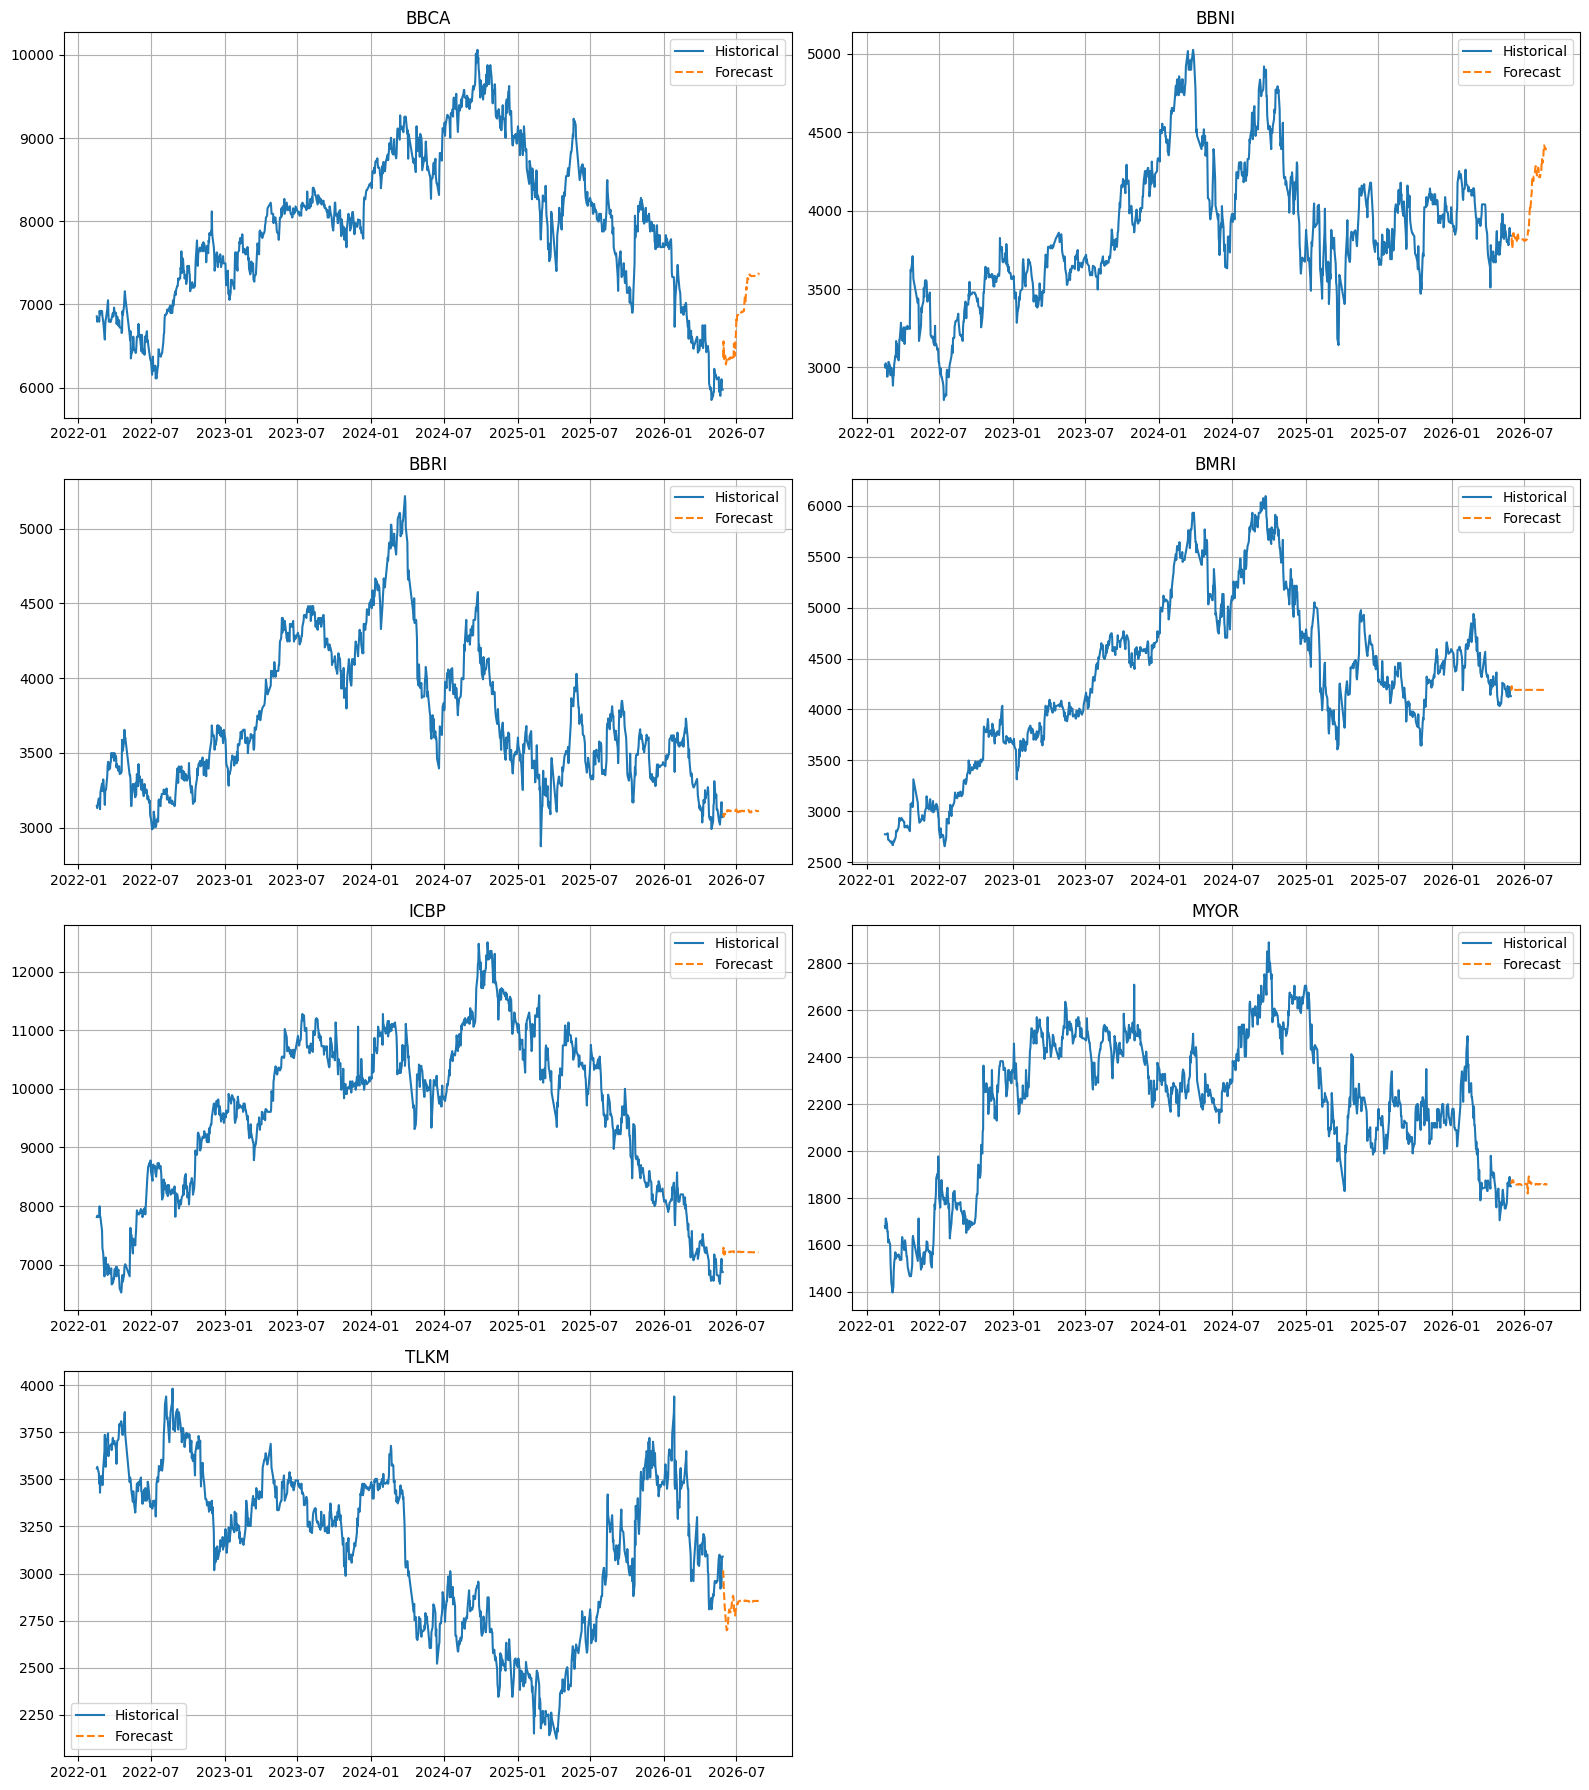

In [136]:
# Membuat canvas
fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(16,18)
)

# Mengubah menjadi array 1 dimensi
axes = axes.flatten()

# Loop seluruh saham
for i, ticker in enumerate(forecast_results.keys()):

    # Historical
    historical_df = forecast_datasets[ticker]

    # Forecast
    forecast_df = forecast_results[ticker]

    # Plot historical
    axes[i].plot(
        historical_df["Date"],
        historical_df["Close"],
        label="Historical"
    )

    # Plot forecast
    axes[i].plot(
        forecast_df["Date"],
        forecast_df["Forecast_Price"],
        linestyle="--",
        label="Forecast"
    )

    # Judul
    axes[i].set_title(ticker)

    # Grid
    axes[i].grid(True)

    # Legend
    axes[i].legend()

# Menghapus subplot kosong
fig.delaxes(axes[7])

# Merapikan layout
plt.tight_layout()

# Menampilkan grafik
plt.show()

Insight:

Berdasarkan hasil forecasting selama 3 bulan ke depan, sebagian besar saham diprediksi akan bergerak **relatif stabil** dengan mengikuti pola tren historis masing-masing saham.

* **BBCA** menunjukkan potensi kenaikan yang cukup kuat setelah berada pada fase penurunan, dengan harga diperkirakan kembali bergerak menuju kisaran Rp7.300.
* **BBNI** diproyeksikan mengalami tren naik secara bertahap hingga mendekati Rp4.400, menunjukkan sentimen yang cukup positif.
* **BBRI** cenderung bergerak sideways di sekitar level Rp3.100 tanpa perubahan yang signifikan.
* **BMRI** diperkirakan stabil pada kisaran Rp4.200, menunjukkan kondisi yang relatif konsisten.
* **ICBP** bergerak datar di sekitar Rp7.200 setelah mengalami tren penurunan pada periode sebelumnya.
* **MYOR** diprediksi stabil pada kisaran Rp1.850–Rp1.900 dengan volatilitas yang rendah.
* **TLKM** menunjukkan potensi pemulihan moderat dengan pergerakan naik menuju kisaran Rp2.850–Rp2.900.

Secara keseluruhan, hasil forecasting menunjukkan bahwa **BBCA dan BBNI memiliki potensi kenaikan yang paling menarik**, sementara saham lainnya cenderung bergerak stabil atau sideways dalam jangka pendek. Hal ini mengindikasikan bahwa kondisi pasar pada periode forecast diperkirakan tidak mengalami perubahan ekstrem dan masih mengikuti pola historis yang telah dipelajari oleh model.


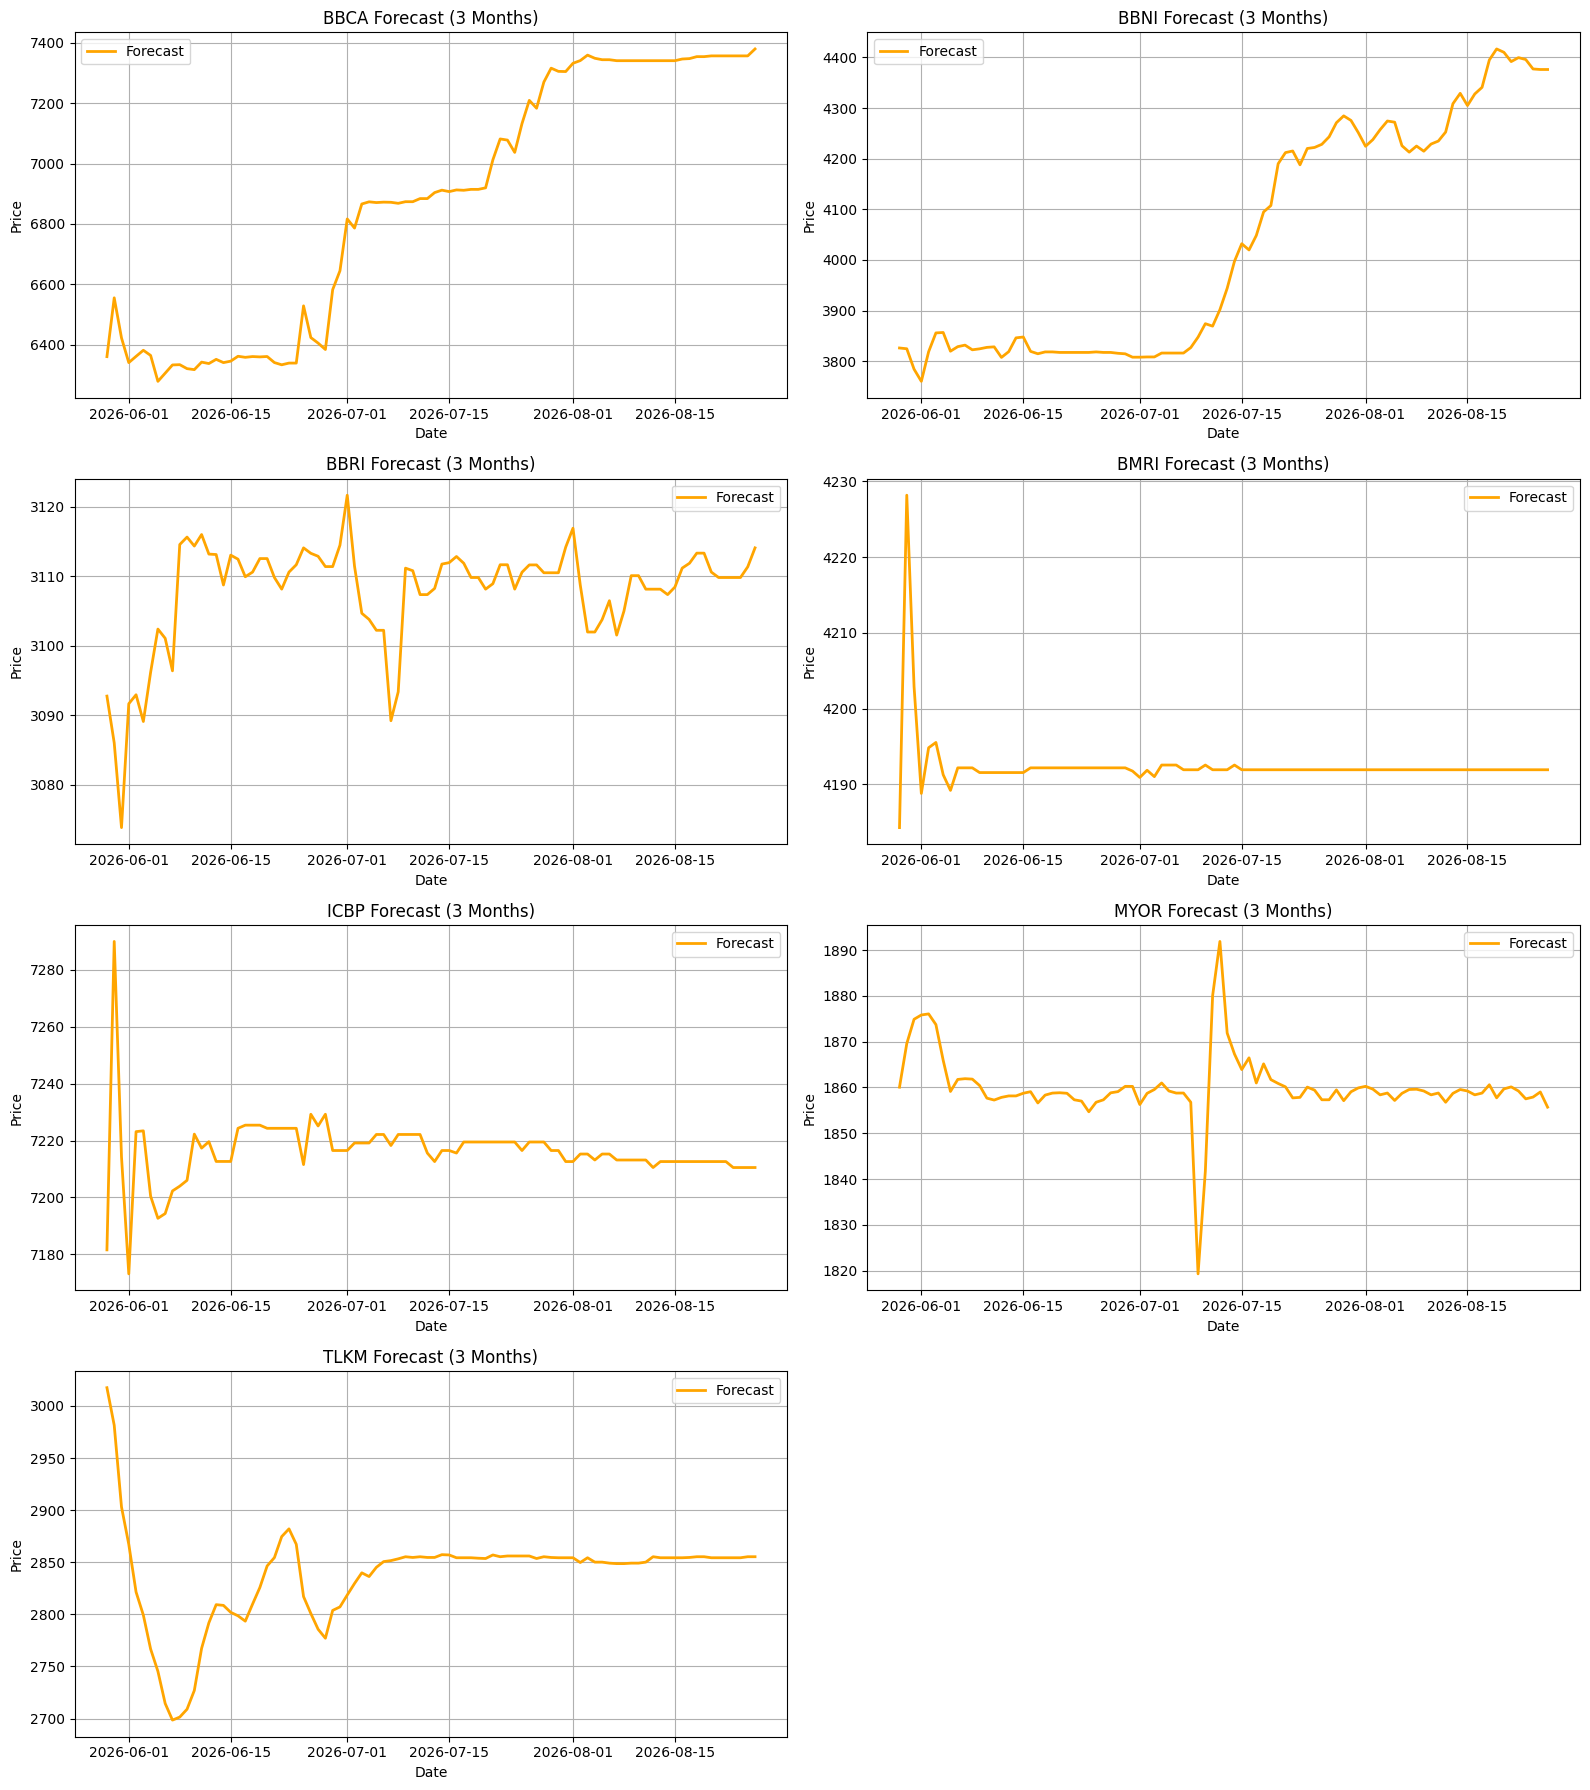

In [137]:
# Membuat canvas
fig, axes = plt.subplots(
    nrows=4,
    ncols=2,
    figsize=(16,18)
)

# Mengubah menjadi array 1 dimensi
axes = axes.flatten()

# Loop seluruh saham
for i, ticker in enumerate(forecast_results.keys()):

    # Data forecast
    forecast_df = forecast_results[ticker]

    # Plot forecast
    axes[i].plot(
        forecast_df["Date"],
        forecast_df["Forecast_Price"],
        color="orange",
        linewidth=2,
        label="Forecast"
    )

    # Judul
    axes[i].set_title(
        f"{ticker} Forecast (3 Months)"
    )

    # Label sumbu
    axes[i].set_xlabel("Date")
    axes[i].set_ylabel("Price")

    # Grid
    axes[i].grid(True)

    # Legend
    axes[i].legend()

# Menghapus subplot kosong
fig.delaxes(axes[7])

# Merapikan layout
plt.tight_layout()

# Menampilkan grafik
plt.show()

Insight:

Berdasarkan hasil forecasting selama 3 bulan ke depan, terdapat perbedaan pola pergerakan pada masing-masing saham.

* **BBCA** menunjukkan tren **naik yang cukup kuat**, dari kisaran Rp6.300 menuju Rp7.300–Rp7.400, sehingga memiliki potensi pertumbuhan paling menarik dibanding saham lainnya.
* **BBNI** juga diproyeksikan mengalami **tren kenaikan bertahap**, dari sekitar Rp3.800 menuju Rp4.400, yang mengindikasikan prospek positif dalam jangka pendek.
* **BBRI** cenderung bergerak **sideways** di sekitar level Rp3.100 dengan fluktuasi yang relatif kecil.
* **BMRI** menunjukkan pergerakan yang sangat stabil di kisaran Rp4.190 setelah penyesuaian awal, menandakan kondisi harga yang cenderung konsolidatif.
* **ICBP** diperkirakan bergerak datar pada rentang Rp7.210–Rp7.220 tanpa perubahan signifikan.
* **MYOR** juga menunjukkan pola **sideways** di sekitar Rp1.850–Rp1.860 dengan volatilitas yang rendah.
* **TLKM** sempat mengalami penurunan pada awal periode forecast, namun kemudian pulih dan stabil di kisaran Rp2.850.

Secara keseluruhan, **BBCA dan BBNI menjadi saham dengan potensi kenaikan terbesar berdasarkan hasil forecasting**, sedangkan **BBRI, BMRI, ICBP, MYOR, dan TLKM cenderung bergerak stabil atau sideways** selama periode prediksi 3 bulan ke depan.


## 13.7. Forecast Summary

In [138]:
forecast_summary = []

for ticker, df in forecast_results.items():
    # Harga minimum forecast
    min_price = df["Forecast_Price"].min()

    # Tanggal harga minimum
    min_date = df.loc[
        df["Forecast_Price"].idxmin(),
        "Date"
    ]

    # Harga maksimum forecast
    max_price = df["Forecast_Price"].max()

    # Tanggal harga maksimum
    max_date = df.loc[
        df["Forecast_Price"].idxmax(),
        "Date"
    ]

    # Harga akhir forecast
    final_price = df["Forecast_Price"].iloc[-1]

    # Tanggal akhir forecast
    final_date = df["Date"].iloc[-1]

    # Spread
    spread = max_price - min_price

    # Persentase spread
    spread_pct = (
        spread / min_price
    ) * 100

    forecast_summary.append([
        ticker,
        min_date,
        round(min_price, 2),
        max_date,
        round(max_price, 2),
        final_date,
        round(final_price, 2),
        round(spread, 2),
        round(spread_pct, 2)
    ])

# Membuat DataFrame
forecast_summary = pd.DataFrame(
    forecast_summary,
    columns=[
        "Ticker",
        "Min_Date",
        "Min_Price",
        "Max_Date",
        "Max_Price",
        "Final_Date",
        "Final_Forecast",
        "Spread",
        "Spread_%"
    ]
)

forecast_summary

,Ticker,Min_Date,Min_Price,Max_Date,Max_Price,Final_Date,Final_Forecast,Spread,Spread_%
0,BBCA,2026-06-05,"6,278.54",2026-08-26,"7,379.94",2026-08-26,"7,379.94","1,101.40",17.54
1,BBNI,2026-06-01,"3,760.14",2026-08-19,"4,416.84",2026-08-26,"4,376.24",656.70,17.46
2,BBRI,2026-05-31,"3,073.88",2026-07-01,"3,121.62",2026-08-26,"3,114.06",47.75,1.55
3,BMRI,2026-05-29,"4,184.31",2026-05-30,"4,228.16",2026-08-26,"4,191.94",43.85,1.05
4,ICBP,2026-06-01,"7,173.18",2026-05-30,"7,289.93",2026-08-26,"7,210.52",116.75,1.63
5,MYOR,2026-07-09,"1,819.29",2026-07-12,"1,891.91",2026-08-26,"1,855.70",72.62,3.99
6,TLKM,2026-06-07,"2,698.52",2026-05-29,"3,017.52",2026-08-26,"2,855.31",319.00,11.82


Insight:

- Berdasarkan hasil forecasting, **BBCA** dan **BBNI** menunjukkan potensi pertumbuhan tertinggi dengan spread masing-masing sebesar **17,54%** dan **17,46%**. Harga BBCA diproyeksikan meningkat dari titik terendah Rp6.278 menjadi Rp7.380 pada akhir periode forecast, sedangkan BBNI berpotensi naik dari Rp3.760 menjadi Rp4.376. Hal ini menunjukkan peluang return yang menarik dalam jangka pendek.

- **TLKM** berada di posisi berikutnya dengan spread **11,82%**, mengindikasikan adanya potensi pemulihan setelah mengalami penurunan pada awal periode forecast.

- Sementara itu, **MYOR** memiliki potensi kenaikan yang lebih moderat dengan spread **3,99%**, sedangkan **BBRI**, **BMRI**, dan **ICBP** menunjukkan spread yang relatif kecil, masing-masing hanya **1,55%**, **1,05%**, dan **1,63%**. Kondisi ini mengindikasikan bahwa ketiga saham tersebut diperkirakan bergerak lebih stabil atau sideways selama periode forecasting.

- Secara keseluruhan, BBCA dan BBNI menjadi saham yang paling menarik dari sisi potensi pertumbuhan harga, sedangkan BBRI, BMRI, dan ICBP lebih cocok bagi investor yang mengutamakan stabilitas pergerakan harga dengan volatilitas yang lebih rendah.


## 13.8. Expected Return

In [139]:
expected_returns = []
for ticker in forecast_results.keys():
    last_actual_price = (
        forecast_datasets[ticker]
        ["Close"]
        .iloc[-1]
    )

    final_forecast_price = (
        forecast_results[ticker]
        ["Forecast_Price"]
        .iloc[-1]
    )

    expected_return = (
        (final_forecast_price - last_actual_price)
        / last_actual_price
    ) * 100
    expected_returns.append([
        ticker,
        round(last_actual_price, 2),
        round(final_forecast_price, 2),
        round(expected_return, 2)
    ])

expected_returns = pd.DataFrame(
    expected_returns,
    columns=[
        "Ticker",
        "Current_Price",
        "Forecast_Price",
        "Expected_Return (%)"
    ]
)

expected_returns

,Ticker,Current_Price,Forecast_Price,Expected_Return (%)
0,BBCA,"5,975.00","7,379.94",23.51
1,BBNI,"3,840.00","4,376.24",13.96
2,BBRI,"3,070.00","3,114.06",1.44
3,BMRI,"4,130.00","4,191.94",1.50
4,ICBP,"6,875.00","7,210.52",4.88
5,MYOR,"1,850.00","1,855.70",0.31
6,TLKM,"3,090.00","2,855.31",-7.60


Insight:

- Berdasarkan hasil forecasting 3 bulan ke depan, **BBCA** menjadi saham dengan potensi return tertinggi, yaitu **23,51%**, dengan harga diproyeksikan naik dari Rp5.975 menjadi Rp7.380. Posisi berikutnya ditempati oleh **BBNI** dengan expected return sebesar **13,96%**, menunjukkan potensi pertumbuhan yang cukup menarik dalam jangka pendek.

- **ICBP** diperkirakan memberikan return moderat sebesar **4,88%**, sedangkan **BMRI** dan **BBRI** memiliki potensi kenaikan yang relatif kecil, masing-masing sebesar **1,50%** dan **1,44%**. Sementara itu, **MYOR** menunjukkan pergerakan yang sangat stabil dengan expected return hanya **0,31%**.

- Berbeda dengan saham lainnya, **TLKM** diproyeksikan mengalami penurunan dengan expected return **-7,60%**, yang mengindikasikan potensi risiko penurunan harga dalam periode forecasting.

- Secara keseluruhan, **BBCA dan BBNI** menjadi saham yang paling menarik berdasarkan potensi return forecast, sedangkan **TLKM** memerlukan perhatian lebih karena diperkirakan mengalami pelemahan harga dalam tiga bulan ke depan.


# 14. Save Models

In [140]:
# Menyimpan best model
for ticker, model in best_models.items():
    filename = (
        f"best_models/"
        f"{ticker}_best_model.pkl"
    )

    joblib.dump(
        model,
        filename
    )

# 15. Conclusion

- Pada proyek ini telah dilakukan analisis dan forecasting harga saham menggunakan beberapa algoritma machine learning dan deep learning, yaitu XGBoost, LightGBM, CatBoost, BiLSTM, dan GRU. Sebelum proses pemodelan, dilakukan tahap data preparation dan feature engineering dengan memanfaatkan berbagai fitur seperti lag features, moving average, return, volatility, serta fitur waktu untuk membantu model mengenali pola pergerakan harga saham.

- Berdasarkan hasil evaluasi, model berbasis **machine learning** menunjukkan performa yang lebih baik dibandingkan model **deep learning**. Setelah dilakukan hyperparameter tuning, **XGBoost Tuned** dan **LightGBM Tuned** menjadi model dengan performa terbaik, ditunjukkan oleh nilai RMSE yang rendah serta nilai R² yang tinggi pada sebagian besar saham. XGBoost Tuned terpilih sebagai model terbaik pada BBCA, BBNI, BMRI, ICBP, dan TLKM, sedangkan LightGBM Tuned menjadi model terbaik pada BBRI dan MYOR.

- Hasil forecasting selama tiga bulan menunjukkan bahwa sebagian besar saham diprediksi bergerak stabil dengan kecenderungan mengikuti pola historisnya. Dari sisi potensi return, **BBCA** dan **BBNI** menjadi saham dengan prospek pertumbuhan paling menarik, masing-masing memiliki expected return sebesar **23,51%** dan **13,96%**. Sebaliknya, **TLKM** menunjukkan expected return negatif sebesar **-7,60%**, sehingga memiliki potensi risiko penurunan harga dalam periode forecast.

- Secara keseluruhan, hasil penelitian menunjukkan bahwa pendekatan machine learning berbasis boosting, khususnya **XGBoost Tuned**, mampu memberikan performa prediksi yang baik untuk forecasting harga saham. Informasi yang dihasilkan dari model ini dapat dimanfaatkan sebagai pendukung pengambilan keputusan investasi dengan memberikan gambaran mengenai potensi pergerakan harga dan peluang return pada periode mendatang.
